<a href="https://colab.research.google.com/github/jliu0411/CMPE255collabs2/blob/main/Copy_of_final_autogluon_capabilities_tour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧭 AutoGluon: A Whirlwind Tour of Capabilities
## Every problem type AutoGluon solves, one small industry dataset each — inputs, the three-line call, and the outputs illustrated

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dlmastery/class/blob/main/colabs/06_data_eval_mlops/autogluon_capabilities_tour.ipynb)
![Python](https://img.shields.io/badge/Python-3.10%2B-blue)
![AutoGluon](https://img.shields.io/badge/AutoGluon-1.6-orange)

---

<div style="background: linear-gradient(135deg, #f7971e 0%, #ffd200 100%); padding: 30px; border-radius: 20px; color: #222; text-align: center; margin: 10px 0;">

### Welcome

This is the **tour**, not the deep dive. Its sibling, `autogluon_zero_to_hero.ipynb`, follows one dataset through the whole machine-learning lifecycle. This notebook does the opposite: **twelve capabilities, twelve small industry datasets**, and for each one the same four beats — *what problem is this, what does the input look like, the three-line call, and what comes out*. By the end you will know what AutoGluon can do, what you have to give it, and what you get back.

</div>

## 🎯 Learning Objectives

1. **Recognise every problem type AutoGluon solves out of the box and the one-line call for each.**
2. **See what the **input** must look like for each capability (a DataFrame, a long time-series table, a text column, an image path column) before running anything.**
3. **Read the **outputs** each predictor produces: leaderboards, probabilities, prediction intervals, forecast fans, embeddings.**
4. **Judge each result with the right metric family and one honest picture.**
5. **Know what each capability costs (time, data, GPU) and when a simpler tool wins.**
6. **Leave with a capability map you can use to pick the right AutoGluon module for a new business problem.**

## 📚 Table of Contents

| Part | Task | Capability · dataset | Difficulty |
|:----:|:----:|--------|:----------:|
| 0 | 1 | Setup, the three-line pattern, and a helper that shows any input | ⭐ |
| 1 | 2 | Binary classification · telecom churn | ⭐ |
| 2 | 3 | Multiclass classification · loan grades | ⭐ |
| 3 | 4 | Regression · house prices | ⭐ |
| 4 | 5 | Quantile regression · delivery-time windows | ⭐⭐ |
| 5 | 6 | Rare events · card fraud with cost-aware thresholds | ⭐⭐ |
| 6 | 7 | Time series · store demand forecasts with covariates and Chronos | ⭐⭐ |
| 7 | 8 | Text + tabular · product reviews (MultiModal) | ⭐⭐ |
| 8 | 9 | Images · defect photos (MultiModal image classification) | ⭐⭐⭐ |
| 9 | 10 | Embeddings and semantic search · support tickets (MultiModal feature extraction) | ⭐⭐⭐ |
| 10 | 11 | Tabular foundation models · TabPFN / Mitra inside AutoGluon | ⭐⭐⭐ |
| 11 | 12 | Interpretability, deployment, and the capability map · what to reach for when | 🔬 |

## 🗺️ How to read

Every Part is one capability and follows one rhythm: **❓ The problem → 📥 The input → 💻 Three lines → 📤 The output → 📊 A picture → ✅ When to use it**. The datasets are small and generated inside the notebook, so nothing downloads for the tabular Parts; the multimodal Parts download a model on Colab and fall back to a lighter method offline. Every fit is capped at a minute or two.

## ⏱️ Estimated Time

About 90 minutes end to end on a Colab CPU; the image and embedding Parts are faster with a GPU runtime.


In [1]:
!pip install --upgrade pip setuptools wheel
!pip install autogluon
# RESTART SESSION AFTER THIS AND PROCEED FROM NEXT CELL (in Runtime->run cell and beyond)

  Using cached autogluon-1.6.3-py3-none-any.whl.metadata (13 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of statsforecast to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of fasttransform to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of python-fasthtml to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is loo

# Part 0 · Setup and the Three-Line Pattern ⭐

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 What AutoGluon is, in one paragraph

AutoGluon is three predictors that share one habit. `TabularPredictor` takes a DataFrame and a label column; `TimeSeriesPredictor` takes a long table of `item_id, timestamp, target`; `MultiModalPredictor` takes a DataFrame whose columns can be numbers, categories, free text or image paths. Each one infers the problem type from the label, builds and tunes a zoo of models, stacks them into an ensemble, and hands back a leaderboard. The habit is the **three-line pattern**:

```python
predictor = SomePredictor(label="target").fit(train_df, time_limit=60)
leaderboard = predictor.leaderboard(test_df)
predictions = predictor.predict(new_df)
```

Everything in this tour is a variation of those three lines.

</div>

# Task 1 · Setup

## 1.1 Install and import


In [1]:
# !pip install -q autogluon   # AutoGluon 1.6 (tabular + timeseries + multimodal); ~3 min on Colab
import warnings; warnings.filterwarnings("ignore")
import os, sys, time, json, tempfile, shutil, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid"); sns.set_palette("husl")
RANDOM_STATE = 42; np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 160)
logging.getLogger("autogluon").setLevel(logging.ERROR)

import autogluon
from autogluon.tabular import TabularPredictor
TS_OK = MM_OK = True
try:
    from autogluon.timeseries import TimeSeriesPredictor, TimeSeriesDataFrame
except Exception:  # noqa: BLE001
    TS_OK = False
try:
    from autogluon.multimodal import MultiModalPredictor
except Exception:  # noqa: BLE001
    MM_OK = False
GPU = False
try:
    import torch; GPU = torch.cuda.is_available()
except Exception:  # noqa: BLE001
    pass
N_CPUS = max(1, min(4, os.cpu_count() or 2))     # every fit is told to use at most 4 cores: predictable on Colab and on shared machines
WORK = tempfile.mkdtemp(prefix="agtour_")        # every predictor saves under here; deleted at the end
print(f"AutoGluon {autogluon.tabular.__version__} | timeseries: {TS_OK} | multimodal: {MM_OK} | GPU: {GPU} | cpus used per fit: {N_CPUS}")
print("All libraries imported successfully!")


AutoGluon 1.6.3 | timeseries: True | multimodal: True | GPU: False | cpus used per fit: 2
All libraries imported successfully!


## 1.2 Three helpers used in every Part

`show_input` prints what a dataset *looks like* — shape, the first rows, the column types AutoGluon will infer, and the label's distribution — so every Part starts by looking at its input. `report_card` gives every model the same metric row (threshold, ranking and probabilistic metrics for classifiers; MAE, RMSE, MAPE, R² for regressors). `pretty` styles tables and `timer` makes speed a number.


In [2]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, log_loss, brier_score_loss, matthews_corrcoef,
                             mean_absolute_error, mean_squared_error, r2_score, median_absolute_error)
import time as _time
from contextlib import contextmanager
try:
    from IPython.display import display
except ImportError:  # noqa: BLE001 - plain python: print instead
    display = print

def show_input(df, label=None, n=5, name="dataset"):
    # What does this input look like? Shape, head, dtypes as AutoGluon will see them, and the label distribution.
    print(f"📥 {name}: {df.shape[0]:,} rows x {df.shape[1]} columns" + (f" | label = '{label}'" if label else ""))
    display(df.head(n))
    kinds = df.dtypes.astype(str).replace({"object": "text/category", "int64": "numeric", "float64": "numeric", "bool": "boolean", "category": "category"})
    print("column types:", dict(kinds))
    if label is not None:
        if df[label].nunique() <= 20:
            print("label distribution:", df[label].value_counts(normalize=True).round(3).to_dict())
        else:
            print(f"label range: {df[label].min():.3g} .. {df[label].max():.3g}, mean {df[label].mean():.3g}")

def report_card(y_true, y_pred=None, y_prob=None, name="model", task="classification"):
    # One tidy row of metrics. Classification needs y_pred (labels) and, ideally, y_prob (P(class 1)).
    y_true = np.asarray(y_true)
    if task == "classification":
        y_pred = np.asarray(y_pred)
        row = {"model": name, "accuracy": accuracy_score(y_true, y_pred), "balanced_acc": balanced_accuracy_score(y_true, y_pred),
               "precision": precision_score(y_true, y_pred, zero_division=0), "recall": recall_score(y_true, y_pred, zero_division=0),
               "f1": f1_score(y_true, y_pred, zero_division=0), "mcc": matthews_corrcoef(y_true, y_pred)}
        if y_prob is not None:
            y_prob = np.asarray(y_prob)
            row.update({"roc_auc": roc_auc_score(y_true, y_prob), "pr_auc": average_precision_score(y_true, y_prob),
                        "log_loss": log_loss(y_true, np.clip(y_prob, 1e-6, 1 - 1e-6)), "brier": brier_score_loss(y_true, y_prob)})
    else:
        y_pred = np.asarray(y_pred, dtype=float); err = y_true - y_pred
        row = {"model": name, "MAE": mean_absolute_error(y_true, y_pred), "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
               "MedAE": median_absolute_error(y_true, y_pred), "MAPE_%": float(np.mean(np.abs(err / np.clip(np.abs(y_true), 1e-9, None))) * 100),
               "R2": r2_score(y_true, y_pred), "bias": float(err.mean())}
    return pd.DataFrame([row]).set_index("model")

def pretty(df, fmt="{:.3f}", highlight="max", subset=None):
    # A styled DataFrame: three decimals, the best value per column highlighted.
    sty = df.style.format(fmt, na_rep="-")
    cols = subset if subset is not None else [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
    if cols and highlight == "max":
        sty = sty.highlight_max(subset=cols, color="#d4edda")
    elif cols and highlight == "min":
        sty = sty.highlight_min(subset=cols, color="#d4edda")
    return sty

@contextmanager
def timer(label="block"):
    t0 = _time.perf_counter()
    yield
    print(f"⏱️ {label}: {_time.perf_counter() - t0:.1f} s")

_demo = pd.DataFrame({"age": [34, 51], "plan": ["basic", "pro"], "churned": [0, 1]})
show_input(_demo, label="churned", name="a two-row demo")
print(report_card([0, 1, 1, 0], [0, 1, 0, 0], [0.2, 0.9, 0.4, 0.1], name="demo").round(3).to_string())


📥 a two-row demo: 2 rows x 3 columns | label = 'churned'


,age,plan,churned
0,34,basic,0
1,51,pro,1


column types: {'age': 'numeric', 'plan': 'text/category', 'churned': 'numeric'}
label distribution: {0: 0.5, 1: 0.5}
       accuracy  balanced_acc  precision  recall     f1    mcc  roc_auc  pr_auc  log_loss  brier
model                                                                                           
demo       0.75          0.75        1.0     0.5  0.667  0.577      1.0     1.0     0.338  0.105


## 1.3 Task 1 Summary

**✅ Key Takeaways**
- Three predictors (`Tabular`, `TimeSeries`, `MultiModal`), one three-line pattern: `fit` → `leaderboard` → `predict`.
- Every Part starts with `show_input` so the shape of the input is never a mystery, and ends with `report_card` so the results are comparable.
- Fits are capped with `time_limit` and `num_cpus=N_CPUS`; everything saves under `WORK`.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `TabularPredictor`, `TimeSeriesPredictor`, `MultiModalPredictor` | the three AutoGluon entry points (`TS_OK`, `MM_OK` say which imported) |
| `show_input`, `report_card`, `pretty`, `timer` | the helpers used in every Part |
| `RANDOM_STATE`, `N_CPUS`, `GPU`, `WORK` | seed, cores per fit, GPU flag, and the scratch directory for saved predictors |

**➡️ Next Up:** Part 1 — the most common business question there is: who is about to leave?


# Part 1 · Binary classification · telecom churn ⭐

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The capability

**Binary classification** answers a yes/no question about each row of a table: will this customer leave, will this payment bounce, will this part fail. It is the most common business question there is, and it is the default thing `TabularPredictor` does when the label column has two values. Part 1 runs the three lines on a telecom churn table, then looks closely at what comes back: a leaderboard, a probability per customer, and a ranked list of who to call first.

</div>

# Task 2 · Who is about to leave?

## 2.1 ❓ The problem

A telecom operator loses customers every month. The retention team can call a few hundred of them with an offer, but not all of them. They ask: **which customers are most likely to churn next month, and why?** A good answer is a ranked list with a probability next to every name, so the team can start at the top and stop when the budget runs out. A model that only says "churn" or "stay" is much less useful than one that says "82% likely".


## 2.2 📥 The input

One row per customer, one label column `churned` (1 = left last month). The table mixes numbers, categories, a boolean and a free-text column of the customer's last complaint, which is empty for customers who never complained. The generator plants real structure: month-to-month contracts, high monthly charges and many support calls push customers toward leaving, and churners are more likely to have complained about price or billing.


In [3]:
def make_churn(n=3000, seed=RANDOM_STATE):
    """One row per telecom customer with a planted churn mechanism and a short free-text complaint."""
    rng = np.random.default_rng(seed)
    tenure = rng.integers(1, 73, n)                                                   # months with the operator
    contract = rng.choice(["month-to-month", "one-year", "two-year"], n, p=[0.55, 0.25, 0.20])
    payment = rng.choice(["credit card", "bank transfer", "electronic check", "mailed check"], n, p=[0.30, 0.25, 0.30, 0.15])
    streaming = rng.random(n) < 0.45
    monthly = np.clip(20 + 55 * rng.random(n) + 15 * streaming + rng.normal(0, 5, n), 18, 120).round(2)
    support = rng.poisson(1.1, n)                                                     # support calls in the last 90 days
    total_gb = (rng.gamma(2.0, 60, n) * (1 + 0.5 * streaming)).round(1)
    logit = (-2.3 + 1.5 * (contract == "month-to-month") - 0.9 * (contract == "two-year")
             + 0.03 * (monthly - 50) + 0.45 * support - 0.02 * tenure + 0.5 * (payment == "electronic check"))
    churned = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)

    # the free-text complaint: churners complain more often, and more often about price and billing
    openers = ["", "Honestly,", "Second time:", "Still unresolved -", "As I said on the phone,"]
    hot = ["the price went up again without notice", "my bill has charges I never agreed to", "I was promised a discount that never came",
           "the service drops every evening", "I am thinking of switching to another provider"]
    mild = ["the app does not show my usage", "please update my mailing address", "the router light keeps blinking",
            "the new plan options are confusing", "I want to add a second line"]
    closers = ["", "please fix this.", "I expect a call back.", "this is getting old.", "thanks."]
    complaint = []
    for c in churned:
        if rng.random() > (0.75 if c else 0.35):
            complaint.append("")                                                      # no complaint on file
            continue
        bank = hot if rng.random() < (0.8 if c else 0.3) else mild
        complaint.append(" ".join(w for w in (rng.choice(openers), rng.choice(bank), rng.choice(closers)) if w))
    return pd.DataFrame({"tenure_months": tenure, "monthly_charge": monthly, "contract": contract, "payment_method": payment,
                         "num_support_calls": support, "streaming": streaming, "total_gb": total_gb,
                         "last_complaint": complaint, "churned": churned})

churn = make_churn()
train_c, test_c = train_test_split(churn, test_size=0.25, random_state=RANDOM_STATE, stratify=churn["churned"])
show_input(churn, label="churned", name="telecom churn")
print(f"customers with a complaint on file: {(churn.last_complaint != '').mean():.1%} | distinct complaint texts: {churn.last_complaint.nunique()}")
print(f"train {len(train_c):,} rows, test {len(test_c):,} rows (stratified on churned)")


📥 telecom churn: 3,000 rows x 9 columns | label = 'churned'


,tenure_months,monthly_charge,contract,payment_method,num_support_calls,streaming,total_gb,last_complaint,churned
0,7,36.20,one-year,credit card,1,False,94.6,"Honestly, the new plan options are confusing p...",0
1,56,20.14,two-year,bank transfer,2,False,229.4,,0
2,48,40.86,month-to-month,electronic check,2,True,532.1,,0
3,32,75.55,month-to-month,bank transfer,3,True,228.0,"Honestly, I am thinking of switching to anothe...",0
4,32,62.58,two-year,credit card,2,False,17.0,,0


column types: {'tenure_months': 'numeric', 'monthly_charge': 'numeric', 'contract': 'text/category', 'payment_method': 'text/category', 'num_support_calls': 'numeric', 'streaming': 'boolean', 'total_gb': 'numeric', 'last_complaint': 'text/category', 'churned': 'numeric'}
label distribution: {0: 0.768, 1: 0.232}
customers with a complaint on file: 45.2% | distinct complaint texts: 251
train 2,250 rows, test 750 rows (stratified on churned)


| Column | Type | Meaning | What AutoGluon will infer |
|---|---|---|---|
| `tenure_months` | int | months with the operator | numeric |
| `monthly_charge` | float | current monthly bill | numeric |
| `contract` | str | `month-to-month`, `one-year`, `two-year` | category (few distinct values) |
| `payment_method` | str | four payment types | category |
| `num_support_calls` | int | support calls in the last 90 days | numeric |
| `streaming` | bool | has a streaming add-on | boolean, cast to 0/1 |
| `total_gb` | float | data used last month | numeric |
| `last_complaint` | str | the customer's last complaint, empty if none | **text** (many distinct values, several words each) |
| `churned` | int 0/1 | **the label**: left last month | two values, so the problem type is `binary` |

AutoGluon reads every column's type from its values. A string column with few distinct values becomes a category; a string column with many distinct values that are several words long becomes text and is expanded into n-gram counts. Nothing about this has to be declared. One picture of the input before fitting anything:


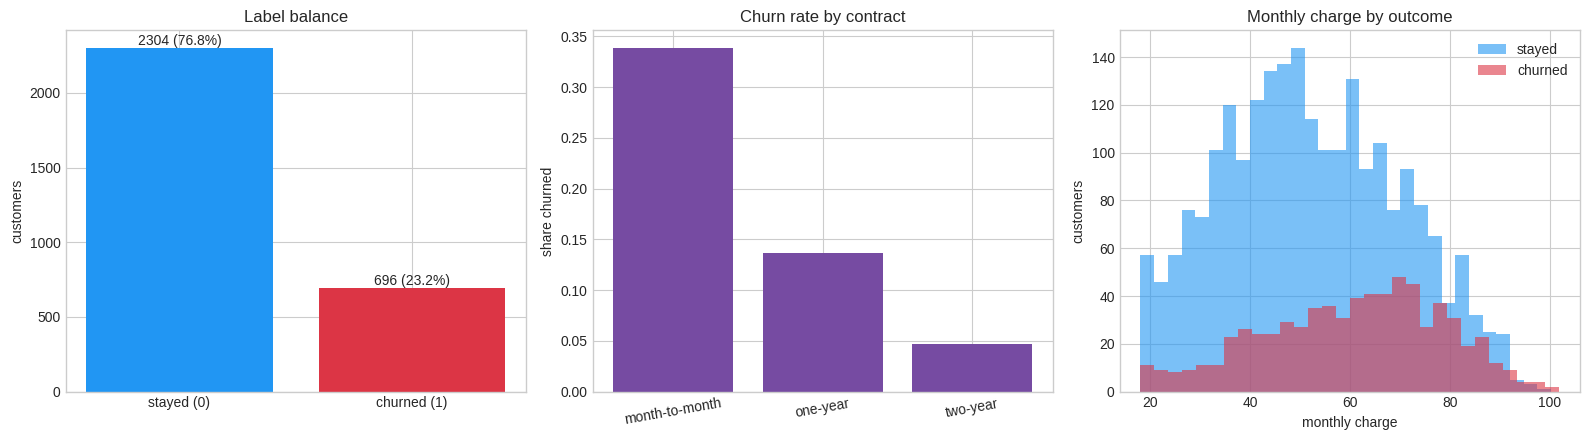

churn rate: 23.2% overall | by contract: {'month-to-month': 0.339, 'one-year': 0.137, 'two-year': 0.047}


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
counts = churn["churned"].value_counts().sort_index()
axes[0].bar(["stayed (0)", "churned (1)"], counts.values, color=["#2196F3", "#dc3545"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v} ({v / len(churn):.1%})", ha="center", va="bottom")
axes[0].set_title("Label balance"); axes[0].set_ylabel("customers")

by_contract = churn.groupby("contract")["churned"].mean().loc[["month-to-month", "one-year", "two-year"]]
axes[1].bar(by_contract.index, by_contract.values, color="#764ba2")
axes[1].set_title("Churn rate by contract"); axes[1].set_ylabel("share churned"); axes[1].tick_params(axis="x", rotation=10)

for lab, col, name in ((0, "#2196F3", "stayed"), (1, "#dc3545", "churned")):
    axes[2].hist(churn.loc[churn.churned == lab, "monthly_charge"], bins=30, alpha=0.6, color=col, label=name)
axes[2].set_title("Monthly charge by outcome"); axes[2].set_xlabel("monthly charge"); axes[2].set_ylabel("customers"); axes[2].legend()
plt.tight_layout(); plt.show()
print(f"churn rate: {churn.churned.mean():.1%} overall | by contract: {by_contract.round(3).to_dict()}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: about one customer in four churned, so a model that always says "stays" is right three times in four. That is the number every accuracy must be compared with. Middle: the churn rate by contract type falls steeply from month-to-month to two-year, the strongest single signal in the table. Right: the monthly-charge histograms of the two outcomes overlap heavily but the churned hump sits to the right; price matters, but on its own it separates the classes poorly.

The common misread: reading the middle panel as "contract type predicts churn". It shifts the *rate*; most month-to-month customers still stay. The model's job is to combine this with the other columns.

</div>

## 2.3 💻 Three lines

`eval_metric="roc_auc"` tells AutoGluon that what matters is the *ranking* of customers by risk, which is exactly what the retention team asked for. `time_limit` caps the training wall-clock, `presets="medium_quality"` picks the fast preset (a single validation holdout, no bagging), `num_cpus` keeps the fit predictable on a shared machine, and `path` is where the trained models are saved.


In [5]:
import inspect
assert "num_cpus" in inspect.signature(TabularPredictor.fit).parameters      # verified against AutoGluon 1.6.3

with timer("Part 1 fit"):
    pred_churn = TabularPredictor(label="churned", eval_metric="roc_auc", path=os.path.join(WORK, "part1"), verbosity=0).fit(
        train_c, time_limit=45, presets="medium_quality", num_cpus=N_CPUS)

print(f"problem type inferred: {pred_churn.problem_type} | eval metric: {pred_churn.eval_metric.name} | "
      f"models trained: {len(pred_churn.model_names())} | best on validation: {pred_churn.model_best}")


⏱️ Part 1 fit: 31.7 s
problem type inferred: binary | eval metric: roc_auc | models trained: 12 | best on validation: WeightedEnsemble_L2


## 2.4 📤 The output

Three things come back. The **leaderboard** is one row per trained model, scored on the test split (`score_test`) and on AutoGluon's own validation holdout (`score_val`); the ensemble at the top is a weighted blend of the others. **`predict_proba`** returns one column per class, so column `1` is P(churn) for each customer. **`predict`** is the same probability cut at 0.5. The `report_card` puts threshold, ranking and probabilistic metrics in one row so every Part reports the same way.


In [6]:
lb_churn = pred_churn.leaderboard(test_c)
display(pretty(lb_churn[["model", "score_test", "score_val", "pred_time_test", "fit_time", "stack_level"]].set_index("model"),
               subset=["score_test", "score_val"]))

proba_c = pred_churn.predict_proba(test_c)                  # DataFrame with columns 0 and 1
label_c = pred_churn.predict(test_c)
out_c = test_c[["tenure_months", "monthly_charge", "contract", "num_support_calls"]].copy()
out_c["P(churn)"] = proba_c[1].round(3); out_c["predicted"] = label_c.values; out_c["actual"] = test_c["churned"].values
print("predict_proba(test) has columns", list(proba_c.columns), "-> the first five customers with their prediction:")
display(out_c.head())

card_churn = report_card(test_c["churned"], label_c, proba_c[1], name=f"churn · {pred_churn.model_best}")
display(pretty(card_churn))
print(f"base rate (always 'stays') accuracy = {1 - test_c.churned.mean():.3f}; the model's accuracy = {card_churn.iloc[0]['accuracy']:.3f}; "
      f"roc_auc = {card_churn.iloc[0]['roc_auc']:.3f}")


,score_test,score_val,pred_time_test,fit_time,stack_level
model,,,,,
CatBoost,0.881,0.852,0.013,7.141,1.000
WeightedEnsemble_L2,0.874,0.863,0.283,19.941,2.000
NeuralNetTorch,0.857,0.836,0.026,7.310,1.000
LightGBMXT,0.856,0.849,0.014,3.069,1.000
LightGBM,0.853,0.837,0.011,0.780,1.000
ExtraTreesEntr,0.851,0.846,0.125,1.062,1.000
ExtraTreesGini,0.849,0.847,0.112,1.052,1.000
RandomForestGini,0.846,0.848,0.129,1.361,1.000
XGBoost,0.846,0.837,0.017,0.995,1.000


predict_proba(test) has columns [0, 1] -> the first five customers with their prediction:


,tenure_months,monthly_charge,contract,num_support_calls,P(churn),predicted,actual
848,60,52.76,month-to-month,0,0.135,0,0
282,49,42.20,month-to-month,2,0.145,0,0
643,35,43.85,two-year,2,0.061,0,0
2476,38,55.38,month-to-month,2,0.209,0,0
1527,10,47.27,two-year,1,0.011,0,0


,accuracy,balanced_acc,precision,recall,f1,mcc,roc_auc,pr_auc,log_loss,brier
model,,,,,,,,,,
churn · WeightedEnsemble_L2,0.837,0.720,0.713,0.500,0.588,0.502,0.874,0.683,0.364,0.115


base rate (always 'stays') accuracy = 0.768; the model's accuracy = 0.837; roc_auc = 0.874


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Compare accuracy with the base rate, then stop reading it

The cell printed the accuracy of always saying "stays" next to the model's accuracy. The gap is what the model learned; the accuracy on its own flatters any model on an imbalanced label. `roc_auc` (the chance that a random churner is ranked above a random stayer) and `pr_auc` are what the ranking question needs, and `log_loss` says whether the probabilities themselves can be trusted.

</div>


### The text column was used, automatically

`feature_metadata_in` is what AutoGluon believed about each raw column; `feature_metadata` is the set of columns after its own preprocessing. The complaint text becomes a bag of n-gram counts plus a few "special" text statistics (length, word count, capital letters), with no code on your side.


In [7]:
fm_in = pred_churn.feature_metadata_in
print("raw types AutoGluon saw:")
print(fm_in)
generated = pred_churn.feature_metadata.get_features()
ngram_cols = [c for c in generated if c.startswith("__nlp__")]
special_cols = pred_churn.feature_metadata.get_features(required_special_types=["text_special"])
print(f"\nafter preprocessing: {len(generated)} features from {len(fm_in.get_features())} raw columns")
print(f"  n-gram count features from `last_complaint`: {len(ngram_cols)}, e.g. {ngram_cols[:6]}")
print(f"  text statistics: {len(special_cols)}, e.g. {special_cols[:4]}")


raw types AutoGluon saw:
('bool', [])         : 1 | ['streaming']
('float', [])        : 2 | ['monthly_charge', 'total_gb']
('int', [])          : 2 | ['tenure_months', 'num_support_calls']
('object', [])       : 2 | ['contract', 'payment_method']
('object', ['text']) : 1 | ['last_complaint']

after preprocessing: 34 features from 8 raw columns
  n-gram count features from `last_complaint`: 14, e.g. ['__nlp__.as', '__nlp__.back', '__nlp__.fix', '__nlp__.getting', '__nlp__.honestly', '__nlp__.my']
  text statistics: 12, e.g. ['last_complaint.char_count', 'last_complaint.word_count', 'last_complaint.capital_ratio', 'last_complaint.lower_ratio']


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: print `feature_metadata_in` before reading any score

The raw-type list is where surprises live: an ID column read as a category, a category read as text, a numeric code read as a number. Here it should show `last_complaint` as `('object', ['text'])` and `contract` as a plain `object` (a category). Whenever a fit does something odd, this one line explains more than any hyperparameter.

</div>

## 2.5 📊 The picture

The ROC curve is every threshold at once: true-positive rate against false-positive rate, with the no-skill diagonal. The precision-recall curve is the same probabilities seen through a harsher lens: its no-skill line is the churn rate, and it shows what the last few churners cost in false alarms.


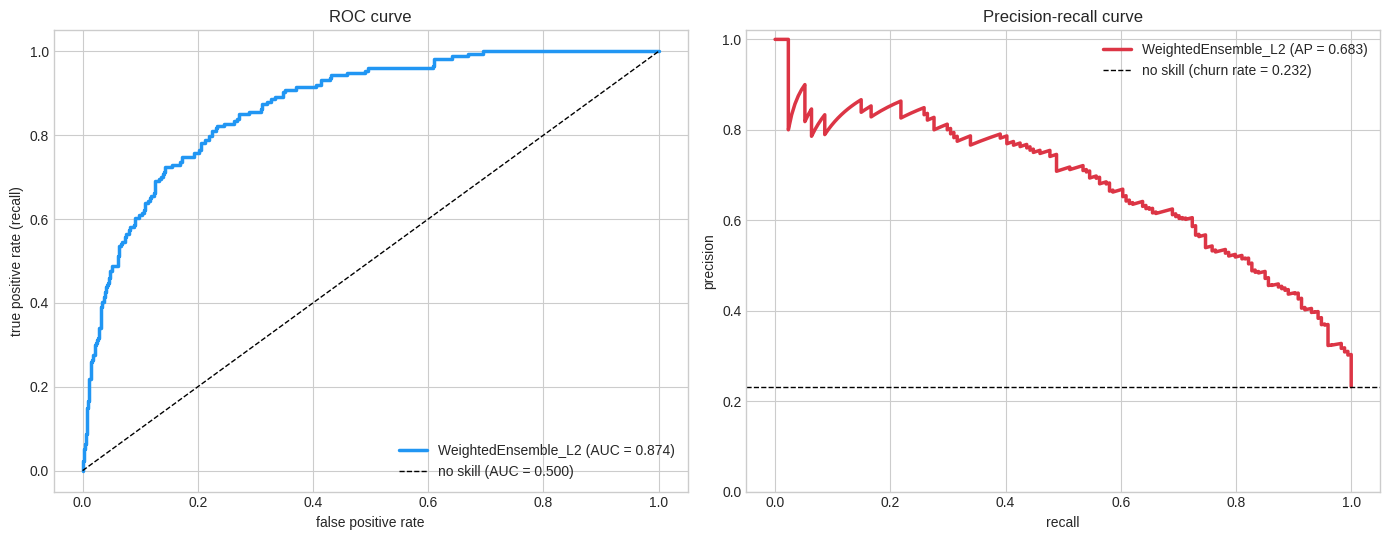

to catch 80% of churners the threshold must drop to 0.233, which also flags 22.4% of the customers who stay


In [8]:
from sklearn.metrics import roc_curve, precision_recall_curve

y_c = test_c["churned"].values; p_c = proba_c[1].values
fpr, tpr, thr = roc_curve(y_c, p_c); prec, rec, _ = precision_recall_curve(y_c, p_c)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].plot(fpr, tpr, color="#2196F3", lw=2.5, label=f"{pred_churn.model_best} (AUC = {roc_auc_score(y_c, p_c):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="no skill (AUC = 0.500)")
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate (recall)"); axes[0].set_title("ROC curve"); axes[0].legend(loc="lower right")
axes[1].plot(rec, prec, color="#dc3545", lw=2.5, label=f"{pred_churn.model_best} (AP = {average_precision_score(y_c, p_c):.3f})")
axes[1].axhline(y_c.mean(), color="k", ls="--", lw=1, label=f"no skill (churn rate = {y_c.mean():.3f})")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision"); axes[1].set_title("Precision-recall curve"); axes[1].set_ylim(0, 1.02); axes[1].legend(loc="upper right")
plt.tight_layout(); plt.show()

k = np.argmax(tpr >= 0.8)
print(f"to catch 80% of churners the threshold must drop to {thr[k]:.3f}, which also flags {fpr[k]:.1%} of the customers who stay")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the ROC curve bows toward the top-left corner; the further from the diagonal, the better the model orders churners above stayers. Right: precision falls as recall rises. Catching the last churners means calling many customers who would have stayed anyway. The printed line makes it concrete: the threshold needed for 80% recall and the share of loyal customers it flags.

The common misread: comparing the two areas on one scale. ROC-AUC's floor is 0.5; PR-AUC's floor is the churn rate. A PR-AUC of two or three times its floor is a strong model.

</div>

### Who to call first

The retention team wants a list, not a curve. Sort the test customers by P(churn) and look at the top ten with their features.


In [9]:
riskiest = out_c.sort_values("P(churn)", ascending=False).head(10)
riskiest.insert(0, "rank", range(1, 11))
display(riskiest.set_index("rank"))
print(f"of the 10 riskiest customers, {riskiest.actual.sum()} actually churned; "
      f"in the whole test split the churn rate is {test_c.churned.mean():.1%}")
print(f"contracts among the top 10: {riskiest.contract.value_counts().to_dict()} | mean support calls: {riskiest.num_support_calls.mean():.1f}")


,tenure_months,monthly_charge,contract,num_support_calls,P(churn),predicted,actual
rank,,,,,,,
1,14,81.64,month-to-month,3,0.928,1,1
2,25,60.79,month-to-month,2,0.904,1,1
3,52,57.41,month-to-month,2,0.900,1,1
4,33,73.37,month-to-month,2,0.882,1,1
5,60,72.31,month-to-month,2,0.874,1,0
6,58,70.35,month-to-month,1,0.868,1,1
7,25,69.46,month-to-month,3,0.867,1,1
8,29,70.03,month-to-month,4,0.865,1,1
9,39,63.05,month-to-month,4,0.862,1,1


of the 10 riskiest customers, 9 actually churned; in the whole test split the churn rate is 23.2%
contracts among the top 10: {'month-to-month': 10} | mean support calls: 2.5


### Why: feature importance

`feature_importance(test)` measures each raw column by **permutation**: shuffle one column, re-score the model, and record how much `roc_auc` drops. A large drop means the model relied on that column. The result comes with a standard deviation over repeated shuffles and a p-value against "no drop at all".


⏱️ feature_importance (permutation, 3 shuffles): 2.7 s


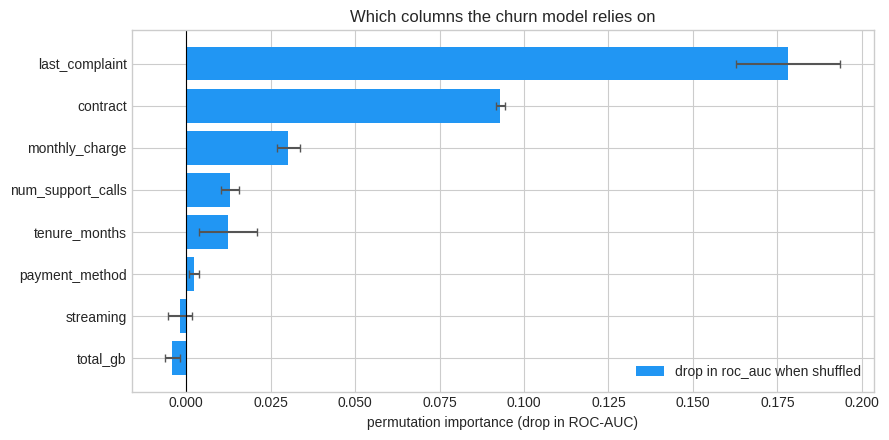

                   importance  stddev  p_value
last_complaint         0.1781  0.0154   0.0012
contract               0.0930  0.0013   0.0000
monthly_charge         0.0303  0.0035   0.0022
num_support_calls      0.0130  0.0028   0.0074
tenure_months          0.0123  0.0085   0.0644
payment_method         0.0023  0.0014   0.0526
streaming             -0.0017  0.0035   0.7557
total_gb              -0.0040  0.0021   0.9601


In [10]:
with timer("feature_importance (permutation, 3 shuffles)"):
    fi_churn = pred_churn.feature_importance(test_c, subsample_size=750, num_shuffle_sets=3, time_limit=45, silent=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
fi_plot = fi_churn.sort_values("importance")
ax.barh(fi_plot.index, fi_plot["importance"], xerr=fi_plot["stddev"], color="#2196F3", ecolor="#555", capsize=3, label="drop in roc_auc when shuffled")
ax.axvline(0, color="k", lw=0.8); ax.set_xlabel("permutation importance (drop in ROC-AUC)"); ax.set_title("Which columns the churn model relies on")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()
print(fi_churn[["importance", "stddev", "p_value"]].round(4).to_string())


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each bar is one raw input column; its length is how much ROC-AUC the model loses when that column is scrambled, with the error bar showing the spread over shuffles. The complaint text sits at or near the top: churners complain more often and more often about price, and the n-gram counts caught that without any code. The planted numeric drivers (contract, monthly charge, support calls, tenure) follow. A bar whose error bar crosses zero, with a p-value above 0.05 in the printed table, is a column the model could do without.

The common misread: reading importance as causation. Shuffling a column measures what the *model* uses, not what makes customers leave; a column can be important because it proxies for something unmeasured.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ A text column at the top of the importance list deserves a question: when was it written?

The complaint helps because it was recorded *before* the customer left. If the operator's system logged the "last complaint" at the moment of cancellation ("I am switching to another provider"), the column would be a **leak**: information that exists only after the outcome is known, and that will not exist for the customers the model is meant to score next month. AutoGluon cannot tell the difference; the importance table is where a leak first shows itself, as a column that is suspiciously strong.

</div>

## 2.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

**Reach for binary classification** whenever the question is yes/no per row and the rows fit in a table: churn, default, conversion, failure, fraud (Part 5 covers the rare-event version). Give it a DataFrame with a two-valued label; everything else, including text columns, is inferred.

**What it costs:** a `time_limit` of a minute on a few thousand rows gives a usable model; more time buys bagging and stacking, not a different answer. The output is a probability, so the decision threshold is a separate business choice.

**The one gotcha:** choose `eval_metric` for the question. `roc_auc` for ranking, `f1` or a cost for a fixed decision, `log_loss` when the probabilities will be shown to a person. The default metric optimises accuracy, which the base rate has already shown to be the least informative number here.

</div>


## 2.7 Task 2 Summary

**✅ Key Takeaways**
- A two-valued label makes `TabularPredictor` infer `binary`; the text column was expanded into n-grams without any code.
- The leaderboard has two scores: `score_val` chose the winner, `score_test` on your own split is the honest one.
- `predict_proba` gives the ranked list the business asked for; `predict` is that list cut at 0.5.
- Accuracy must be read against the base rate; ROC-AUC and PR-AUC answer the ranking question.
- Permutation importance says which columns the model relies on, with a spread and a p-value.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `make_churn`, `churn`, `train_c`, `test_c` | the generator, the table, and its stratified split |
| `pred_churn`, `lb_churn` | the fitted predictor and its test leaderboard |
| `proba_c`, `label_c`, `out_c`, `riskiest` | probabilities, labels, the per-customer output table, and the top ten |
| `card_churn`, `fi_churn` | the report card and the permutation importances |

**➡️ Next Up:** Part 2 — the label has five values, not two: loan grades A to E.


# Part 2 · Multiclass classification · loan grades ⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The capability

**Multiclass classification** assigns each row to one of several labels. The three lines do not change; what changes is the shape of the output (one probability per class) and the way it is judged (a confusion matrix instead of one curve). Part 2 grades loan applications from A (safest) to E (riskiest) and shows what a model that treats the grades as unordered names gets right and what it gets wrong.

</div>

# Task 3 · Which grade does this application get?

## 3.1 ❓ The problem

A lender assigns every application a **grade** from A to E that sets the interest rate. Today an analyst does it by hand from the applicant's income, debts and history. The credit team asks: **can a model reproduce the grading so the analysts only review the borderline cases?** A good answer says, for each application, how likely each grade is, so a "B or C" case is visible as such.


## 3.2 📥 The input

One row per application. The grade is derived from a hidden risk score that combines debt-to-income ratio, delinquencies, credit history, income, employment and the size of the loan relative to income, plus noise. The five grades are deliberately **imbalanced**: C is the most common, A and E are rare.


In [11]:
def make_loans(n=3000, seed=RANDOM_STATE):
    """One row per loan application; the grade A..E is a noisy quantile cut of a hidden risk score."""
    rng = np.random.default_rng(seed)
    income = rng.lognormal(np.log(65_000), 0.45, n).round(-2)
    dti = (rng.beta(2, 5, n) * 0.6).round(3)                                          # debt-to-income ratio, 0..0.6
    history = rng.integers(0, 30, n)                                                  # years of credit history
    delinq = rng.poisson(0.6, n)                                                      # delinquencies in the last 5 years
    loan_amount = (income * rng.uniform(0.05, 0.6, n)).round(-2)
    purpose = rng.choice(["debt consolidation", "home improvement", "car", "medical", "business", "education"], n,
                         p=[0.35, 0.15, 0.15, 0.10, 0.15, 0.10])
    employment = rng.choice(["salaried", "self-employed", "contract", "retired", "unemployed"], n, p=[0.55, 0.18, 0.12, 0.10, 0.05])
    risk = (4.5 * dti + 0.35 * delinq - 0.04 * history - 0.6 * np.log(income / 65_000) + 0.4 * loan_amount / income
            + 0.5 * (employment == "unemployed") + 0.25 * (employment == "self-employed") + 0.3 * (purpose == "business")
            + rng.normal(0, 0.45, n))
    grade = pd.qcut(risk, [0, 0.10, 0.35, 0.70, 0.90, 1.0], labels=list("ABCDE")).astype(str)
    return pd.DataFrame({"income": income, "debt_to_income": dti, "credit_history_years": history, "num_delinquencies": delinq,
                         "loan_amount": loan_amount, "purpose": purpose, "employment": employment, "grade": grade})

loans = make_loans()
GRADES = list("ABCDE")
train_l, test_l = train_test_split(loans, test_size=0.25, random_state=RANDOM_STATE, stratify=loans["grade"])
show_input(loans, label="grade", name="loan applications")
print(f"train {len(train_l):,} rows, test {len(test_l):,} rows (stratified on grade)")


📥 loan applications: 3,000 rows x 8 columns | label = 'grade'


,income,debt_to_income,credit_history_years,num_delinquencies,loan_amount,purpose,employment,grade
0,74600.0,0.163,20,1,25100.0,debt consolidation,retired,C
1,40700.0,0.277,17,2,23300.0,debt consolidation,contract,D
2,91100.0,0.061,25,0,29400.0,debt consolidation,salaried,B
3,99200.0,0.085,8,2,53600.0,medical,salaried,C
4,27000.0,0.090,15,1,1900.0,medical,salaried,C


column types: {'income': 'numeric', 'debt_to_income': 'numeric', 'credit_history_years': 'numeric', 'num_delinquencies': 'numeric', 'loan_amount': 'numeric', 'purpose': 'text/category', 'employment': 'text/category', 'grade': 'text/category'}
label distribution: {'C': 0.35, 'B': 0.25, 'D': 0.2, 'E': 0.1, 'A': 0.1}
train 2,250 rows, test 750 rows (stratified on grade)


| Column | Type | Meaning | What AutoGluon will infer |
|---|---|---|---|
| `income` | float | annual income | numeric |
| `debt_to_income` | float | monthly debt payments / monthly income | numeric |
| `credit_history_years` | int | years since the first credit line | numeric |
| `num_delinquencies` | int | late payments in the last five years | numeric |
| `loan_amount` | float | amount requested | numeric |
| `purpose` | str | six purposes | category |
| `employment` | str | five employment types | category |
| `grade` | str | **the label**, `A` (safest) to `E` | five values, so the problem type is `multiclass` |

The grade is a string with five distinct values, so AutoGluon infers `multiclass` and internally maps the five names to integers 0..4. It does **not** know that A < B < C < D < E; to the model they are five unrelated names. Section 3.5 measures what that costs.


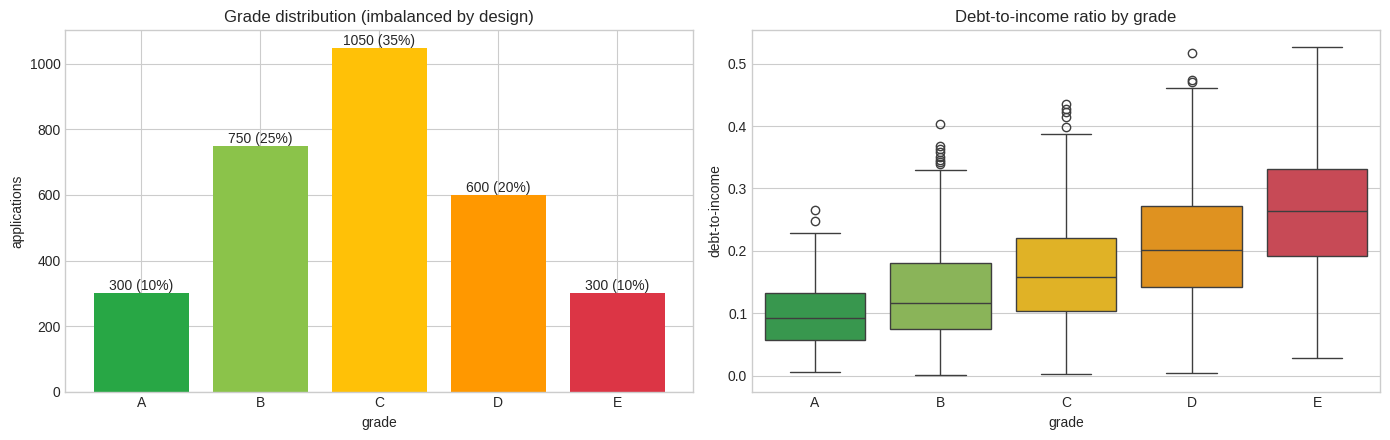

grade shares: {'A': 0.1, 'B': 0.25, 'C': 0.35, 'D': 0.2, 'E': 0.1}
median debt-to-income per grade: {'A': 0.093, 'B': 0.117, 'C': 0.158, 'D': 0.201, 'E': 0.264}


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
gc = loans["grade"].value_counts().loc[GRADES]
palette = ["#28a745", "#8bc34a", "#ffc107", "#ff9800", "#dc3545"]
axes[0].bar(GRADES, gc.values, color=palette)
for i, v in enumerate(gc.values):
    axes[0].text(i, v, f"{v} ({v / len(loans):.0%})", ha="center", va="bottom")
axes[0].set_title("Grade distribution (imbalanced by design)"); axes[0].set_xlabel("grade"); axes[0].set_ylabel("applications")
sns.boxplot(data=loans, x="grade", y="debt_to_income", order=GRADES, palette=palette, ax=axes[1])
axes[1].set_title("Debt-to-income ratio by grade"); axes[1].set_xlabel("grade"); axes[1].set_ylabel("debt-to-income")
plt.tight_layout(); plt.show()
print("grade shares:", (gc / len(loans)).round(3).to_dict())
print("median debt-to-income per grade:", loans.groupby("grade")["debt_to_income"].median().loc[GRADES].round(3).to_dict())


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the five classes are far from equal; C alone is over a third of the table and A and E are a tenth each. Always predicting C would already be right a third of the time, so accuracy alone is a weak judge here. Right: the debt-to-income ratio rises grade by grade, but the boxes overlap: a single feature cannot separate neighbours like B and C, and the model has to combine it with delinquencies, history and income.

The common misread: taking the neat staircase of medians as "the grade is easy to predict". The medians are ordered; the *individual* applications are not, because the boxes overlap and the generator added noise before the cut.

</div>

## 3.3 💻 Three lines

Nothing in the call says "multiclass"; AutoGluon sees five distinct label values and decides. No `eval_metric` is passed this time, so the cell prints the default that AutoGluon picks for the inferred problem type.


In [13]:
import os
import tempfile
import time as _time
from contextlib import contextmanager
from autogluon.tabular import TabularPredictor

# Redefining setup variables in case of a session restart
N_CPUS = max(1, min(4, os.cpu_count() or 2))
WORK = tempfile.gettempdir() # Re-use system temp directory securely

@contextmanager
def timer(label="block"):
    t0 = _time.perf_counter()
    yield
    print(f"⏱️ {label}: {_time.perf_counter() - t0:.1f} s")

with timer("Part 2 fit"):
    pred_loans = TabularPredictor(label="grade", path=os.path.join(WORK, "part2"), verbosity=0).fit(
        train_l, time_limit=45, presets="medium_quality", num_cpus=N_CPUS)

print(f"problem type inferred: {pred_loans.problem_type} | default eval metric for it: {pred_loans.eval_metric.name} | ")
print(f"classes as the predictor sees them: {pred_loans.class_labels}")
print(f"models trained: {len(pred_loans.model_names())} | best on validation: {pred_loans.model_best}")

⏱️ Part 2 fit: 44.9 s
problem type inferred: multiclass | default eval metric for it: accuracy | 
classes as the predictor sees them: ['A', 'B', 'C', 'D', 'E']
models trained: 12 | best on validation: WeightedEnsemble_L2


## 3.4 📤 The output

`leaderboard` can carry extra metrics next to the main one (`extra_metrics=[...]`): log loss says whether the five probabilities are calibrated, balanced accuracy averages the per-class recalls so the rare grades A and E count as much as C. `predict_proba` now returns **five columns**, one per grade, summing to one per row; `predict` picks the largest.


In [14]:
lb_loans = pred_loans.leaderboard(test_l, extra_metrics=["log_loss", "balanced_accuracy"])
display(pretty(lb_loans[["model", "score_test", "log_loss", "balanced_accuracy", "score_val", "pred_time_test", "fit_time"]].set_index("model"),
               subset=["score_test", "log_loss", "balanced_accuracy", "score_val"]))

proba_l = pred_loans.predict_proba(test_l)                   # columns A..E
label_l = pred_loans.predict(test_l)
out_l = test_l[["income", "debt_to_income", "num_delinquencies", "employment"]].copy()
for g in GRADES:
    out_l[f"P({g})"] = proba_l[g].round(3)
out_l["predicted"] = label_l.values; out_l["actual"] = test_l["grade"].values
print("predict_proba(test) has one column per class:", list(proba_l.columns), "-> five applicants:")
display(out_l.head())
print(f"each row's probabilities sum to {proba_l.sum(axis=1).round(6).unique()} ; predict() = the argmax column")
print("note: log_loss is shown negated (higher is better), as every AutoGluon score is")


,score_test,log_loss,balanced_accuracy,score_val,pred_time_test,fit_time
model,,,,,,
NeuralNetTorch,0.519,-1.062,0.514,0.571,0.021,7.900
WeightedEnsemble_L2,0.517,-1.043,0.509,0.573,0.186,9.766
NeuralNetFastAI,0.509,-1.073,0.506,0.538,0.030,2.855
CatBoost,0.501,-1.059,0.458,0.542,0.017,12.679
ExtraTreesGini,0.499,-1.121,0.451,0.491,0.138,1.149
LightGBMXT,0.493,-1.081,0.461,0.518,0.053,1.513
RandomForestEntr,0.483,-1.111,0.446,0.491,0.161,1.750
ExtraTreesEntr,0.481,-1.126,0.429,0.500,0.161,1.545
LightGBM,0.479,-1.142,0.449,0.511,0.033,1.749


predict_proba(test) has one column per class: ['A', 'B', 'C', 'D', 'E'] -> five applicants:


,income,debt_to_income,num_delinquencies,employment,P(A),P(B),P(C),P(D),P(E),predicted,actual
426,93300.0,0.189,1,salaried,0.366,0.447,0.176,0.011,0.000,B,B
2260,22300.0,0.254,2,contract,0.000,0.010,0.052,0.195,0.743,E,E
210,98200.0,0.217,0,salaried,0.095,0.534,0.316,0.055,0.000,B,B
2805,68300.0,0.086,0,contract,0.046,0.529,0.394,0.029,0.002,B,B
413,91100.0,0.106,0,retired,0.428,0.491,0.073,0.007,0.001,B,B


each row's probabilities sum to [1.] ; predict() = the argmax column
note: log_loss is shown negated (higher is better), as every AutoGluon score is


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Every AutoGluon score is "higher is better"

The `log_loss` column in the leaderboard is negative. AutoGluon negates every metric where smaller is better (log loss, RMSE, MAE) so that sorting by score always puts the best model first. Read `-0.9` as a log loss of 0.9. Part 3 meets the same convention with MAE.

</div>


### One report per class

`report_card` was built for two classes (its precision and recall assume a positive class), so the multiclass report comes from scikit-learn's `classification_report`, turned into a DataFrame so `pretty` can highlight it. Precision is "of the applications the model graded B, how many were B"; recall is "of the true B's, how many did it find".


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

rep = pd.DataFrame(classification_report(test_l["grade"], label_l, labels=GRADES, output_dict=True, zero_division=0)).T
rep_classes = rep.loc[GRADES].copy(); rep_classes["support"] = rep_classes["support"].astype(int)
display(pretty(rep_classes, subset=["precision", "recall", "f1-score"]))

card_loans = pd.DataFrame([{"model": f"loans · {pred_loans.model_best}", "accuracy": accuracy_score(test_l["grade"], label_l),
                            "balanced_acc": balanced_accuracy_score(test_l["grade"], label_l),
                            "macro_f1": rep.loc["macro avg", "f1-score"], "weighted_f1": rep.loc["weighted avg", "f1-score"],
                            "log_loss": log_loss(test_l["grade"], proba_l[GRADES].values, labels=GRADES)}]).set_index("model")
display(pretty(card_loans))

# the price of treating an ordinal label as nominal: how far off are the mistakes?
idx = {g: i for i, g in enumerate(GRADES)}
dist = np.abs(test_l["grade"].map(idx).values - label_l.map(idx).values)
print(f"always-'C' accuracy = {(test_l.grade == 'C').mean():.3f} vs model accuracy = {card_loans.iloc[0]['accuracy']:.3f}")
print(f"errors: {np.mean(dist == 0):.1%} exact, {np.mean(dist == 1):.1%} off by one grade, {np.mean(dist >= 2):.1%} off by two or more")


,precision,recall,f1-score,support
A,0.680,0.453,0.544,75.000
B,0.486,0.564,0.522,188.000
C,0.517,0.523,0.520,262.000
D,0.438,0.473,0.455,150.000
E,0.727,0.533,0.615,75.000


,accuracy,balanced_acc,macro_f1,weighted_f1,log_loss
model,,,,,
loans · WeightedEnsemble_L2,0.517,0.509,0.531,0.519,1.043


always-'C' accuracy = 0.349 vs model accuracy = 0.517
errors: 51.7% exact, 44.7% off by one grade, 3.6% off by two or more


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Ordinal labels, nominal model

The grades are **ordinal** (A < B < C < D < E), but `multiclass` treats them as **nominal**: five names with no order. Two things follow. The model's loss counts a B graded as A exactly the same as a B graded as E, so it never learns that near misses are cheaper. And the printed breakdown shows the consequence in this run: almost every error is off by exactly one grade, which is what you would expect from neighbouring classes that overlap, and hardly any are two or more grades away. That pattern is a feature of the data, not a reward the model was given.

</div>

## 3.5 📊 The picture

A confusion matrix is the multiclass equivalent of one curve: rows are the true grade, columns the predicted one, and each row is normalised so the diagonal reads as per-class recall. Next to it, the five probabilities for eight applicants, stacked so each bar is one application summing to one.


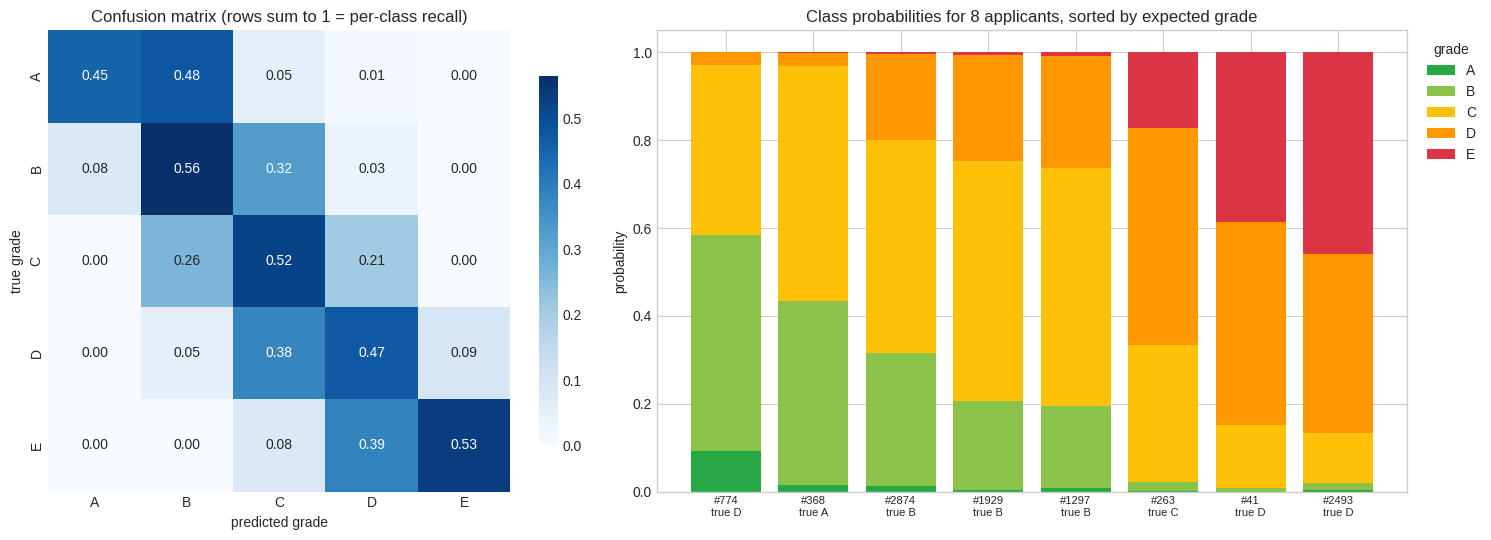

per-class recall (the diagonal): {'A': 0.453, 'B': 0.564, 'C': 0.523, 'D': 0.473, 'E': 0.533}
most confused pair: true A predicted as B (0.48 of the true-A row)


In [16]:
cm = confusion_matrix(test_l["grade"], label_l, labels=GRADES, normalize="true")
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1, 1.3]})
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=GRADES, yticklabels=GRADES, ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_xlabel("predicted grade"); axes[0].set_ylabel("true grade"); axes[0].set_title("Confusion matrix (rows sum to 1 = per-class recall)")

# eight applicants, sorted by their expected grade index (sum of probability x grade position)
sample = proba_l[GRADES].sample(8, random_state=RANDOM_STATE)
expected = (sample.values * np.arange(5)).sum(axis=1)
sample = sample.iloc[np.argsort(expected)]
bottom = np.zeros(len(sample))
for g, col in zip(GRADES, palette):
    axes[1].bar(range(len(sample)), sample[g].values, bottom=bottom, color=col, label=g); bottom += sample[g].values
truth = test_l.loc[sample.index, "grade"].values
axes[1].set_xticks(range(len(sample))); axes[1].set_xticklabels([f"#{i}\ntrue {t}" for i, t in zip(sample.index, truth)], fontsize=8)
axes[1].set_ylabel("probability"); axes[1].set_title("Class probabilities for 8 applicants, sorted by expected grade"); axes[1].legend(title="grade", loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout(); plt.show()
print("per-class recall (the diagonal):", {g: round(float(r), 3) for g, r in zip(GRADES, cm.diagonal())})
off_diag = cm - np.eye(5) * 2                                   # hide the diagonal, then find the largest confusion
ti, pj = np.unravel_index(np.argmax(off_diag), cm.shape)
print(f"most confused pair: true {GRADES[ti]} predicted as {GRADES[pj]} ({off_diag[ti, pj]:.2f} of the true-{GRADES[ti]} row)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the mass sits on the diagonal and spills only into the cells next to it. The off-by-one band is the model confusing neighbouring grades, and the printed most-confused pair is one of those neighbours. The diagonal is not uniform: the majority grade C tends to have a high recall because the model leans toward the most common class when it is unsure, and a grade squeezed between two neighbours (B, D) loses applications to both sides. The printed recalls say which rows were hardest in this run. Right: each bar is one applicant; a bar dominated by one colour is a clear case, a bar split between two adjacent colours is the "B or C" case the credit team wanted to see. Sorting by expected grade puts the safest applicants on the left.

The common misread: reading a split bar as a model failure. A 50/50 split between B and C on an application that sits on the B/C boundary is the right answer; it is exactly the case to route to an analyst.

</div>

## 3.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

**Reach for multiclass classification** when each row gets exactly one of more than two labels: grades, product categories, ticket queues, failure modes. The label can be strings; the three lines do not change.

**What it costs:** the same time as binary; the leaderboard's default metric is accuracy, so pass `eval_metric="log_loss"` when the probabilities matter or `"balanced_accuracy"` when the rare classes matter.

**The one gotcha:** ordinal labels are treated as nominal. The model is not rewarded for near misses. If the order matters to the business, either accept that (the confusion matrix shows how far off the misses are), collapse the grades into fewer bands, or model the hidden score with regression, which is exactly Part 3.

</div>


## 3.7 Task 3 Summary

**✅ Key Takeaways**
- Five label values make AutoGluon infer `multiclass`; its default metric is accuracy, and `extra_metrics` adds log loss and balanced accuracy to the leaderboard.
- `predict_proba` returns one column per class summing to one; `predict` is the argmax.
- The per-class report and the row-normalised confusion matrix replace ROC and PR curves; the majority grade gets the benefit of the doubt, grades with two neighbours lose to both.
- Ordinal grades are modelled as unordered names; the errors are almost all off by one grade, which the data causes and the model does not reward.
- A split probability bar is the borderline case to route to a person, not a failure.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `make_loans`, `loans`, `GRADES`, `train_l`, `test_l` | the generator, the table, the class order, the split |
| `pred_loans`, `lb_loans` | the fitted predictor and its leaderboard with extra metrics |
| `proba_l`, `label_l`, `out_l` | the five-column probabilities, the labels, and the per-applicant table |
| `rep`, `rep_classes`, `card_loans`, `cm` | the per-class report, the one-row summary, and the normalised confusion matrix |

**➡️ Next Up:** Part 3 — the label is a number: house prices.


# Part 3 · Regression · house prices ⭐

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The capability

**Regression** predicts a number: a price, a duration, a demand, a score. The label column is numeric with many distinct values, and AutoGluon infers `regression`. The three lines are the same; the output is a single number per row and it is judged by how far off it is, in the label's own units. Part 3 prices houses, looks at where the errors are, and tries the single most useful trick for a skewed target: predicting its logarithm.

</div>

# Task 4 · What is this house worth?

## 4.1 ❓ The problem

A property portal shows an estimated price on every listing. Sellers use it to set an asking price and buyers use it to spot bargains. The product team asks: **given a listing's size, age, location and features, what will it sell for, and how far off is the estimate typically?** A good answer is a number in dollars plus an honest typical error, so the portal can show "estimate ± X".


## 4.2 📥 The input

One row per sale. The price is built as a product of effects (size, neighbourhood, bathrooms, age, lot, garage, distance to the centre) with multiplicative noise, so it is **right-skewed**: many ordinary houses and a long tail of expensive ones. Six neighbourhoods have different base prices, which is the kind of categorical effect a regressor has to learn.


In [17]:
def make_houses(n=3000, seed=RANDOM_STATE):
    """One row per house sale; the price is a log-normal-ish product of size, location and feature effects."""
    rng = np.random.default_rng(seed)
    hoods = ["Riverside", "Old Town", "Hillcrest", "Eastgate", "Meadows", "Industrial"]
    base = {"Riverside": 0.35, "Old Town": 0.15, "Hillcrest": 0.45, "Eastgate": 0.0, "Meadows": 0.10, "Industrial": -0.25}
    neighborhood = rng.choice(hoods, n, p=[0.15, 0.15, 0.12, 0.22, 0.24, 0.12])
    sqft = np.clip(rng.lognormal(np.log(1800), 0.35, n), 500, 6000).round(-1)
    bedrooms = np.clip(np.round(sqft / 700 + rng.normal(0, 0.7, n)), 1, 6).astype(int)
    bathrooms = np.clip(np.round((bedrooms * 0.6 + rng.normal(0, 0.5, n)) * 2) / 2, 1, 4.5)
    year_built = rng.integers(1920, 2024, n)
    lot_size = rng.lognormal(np.log(6000), 0.5, n).round(-1)
    has_garage = rng.random(n) < 0.65
    distance = rng.gamma(2, 4, n).round(1)
    log_price = (np.log(180_000) + 0.85 * np.log(sqft / 1800) + pd.Series(neighborhood).map(base).values + 0.06 * bathrooms
                 + 0.002 * (year_built - 1970) + 0.08 * np.log(lot_size / 6000) + 0.07 * has_garage - 0.025 * distance
                 + rng.normal(0, 0.18, n))
    return pd.DataFrame({"sqft": sqft, "bedrooms": bedrooms, "bathrooms": bathrooms, "year_built": year_built, "lot_size": lot_size,
                         "neighborhood": neighborhood, "has_garage": has_garage, "distance_to_center_km": distance,
                         "price": np.exp(log_price).round(-2)})

houses = make_houses()
train_h, test_h = train_test_split(houses, test_size=0.25, random_state=RANDOM_STATE)
show_input(houses, label="price", name="house sales")
print(f"price: median {houses.price.median():,.0f}, mean {houses.price.mean():,.0f} (mean > median: right-skewed), "
      f"skewness {houses.price.skew():.2f} (log price: {np.log(houses.price).skew():.2f})")
print(f"train {len(train_h):,} rows, test {len(test_h):,} rows")


📥 house sales: 3,000 rows x 9 columns | label = 'price'


,sqft,bedrooms,bathrooms,year_built,lot_size,neighborhood,has_garage,distance_to_center_km,price
0,2610.0,4,2.0,1999,5080.0,Meadows,False,1.4,241800.0
1,1380.0,1,1.5,1964,6110.0,Eastgate,True,16.6,111700.0
2,690.0,1,1.0,1971,3520.0,Meadows,True,2.5,115500.0
3,970.0,1,1.0,1955,1960.0,Meadows,True,5.2,106300.0
4,2960.0,5,3.5,1952,6760.0,Riverside,True,13.4,506600.0


column types: {'sqft': 'numeric', 'bedrooms': 'numeric', 'bathrooms': 'numeric', 'year_built': 'numeric', 'lot_size': 'numeric', 'neighborhood': 'text/category', 'has_garage': 'boolean', 'distance_to_center_km': 'numeric', 'price': 'numeric'}
label range: 4.75e+04 .. 1.07e+06, mean 2.16e+05
price: median 192,000, mean 215,770 (mean > median: right-skewed), skewness 1.51 (log price: 0.07)
train 2,250 rows, test 750 rows


| Column | Type | Meaning | What AutoGluon will infer |
|---|---|---|---|
| `sqft` | float | living area | numeric |
| `bedrooms`, `bathrooms` | int, float | room counts (bathrooms in halves) | numeric |
| `year_built` | int | construction year | numeric |
| `lot_size` | float | lot area | numeric |
| `neighborhood` | str | six neighbourhoods with different base prices | category |
| `has_garage` | bool | garage on the lot | boolean, cast to 0/1 |
| `distance_to_center_km` | float | distance to the city centre | numeric |
| `price` | float | **the label**, the sale price | many distinct numeric values, so the problem type is `regression` |

`show_input` printed the label's range and mean rather than a distribution, because it has too many distinct values to count. The picture below is the distribution.


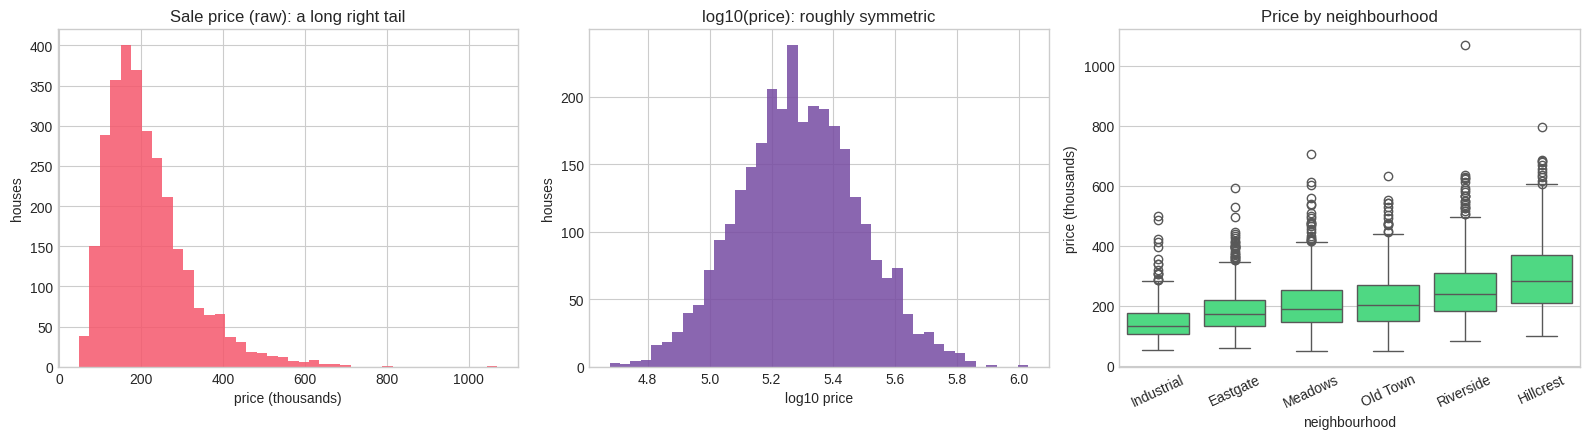

median price by neighbourhood (thousands): {'Industrial': 132.0, 'Eastgate': 173.0, 'Meadows': 189.0, 'Old Town': 201.0, 'Riverside': 241.0, 'Hillcrest': 281.0}


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].hist(houses["price"] / 1000, bins=40, color="#f5576c", alpha=0.85)
axes[0].set_title("Sale price (raw): a long right tail"); axes[0].set_xlabel("price (thousands)"); axes[0].set_ylabel("houses")
axes[1].hist(np.log10(houses["price"]), bins=40, color="#764ba2", alpha=0.85)
axes[1].set_title("log10(price): roughly symmetric"); axes[1].set_xlabel("log10 price"); axes[1].set_ylabel("houses")
order = houses.groupby("neighborhood")["price"].median().sort_values().index
sns.boxplot(data=houses.assign(price_k=houses.price / 1000), x="neighborhood", y="price_k", order=order, ax=axes[2], color="#38ef7d")
axes[2].set_title("Price by neighbourhood"); axes[2].set_xlabel("neighbourhood"); axes[2].set_ylabel("price (thousands)"); axes[2].tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()
print("median price by neighbourhood (thousands):", (houses.groupby("neighborhood")["price"].median().loc[order] / 1000).round(0).to_dict())


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the raw price has a long right tail; a few expensive houses stretch the axis and will dominate any squared-error metric. Middle: the same prices on a log axis are close to a bell. That is the signature of a *multiplicative* process: each effect scales the price by a percentage rather than adding a fixed amount. Right: the six neighbourhoods have clearly different medians and their boxes overlap, so location is a strong but not sufficient predictor.

The common misread: treating the tail as outliers to remove. The expensive houses are real listings and the portal must price them too; the fix is a metric and a transform that do not let them dominate, not deletion.

</div>

## 4.3 💻 Three lines

`eval_metric="mean_absolute_error"` asks for the model whose typical error in dollars is smallest, which is what "estimate ± X" needs. The alternative, RMSE (root mean squared error), squares each error before averaging, so it is pulled toward the expensive tail; it is the right choice only when large errors are disproportionately costly.


In [19]:
with timer("Part 3 fit"):
    pred_houses = TabularPredictor(label="price", eval_metric="mean_absolute_error", path=os.path.join(WORK, "part3"), verbosity=0).fit(
        train_h, time_limit=45, presets="medium_quality", num_cpus=N_CPUS)

print(f"problem type inferred: {pred_houses.problem_type} | eval metric: {pred_houses.eval_metric.name} | "
      f"models trained: {len(pred_houses.model_names())} | best on validation: {pred_houses.model_best}")


⏱️ Part 3 fit: 23.1 s
problem type inferred: regression | eval metric: mean_absolute_error | models trained: 10 | best on validation: WeightedEnsemble_L2


## 4.4 📤 The output

For regression `predict` returns one number per row in the label's units, and there is no `predict_proba`. The leaderboard's `score_test` is **minus** the MAE (higher is better, as always), so the cell adds an `MAE_test` column in plain dollars. `report_card(task="regression")` gives MAE, RMSE, the median absolute error, MAPE (mean absolute percentage error), R² and the bias (mean of actual minus predicted; zero means no systematic over- or under-pricing).


In [20]:
lb_houses = pred_houses.leaderboard(test_h)
lb_show = lb_houses[["model", "score_test", "score_val", "pred_time_test", "fit_time"]].set_index("model").copy()
lb_show.insert(0, "MAE_test", -lb_show["score_test"])
display(pretty(lb_show, fmt="{:,.2f}", subset=["score_test", "score_val"]))

pred_h = pred_houses.predict(test_h)
out_h = test_h[["sqft", "bedrooms", "neighborhood", "year_built"]].copy()
out_h["actual"] = test_h["price"].values; out_h["predicted"] = pred_h.round(-2).values
out_h["error"] = out_h["predicted"] - out_h["actual"]; out_h["error_%"] = (100 * out_h["error"] / out_h["actual"]).round(1)
print("predict(test) returns one number per house, in dollars -> five houses:")
display(out_h.head().style.format({"actual": "{:,.0f}", "predicted": "{:,.0f}", "error": "{:+,.0f}", "sqft": "{:,.0f}"}))

card_houses = report_card(test_h["price"], pred_h, name=f"price · {pred_houses.model_best}", task="regression")
display(pretty(card_houses, fmt="{:,.3f}", highlight=None))
print(f"typical error (MAE) = {card_houses.iloc[0]['MAE']:,.0f} on a median price of {test_h.price.median():,.0f} "
      f"({card_houses.iloc[0]['MAPE_%']:.1f}% MAPE); RMSE = {card_houses.iloc[0]['RMSE']:,.0f} is larger because it squares the big misses")


,MAE_test,score_test,score_val,pred_time_test,fit_time
model,,,,,
WeightedEnsemble_L2,"33,785.96","-33,785.96","-30,247.92",0.23,14.15
NeuralNetFastAI,"34,147.23","-34,147.23","-31,300.63",0.02,2.49
CatBoost,"34,269.88","-34,269.88","-31,771.87",0.01,2.47
NeuralNetTorch,"34,545.06","-34,545.06","-30,686.13",0.02,7.42
LightGBMXT,"34,922.13","-34,922.13","-31,388.60",0.04,0.81
XGBoost,"35,963.48","-35,963.48","-33,918.34",0.02,0.51
LightGBM,"36,083.06","-36,083.06","-33,151.90",0.01,0.73
LightGBMLarge,"37,411.74","-37,411.74","-33,857.65",0.04,1.84
ExtraTreesMSE,"38,755.02","-38,755.02","-36,532.19",0.14,1.42


predict(test) returns one number per house, in dollars -> five houses:


,sqft,bedrooms,neighborhood,year_built,actual,predicted,error,error_%
1801,"1,570",3,Eastgate,1976,"154,800","153,300","-1,500",-1.000000
1190,"2,040",3,Eastgate,1928,"254,100","219,200","-34,900",-13.700000
1817,"2,440",3,Eastgate,2017,"150,000","207,400","+57,400",38.300000
251,"2,290",4,Meadows,2018,"278,900","246,600","-32,300",-11.600000
2505,"2,020",4,Riverside,1935,"238,800","238,100",-700,-0.300000


,MAE,RMSE,MedAE,MAPE_%,R2,bias
model,,,,,,
price · WeightedEnsemble_L2,"33,785.957","47,248.785","25,166.438",15.821,0.797,"1,942.500"


typical error (MAE) = 33,786 on a median price of 190,650 (15.8% MAPE); RMSE = 47,249 is larger because it squares the big misses


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: report the error in the label's units and as a percentage

MAE in dollars is what the portal shows next to the estimate. MAPE says whether cheap and expensive houses are priced equally well in relative terms. RMSE larger than MAE (it always is, unless every error is identical) tells you how heavy the tail of big misses is. Read all three; they answer different questions.

</div>


## 4.5 📊 The picture

Three views of the same errors. Predicted against actual with the identity line: a perfect model sits on the line. Residuals against the prediction: a good model's residuals are a shapeless cloud around zero; a funnel means the error grows with the price. And the error split by neighbourhood, because "where is the model wrong" is the question the product team asks next.


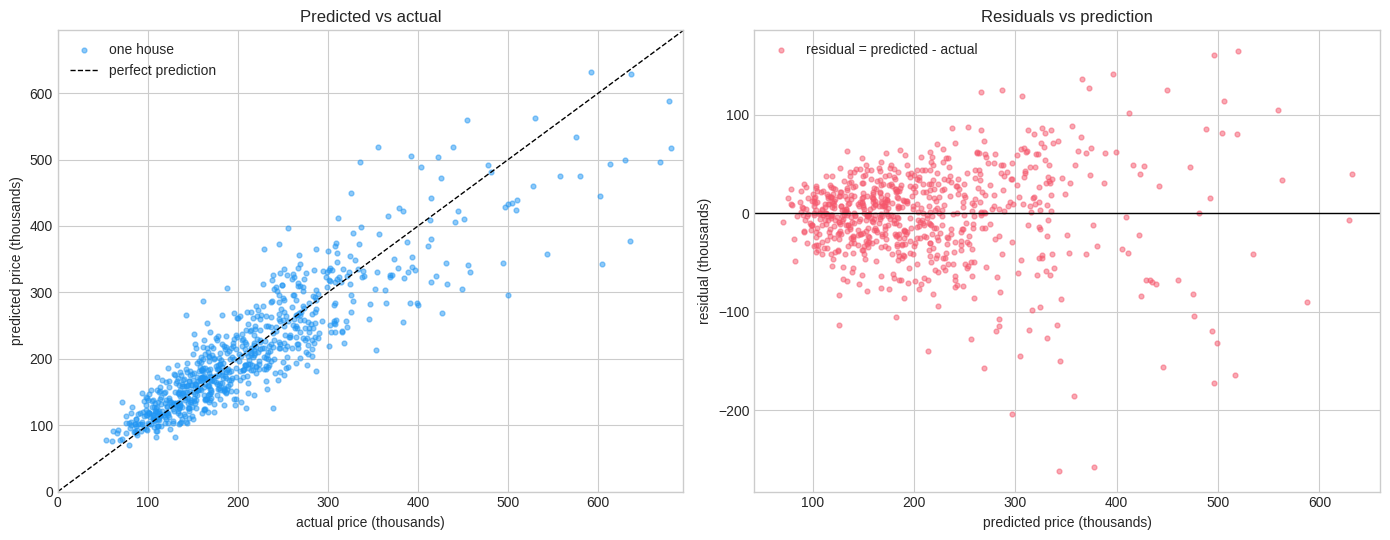

MAE on the cheapest quarter: 19,472 | on the dearest quarter: 57,008
MAPE on the cheapest quarter: 18.1% | on the dearest quarter: 15.4%


In [21]:
resid = out_h["error"].values
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(out_h["actual"] / 1000, out_h["predicted"] / 1000, s=12, alpha=0.5, color="#2196F3", label="one house")
lim = [0, max(out_h["actual"].max(), out_h["predicted"].max()) / 1000 * 1.02]
axes[0].plot(lim, lim, "k--", lw=1, label="perfect prediction"); axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel("actual price (thousands)"); axes[0].set_ylabel("predicted price (thousands)"); axes[0].set_title("Predicted vs actual"); axes[0].legend(loc="upper left")
axes[1].scatter(out_h["predicted"] / 1000, resid / 1000, s=12, alpha=0.5, color="#f5576c", label="residual = predicted - actual")
axes[1].axhline(0, color="k", lw=1); axes[1].set_xlabel("predicted price (thousands)"); axes[1].set_ylabel("residual (thousands)")
axes[1].set_title("Residuals vs prediction"); axes[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

cheap, dear = out_h["actual"] < out_h["actual"].quantile(0.25), out_h["actual"] > out_h["actual"].quantile(0.75)
print(f"MAE on the cheapest quarter: {np.abs(resid[cheap]).mean():,.0f} | on the dearest quarter: {np.abs(resid[dear]).mean():,.0f}")
print(f"MAPE on the cheapest quarter: {np.abs(out_h['error_%'][cheap]).mean():.1f}% | on the dearest quarter: {np.abs(out_h['error_%'][dear]).mean():.1f}%")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the cloud hugs the identity line, and it widens toward the top right: expensive houses are predicted with larger dollar errors. Right: the same fact as a funnel opening to the right. The printed MAEs on the cheapest and dearest quarters quantify it; the MAPEs show whether the relative error is closer to constant. A funnel of this shape is what a multiplicative process produces when the model works in raw dollars, and it is the motivation for the log transform in 4.6.

The common misread: a funnel does not mean the model is worse on expensive houses in any sense that matters to a buyer; a 5% miss on a large price is a large dollar miss. Decide which error the business cares about before choosing between MAE and MAPE.

</div>


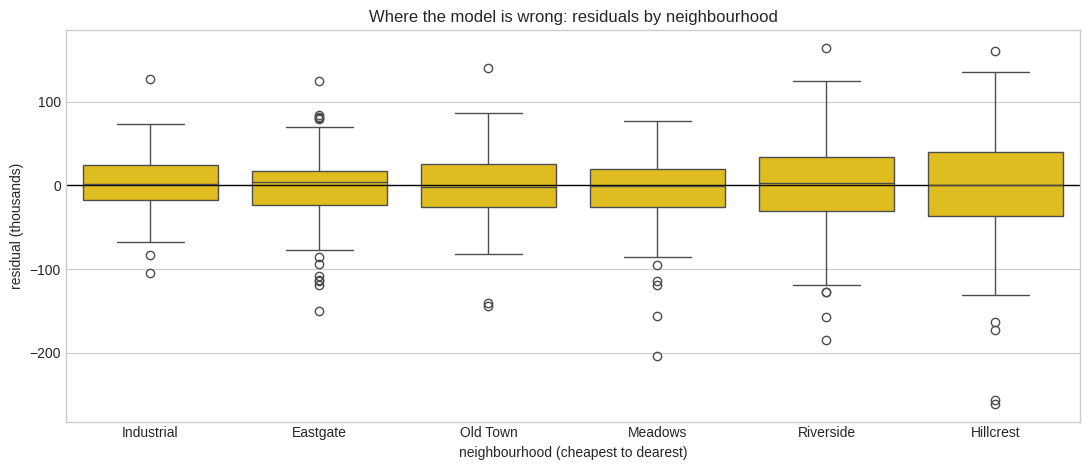

,n,MAE,bias,MAPE
neighborhood,,,,
Industrial,88.0,"25,287.5","3,612.5",18.7
Eastgate,182.0,"29,275.3","-2,319.2",15.5
Old Town,108.0,"32,020.4",-531.5,15.5
Meadows,178.0,"29,552.8","-5,820.2",14.0
Riverside,114.0,"41,420.2",528.9,16.7
Hillcrest,80.0,"54,318.8","-4,011.2",16.8


largest MAE: Hillcrest (54,319) | smallest: Industrial (25,288); the bias column shows whether a neighbourhood is systematically over- (+) or under-priced (-)


In [22]:
hood_order = out_h.groupby("neighborhood")["actual"].median().sort_values().index
fig, ax = plt.subplots(figsize=(11, 4.8))
sns.boxplot(data=out_h.assign(err_k=out_h.error / 1000), x="neighborhood", y="err_k", order=hood_order, color="#ffd200", ax=ax)
ax.axhline(0, color="k", lw=1); ax.set_xlabel("neighbourhood (cheapest to dearest)"); ax.set_ylabel("residual (thousands)")
ax.set_title("Where the model is wrong: residuals by neighbourhood"); plt.tight_layout(); plt.show()
by_hood = out_h.groupby("neighborhood").agg(n=("error", "size"), MAE=("error", lambda e: np.abs(e).mean()), bias=("error", "mean"),
                                            MAPE=("error_%", lambda e: np.abs(e).mean())).loc[hood_order]
display(pretty(by_hood, fmt="{:,.1f}", highlight=None))
print(f"largest MAE: {by_hood.MAE.idxmax()} ({by_hood.MAE.max():,.0f}) | smallest: {by_hood.MAE.idxmin()} ({by_hood.MAE.min():,.0f}); "
      f"the bias column shows whether a neighbourhood is systematically over- (+) or under-priced (-)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One box per neighbourhood, ordered from the cheapest to the dearest median. The boxes are centred near zero (the bias column in the table says how near), which means the model learned the neighbourhood base prices; their width grows toward the dearer end, the funnel again. A box floating clearly above or below zero would be a segment the model systematically misprices, and the first place to look for a missing feature.

The common misread: comparing the boxes' widths as if the neighbourhoods were equally hard. The dearer neighbourhoods have larger dollar errors because their prices are larger; the MAPE column is the fair comparison.

</div>

## 4.6 One extra fit: predict the log of the price

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: turn a multiplicative problem into an additive one

The histogram showed that log(price) is roughly symmetric. Training on `log1p(price)` and converting the prediction back with `expm1` makes every effect additive in the log domain (a neighbourhood adds a constant, not a percentage), which tree models find easier, and it stops the expensive tail from dominating the loss. The cost is a subtle bias: the mean of exp(x) is larger than exp(mean of x), so back-transformed predictions tend to sit slightly low. The `bias` column in the report card measures exactly that.

</div>


In [23]:
train_log = train_h.drop(columns="price").assign(log_price=np.log1p(train_h["price"]))
with timer("Part 3 fit on log1p(price)"):
    pred_log = TabularPredictor(label="log_price", eval_metric="mean_absolute_error", path=os.path.join(WORK, "part3_log"), verbosity=0).fit(
        train_log, time_limit=30, presets="medium_quality", num_cpus=N_CPUS)
pred_h_log = np.expm1(pred_log.predict(test_h.drop(columns="price")))        # back to dollars

card_log = report_card(test_h["price"], pred_h_log, name=f"log1p(price) · {pred_log.model_best}", task="regression")
cards_houses = pd.concat([card_houses, card_log])
display(pretty(cards_houses, fmt="{:,.3f}", highlight=None))
winner = cards_houses["MAE"].idxmin(); delta = cards_houses["MAE"].max() - cards_houses["MAE"].min()
print(f"lower MAE: {winner} by {delta:,.0f} dollars ({delta / cards_houses['MAE'].max():.1%}); "
      f"bias raw {card_houses.iloc[0]['bias']:+,.0f} vs log {card_log.iloc[0]['bias']:+,.0f} (positive = predictions sit below the actuals on average)")


⏱️ Part 3 fit on log1p(price): 30.7 s


,MAE,RMSE,MedAE,MAPE_%,R2,bias
model,,,,,,
price · WeightedEnsemble_L2,"33,785.957","47,248.785","25,166.438",15.821,0.797,"1,942.500"
log1p(price) · WeightedEnsemble_L2,"33,535.143","46,778.158","24,330.406",15.740,0.801,"2,787.539"


lower MAE: log1p(price) · WeightedEnsemble_L2 by 251 dollars (0.7%); bias raw +1,943 vs log +2,788 (positive = predictions sit below the actuals on average)


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Score the transformed model in the original units

The log model was trained to minimise MAE *in log space*, which is close to a relative error. Its leaderboard scores are therefore not comparable with the raw model's. The only fair comparison is the one above: both sets of predictions converted to dollars and scored by the same `report_card`. The printed line names the winner in this run and the size of the gap; on a short budget the two are often close. The log model's `bias` (actual minus predicted) is usually the larger positive number of the two: its predictions sit lower, the retransformation effect described above. Whether the log transform wins depends on how skewed the target is and on the metric the business cares about: it tends to help MAPE more than MAE.

</div>

## 4.7 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

**Reach for regression** whenever the target is a number and a single point estimate is enough: prices, durations, demand, scores. If the business needs a *range* rather than a point ("between X and Y"), that is quantile regression, Part 4.

**What it costs:** the same as classification; the leaderboard's default metric is RMSE, so pass `mean_absolute_error` when a typical error is wanted and the tail should not dominate.

**The one gotcha:** a skewed target. Look at the histogram first; if the log looks like a bell, try `log1p` on the label and score in the original units. And remember that MAE, RMSE and MAPE rank models differently, so pick the metric before the fit.

</div>


## 4.8 Task 4 Summary

**✅ Key Takeaways**
- A numeric label with many values makes AutoGluon infer `regression`; `predict` returns a number per row and there is no `predict_proba`.
- Leaderboard scores are negated MAE; `report_card(task="regression")` reports MAE, RMSE, MedAE, MAPE, R² and bias in the label's units.
- Predicted-vs-actual and residual plots show a funnel: dollar errors grow with price because the process is multiplicative.
- Residuals by segment show where the model is wrong; a box off zero is a mispriced segment.
- Predicting `log1p(price)` and scoring in dollars is the standard trick for a skewed target; the fair comparison is in the original units.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `make_houses`, `houses`, `train_h`, `test_h` | the generator, the table, the split |
| `pred_houses`, `lb_houses`, `lb_show` | the fitted predictor, its leaderboard, and the leaderboard with MAE in dollars |
| `pred_h`, `out_h`, `resid`, `by_hood` | predictions, the per-house table with errors, the residuals, and the per-neighbourhood error table |
| `card_houses`, `pred_log`, `pred_h_log`, `card_log`, `cards_houses` | the raw report card, the log-target predictor, its dollar predictions and card, and the two-row comparison |

**➡️ Next Up:** Part 4 — not a point but a window: quantile regression for delivery-time promises.


# Part 4 · Quantile Regression · Delivery-Time Windows ⭐⭐

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### A number is a promise you cannot keep

Part 3 predicted one number per house. A courier app cannot show one number: "arrives in 42 minutes" is wrong almost every time, and customers remember the misses. What the app needs is a **window** ("between 35 and 55 minutes") that is right about eight times in ten and as narrow as the data allows. That is **quantile regression**: instead of the mean, the model learns the 10th, 50th and 90th percentiles of the target for every row. `TabularPredictor` does it with two extra arguments.

</div>


# Task 5 · Delivery windows with `problem_type="quantile"`

## 5.1 ❓ The problem

A food-delivery operations lead asks: *"For each order, what window should the app promise so that four in five deliveries land inside it, and how much wider must the window be in the rain?"* A good answer changes the promise shown to the customer, the refund policy (a refund is paid when the delivery lands outside the window), and how many couriers are scheduled on rainy evenings.

## 5.2 📥 The input

One row per completed delivery. The label is `delivery_minutes`. The generator plants a **heteroscedastic** target: the noise, and so the honest window, grows with distance and with bad weather. A mean-only model cannot see that; a quantile model has to.


In [24]:
def make_deliveries(n=3000, seed=RANDOM_STATE):
    # Completed deliveries. Delivery time grows with distance, rush hour, weather and zone; its SPREAD grows with distance and weather.
    rng = np.random.default_rng(seed)
    distance = rng.gamma(2.0, 4.0, n).clip(0.5, 35).round(1)
    weight = rng.lognormal(0.8, 0.7, n).clip(0.1, 25).round(2)
    hour = rng.integers(7, 23, n)
    weekday = rng.choice(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], n)
    weather = rng.choice(["clear", "cloudy", "rain", "snow"], n, p=[0.55, 0.25, 0.15, 0.05])
    experience = rng.gamma(2.0, 1.5, n).clip(0, 15).round(1)
    zone = rng.choice(["downtown", "suburb", "industrial", "rural"], n, p=[0.35, 0.40, 0.15, 0.10])
    rush = np.isin(hour, [8, 9, 12, 13, 17, 18, 19]).astype(float)
    centre = (8 + 2.0 * distance + 0.25 * weight + 6 * rush + 4 * (weather == "rain") + 12 * (weather == "snow")
              + 5 * (zone == "downtown") + 3 * (zone == "rural") - 0.6 * experience)
    spread = 2 + 0.35 * distance + 5 * (weather == "rain") + 8 * (weather == "snow") + 2 * rush   # the noise scale: NOT constant
    minutes = np.clip(centre + rng.normal(0, 1, n) * spread, 5, None).round(1)
    return pd.DataFrame({"distance_km": distance, "package_weight_kg": weight, "hour_of_day": hour, "weekday": weekday,
                         "weather": weather, "courier_experience_years": experience, "zone": zone, "delivery_minutes": minutes})

DL_LABEL = "delivery_minutes"
dl_df = make_deliveries(3000)
show_input(dl_df, label=DL_LABEL, name="deliveries")
dl_train, dl_test = train_test_split(dl_df, test_size=0.2, random_state=RANDOM_STATE)
print(f"train {len(dl_train):,} rows | test {len(dl_test):,} rows")


📥 deliveries: 3,000 rows x 8 columns | label = 'delivery_minutes'


,distance_km,package_weight_kg,hour_of_day,weekday,weather,courier_experience_years,zone,delivery_minutes
0,8.4,0.87,12,Wed,cloudy,4.5,industrial,24.3
1,11.3,3.16,12,Wed,clear,1.5,suburb,54.4
2,7.3,2.37,10,Sun,snow,0.3,rural,30.0
3,6.6,1.42,17,Wed,cloudy,0.6,rural,31.7
4,12.3,4.05,8,Mon,cloudy,3.2,suburb,42.4


column types: {'distance_km': 'numeric', 'package_weight_kg': 'numeric', 'hour_of_day': 'numeric', 'weekday': 'text/category', 'weather': 'text/category', 'courier_experience_years': 'numeric', 'zone': 'text/category', 'delivery_minutes': 'numeric'}
label range: 5 .. 106, mean 29
train 2,400 rows | test 600 rows


| Column | Type | Meaning |
|---|---|---|
| `distance_km` | numeric | road distance from restaurant to customer |
| `package_weight_kg` | numeric | order weight |
| `hour_of_day` | numeric | hour the order was placed (7-22) |
| `weekday` | category | day name |
| `weather` | category | clear / cloudy / rain / snow at pickup |
| `courier_experience_years` | numeric | years the courier has worked |
| `zone` | category | delivery zone |
| `delivery_minutes` | numeric label | minutes from order to hand-over |

AutoGluon reads the numeric columns as numbers and `weekday`, `weather`, `zone` as categories (it one-hot or label-encodes them per model). `hour_of_day` stays numeric, which lets tree models find the rush-hour bands on their own.


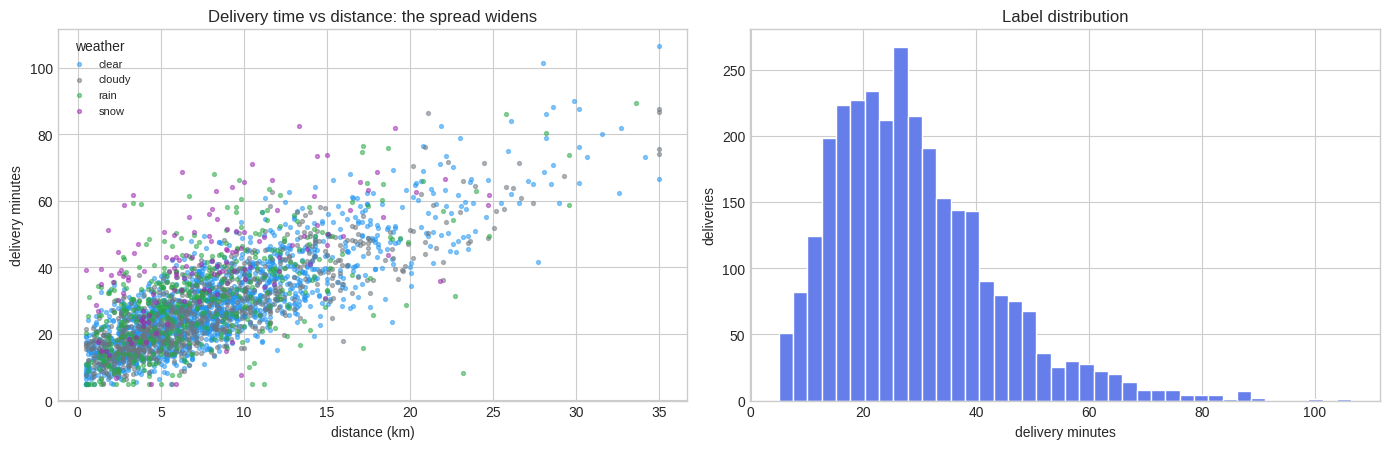

         mean   std  count
weather                   
clear    28.3  13.9   1618
cloudy   27.2  13.2    798
rain     30.8  14.9    451
snow     41.4  15.8    133


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
colors = {"clear": "#2196F3", "cloudy": "#6c757d", "rain": "#28a745", "snow": "#9c27b0"}
for w, c in colors.items():
    sub = dl_df[dl_df.weather == w]
    axes[0].scatter(sub.distance_km, sub[DL_LABEL], s=8, alpha=0.5, color=c, label=w)
axes[0].set_xlabel("distance (km)"); axes[0].set_ylabel("delivery minutes"); axes[0].set_title("Delivery time vs distance: the spread widens"); axes[0].legend(title="weather", fontsize=8)
axes[1].hist(dl_df[DL_LABEL], bins=40, color="#667eea", edgecolor="white"); axes[1].set_xlabel("delivery minutes"); axes[1].set_ylabel("deliveries"); axes[1].set_title("Label distribution")
plt.tight_layout(); plt.show()
spread_by_w = dl_df.groupby("weather")[DL_LABEL].agg(["mean", "std", "count"]).round(1)
print(spread_by_w.to_string())


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: every delivery as a dot, distance on the x-axis, minutes on the y-axis, coloured by weather. The cloud is a wedge, not a band: short trips are tight, long trips are loose, and the green (rain) and purple (snow) dots sit higher and scatter wider than the blue ones at the same distance. Right: the label itself is right-skewed, with a long tail of slow deliveries. The table under the plot puts numbers on the wedge: the standard deviation by weather is the width a window would need in each condition.

The common misread: seeing the wedge and reaching for a log transform. A log transform helps a *mean* model with a skewed target; it does not tell you the width of the window for one specific order. Quantiles do.

</div>

## 5.3 💻 Three lines

Two arguments change against Part 3: `problem_type="quantile"` and `quantile_levels=[0.1, 0.5, 0.9]`. AutoGluon then trains only the models that can output quantiles (gradient boosting with a quantile objective, random forests, extra trees, the two neural networks) and scores them with the **pinball loss**, explained under the output.


In [26]:
DL_Q = [0.1, 0.5, 0.9]                                     # the quantile levels: a 10th, a median and a 90th percentile per row
with timer("TabularPredictor.fit (quantile)"):
    dl_pred = TabularPredictor(label=DL_LABEL, problem_type="quantile", quantile_levels=DL_Q,
                               path=os.path.join(WORK, "part4"), verbosity=0).fit(
        dl_train, time_limit=45, presets="medium_quality", num_cpus=N_CPUS)
dl_lb = dl_pred.leaderboard(dl_test)
dl_q = dl_pred.predict(dl_test)                            # a DataFrame: one column per quantile level
print(f"problem type inferred: {dl_pred.problem_type} | eval metric: {dl_pred.eval_metric} (higher is better in the leaderboard, so it is shown negative)")
print(f"predict() returns a {type(dl_q).__name__} with columns {list(dl_q.columns)}; models trained: {len(dl_lb)}")


⏱️ TabularPredictor.fit (quantile): 30.2 s
problem type inferred: quantile | eval metric: pinball_loss (higher is better in the leaderboard, so it is shown negative)
predict() returns a DataFrame with columns [0.1, 0.5, 0.9]; models trained: 9


## 5.4 📤 The output

The leaderboard scores each model by pinball loss on the test set (sign flipped, so the least negative row is best). `predict` returns a DataFrame with one column per quantile level instead of a Series; the cell below places the actual delivery time next to those three columns and checks the promise: does the 10-90 window contain the truth about 80% of the time?


In [27]:
pretty(dl_lb.set_index("model")[["score_test", "score_val", "fit_time", "pred_time_test"]], subset=["score_test", "score_val"])


,score_test,score_val,fit_time,pred_time_test
model,,,,
CatBoost,-1.867,-1.896,4.830,0.014
WeightedEnsemble_L2,-1.876,-1.879,16.331,0.680
LightGBM,-1.930,-1.937,1.774,0.079
LightGBMXT,-1.950,-1.930,1.843,0.115
NeuralNetFastAI,-2.031,-2.048,2.905,0.440
LightGBMLarge,-2.062,-2.116,3.777,0.147
NeuralNetTorch,-2.067,-2.070,6.051,0.019
ExtraTreesMSE,-2.073,-2.052,1.767,0.447
RandomForestMSE,-2.081,-2.046,3.564,0.528


In [28]:
dl_out = dl_test[["distance_km", "weather", "zone", DL_LABEL]].copy()
dl_out[["q10", "q50", "q90"]] = dl_q.values.astype(float)
dl_out["width"] = dl_out.q90 - dl_out.q10
dl_out["inside"] = (dl_out[DL_LABEL] >= dl_out.q10) & (dl_out[DL_LABEL] <= dl_out.q90)
print("the prediction frame next to the truth (first 8 test rows):")
display(dl_out.head(8).round(1))
cover = dl_out.inside.mean(); below = (dl_out[DL_LABEL] < dl_out.q10).mean(); above = (dl_out[DL_LABEL] > dl_out.q90).mean()
crossed = int(((dl_out.q10 > dl_out.q50) | (dl_out.q50 > dl_out.q90)).sum())
print(f"\n80% window coverage on test: {cover:.1%} (target 80%) | below q10: {below:.1%} (target 10%) | above q90: {above:.1%} (target 10%)")
print(f"rows whose quantiles cross (q10 > q50 or q50 > q90): {crossed} of {len(dl_out)}")


the prediction frame next to the truth (first 8 test rows):


,distance_km,weather,zone,delivery_minutes,q10,q50,q90,width,inside
1801,14.9,clear,rural,39.7,32.3,45.7,55.4,23.2,True
1190,8.3,snow,rural,63.1,29.0,39.5,52.8,23.8,False
1817,8.4,rain,industrial,29.8,20.7,34.1,44.8,24.1,True
251,1.0,clear,downtown,16.4,11.1,15.3,20.0,8.9,True
2505,6.4,clear,suburb,23.8,17.2,22.0,28.3,11.1,True
1117,8.5,cloudy,industrial,30.0,20.3,26.0,33.1,12.8,True
1411,3.9,cloudy,suburb,18.2,11.2,15.5,20.9,9.7,True
2113,1.1,rain,suburb,19.7,5.9,13.3,25.5,19.6,True



80% window coverage on test: 75.5% (target 80%) | below q10: 11.0% (target 10%) | above q90: 13.5% (target 10%)
rows whose quantiles cross (q10 > q50 or q50 > q90): 0 of 600


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently): the pinball loss

A quantile forecast $f^q$ is scored by charging $q$ per minute when the truth $y$ lands **above** it and $1-q$ per minute when it lands **below**:

$$ \rho_q(y, f^q) = \begin{cases} q\,(y - f^q) & y \ge f^q \\ (1-q)\,(f^q - y) & y < f^q \end{cases} $$

For $q = 0.9$ an under-prediction costs nine times more than an over-prediction, so the value that minimises the average charge is the true 90th percentile. That asymmetry is the whole trick: the same loss with $q = 0.5$ is half the absolute error, which is why the median column is also the best point forecast under MAE. AutoGluon's `pinball_loss` is the average of $\rho_q$ over rows, then over the three levels. The cell below computes it by hand and checks it against `evaluate`.

</div>


In [29]:
def pinball(y, f, q):
    d = y - f
    return np.where(d >= 0, q * d, (q - 1) * d)

pin_by_q = pd.Series({f"q{int(q*100)}": pinball(dl_out[DL_LABEL].values, dl_out[f"q{int(q*100)}"].values, q).mean() for q in DL_Q}, name="mean pinball (minutes)")
ag_pin = -dl_pred.evaluate(dl_test)["pinball_loss"]
print(pin_by_q.round(3).to_string())
print(f"\nmean over the three levels, by hand: {pin_by_q.mean():.4f} | AutoGluon evaluate(): {ag_pin:.4f} | diff {abs(pin_by_q.mean() - ag_pin):.1e}")
by_weather = dl_out.groupby("weather").agg(deliveries=("inside", "size"), coverage=("inside", "mean"), mean_width=("width", "mean"),
                                           median_width=("width", "median")).sort_values("mean_width")
print("\nwindow width and coverage by weather:")
pretty(by_weather, fmt={"deliveries": "{:d}", "coverage": "{:.1%}", "mean_width": "{:.1f}", "median_width": "{:.1f}"}, highlight=None)


q10    1.207
q50    2.933
q90    1.487

mean over the three levels, by hand: 1.8755 | AutoGluon evaluate(): 1.8755 | diff 2.2e-16

window width and coverage by weather:


,deliveries,coverage,mean_width,median_width
weather,,,,
clear,333,76.6%,14.7,14.0
cloudy,157,78.3%,15.4,15.0
rain,97,68.0%,22.7,22.4
snow,13,69.2%,27.7,27.5


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ A 45-second fit ships a window that is a little too narrow

Read the coverage line above against its targets. On this run the window holds the truth less often than the promised 80%, and the two tail numbers say where: the "above q90" share is the larger one, so the model under-predicts the slow tail more than the fast one. That is typical of a short fit on a skewed target and it has two cheap fixes: widen the requested levels (`quantile_levels=[0.05, 0.5, 0.95]`) or **scale the band** by the factor that makes coverage hit 80% on a validation split (a conformal correction). Never fix it by eye on the test set. The by-weather table is the second check: the rain and snow rows have lower coverage than the clear row even though their windows are wider, so the correction should be computed per weather, not once. Finally the crossing count: independently trained quantiles can **cross** (a q10 above the q50); when that count is not zero, sort the three columns per row with `np.sort(dl_q.values, axis=1)` before showing a window to anyone.

</div>

## 5.5 📊 The picture


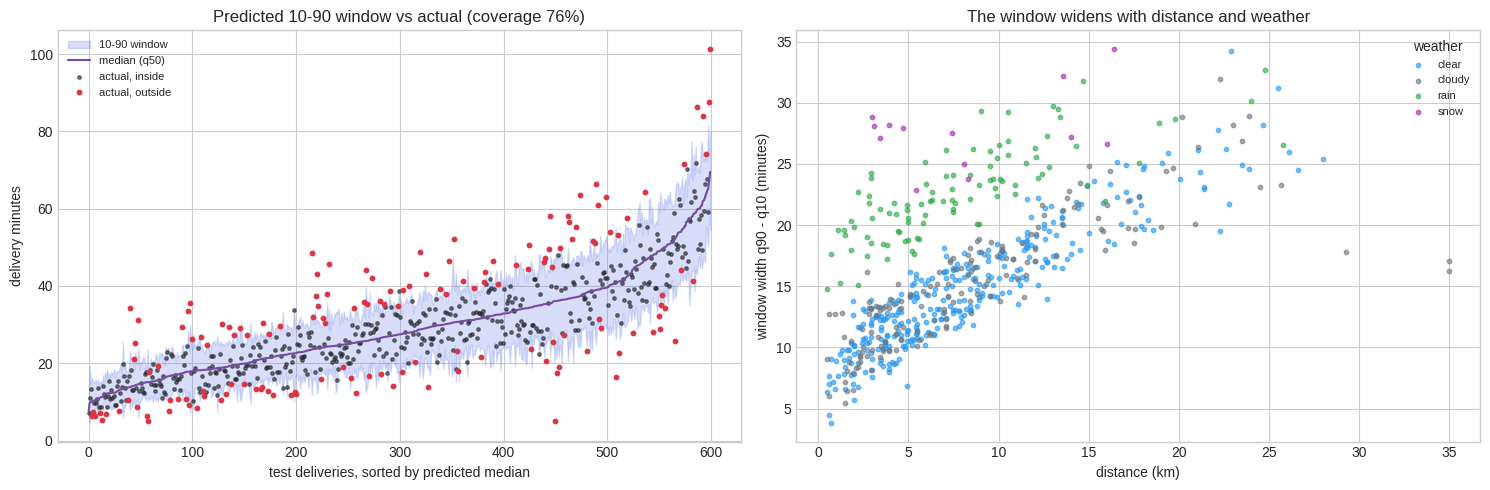

correlation between distance and window width on test: 0.68 | narrowest window 3.8 min, widest 34.4 min


In [30]:
srt = dl_out.sort_values("q50").reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.fill_between(srt.index, srt.q10, srt.q90, color="#667eea", alpha=0.25, label="10-90 window")
ax.plot(srt.index, srt.q50, color="#764ba2", lw=1.5, label="median (q50)")
ax.scatter(srt.index[srt.inside], srt[DL_LABEL][srt.inside], s=6, color="#212529", alpha=0.6, label="actual, inside")
ax.scatter(srt.index[~srt.inside], srt[DL_LABEL][~srt.inside], s=10, color="#dc3545", label="actual, outside")
ax.set_xlabel("test deliveries, sorted by predicted median"); ax.set_ylabel("delivery minutes")
ax.set_title(f"Predicted 10-90 window vs actual (coverage {cover:.0%})"); ax.legend(loc="upper left", fontsize=8)
ax = axes[1]
for w, c in colors.items():
    sub = dl_out[dl_out.weather == w]
    ax.scatter(sub.distance_km, sub.width, s=10, alpha=0.6, color=c, label=w)
ax.set_xlabel("distance (km)"); ax.set_ylabel("window width q90 - q10 (minutes)"); ax.set_title("The window widens with distance and weather"); ax.legend(title="weather", fontsize=8)
plt.tight_layout(); plt.show()
corr = np.corrcoef(dl_out.distance_km, dl_out.width)[0, 1]
print(f"correlation between distance and window width on test: {corr:.2f} | narrowest window {dl_out.width.min():.1f} min, widest {dl_out.width.max():.1f} min")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the test deliveries lined up from the fastest predicted median to the slowest. The shaded band is the promise; the purple line is the median; black dots are actuals that landed inside the band and red dots the ones that did not. Two things to look for: the band **widens to the right** (slow deliveries are also uncertain deliveries, exactly what the generator planted), and on which side of the band the red dots sit. Red dots above the band are late deliveries the promise missed; the tail numbers in 5.4 say that side is the weaker one, so the red dots should be more often above than below. Right: the width of each order's window against its distance, coloured by weather. Rain and snow orders sit above clear ones at every distance; the correlation printed under the plot is the model rediscovering the wedge from 5.2.

The common misread: judging the model by how close the purple line is to the dots. The median is *supposed* to have half the actuals above it and half below. The score of a quantile model is coverage and width, not the hit rate of the middle line.

</div>

## 5.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Reach for `problem_type="quantile"` when the answer is a range

- **Promises and SLAs**: delivery windows, ticket resolution times, "your loan decision within N days".
- **Safety stock and capacity**: the 90th percentile of demand is what you stock; the median is what you expect to sell.
- **Risk-aware pricing**: the 10th percentile of a resale value is the number a lender can safely advance.

**Cost**: one fit gives all three levels, so it is no slower than Part 3; the leaderboard has fewer models because only quantile-capable ones are trained. **The one gotcha**: coverage must be checked on held-out data **and per segment**; a window that is calibrated on average but too narrow in the rain is the window that generates refunds.

### 🏆 Best practice: promise the window, price the tails

Ship `q10`-`q90` as the customer-facing window, but log the per-tail miss rates by segment every week. When "above q90" drifts past its target for one zone, the fix is usually data (a new restaurant, a road closure), not the model.

</div>

## 5.7 Task 5 Summary

**✅ Key Takeaways**
- `problem_type="quantile"` plus `quantile_levels` turns a regression into a window predictor; `predict` returns one column per level.
- The **pinball loss** is asymmetric on purpose: it makes each column converge to its own percentile. The by-hand value matched `evaluate()` to numerical precision.
- **Coverage** is the calibration check (target 80% for a 10-90 window), and it must hold per tail and per segment. This run came in under target on the slow tail; the fix is a validation-set correction, not a test-set tweak.
- The window width is itself a prediction: it widened with distance and weather without being told to.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `make_deliveries`, `dl_df`, `dl_train`, `dl_test` | the delivery dataset and its split |
| `dl_pred`, `dl_lb`, `dl_q` | the quantile predictor, its leaderboard, the three-column prediction frame |
| `dl_out`, `by_weather`, `pin_by_q` | predictions next to the truth with width and coverage, the by-weather table, pinball loss per level |

**➡️ Next Up:** Part 5 — when the event you care about is 1.5% of the rows, the metric and the threshold matter more than the model.


# Part 5 · Rare Events · Card Fraud with Cost-Aware Thresholds ⭐⭐

<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### When 98.5% accuracy is worthless

In a card-fraud table, about one and a half rows in a hundred are fraud. A model that says "legit" to everything is 98.5% accurate and catches nothing. Part 5 is about the two decisions that matter more than the model on a problem like this: **which metric** to optimise (one that only looks at the rare class) and **where to put the threshold** (a fraud team can review only so many transactions, and a missed fraud costs the amount, not a fixed penalty).

</div>


# Task 6 · Fraud with `eval_metric="average_precision"` and a cost curve

## 6.1 ❓ The problem

A payments fraud lead asks: *"Which transactions should the review team look at first, and how many should they look at?"* Every flagged transaction costs a review (say five units of analyst time). Every missed fraud costs the transaction amount. A good answer ranks transactions by risk and picks the cut-off that minimises review cost plus lost amount, not the one that maximises a textbook score.

## 6.2 📥 The input

One row per card transaction, label `is_fraud`. The generator plants the usual signals: large amounts, night-time, foreign transactions, a new device, a burst of transactions in the last hour, and risky merchant categories. Fraud is about 1.5% of rows, so the split is stratified and three slices are cut: a **train** set for AutoGluon, a **calibration** set the threshold is chosen on, and a **test** set nobody touches until the end.


In [31]:
def make_fraud(n=20000, seed=RANDOM_STATE):
    # Card transactions with ~1.5% fraud. Risk grows with amount, night hours, foreign use, a new device, bursts and risky merchants.
    rng = np.random.default_rng(seed)
    amount = rng.lognormal(3.4, 1.0, n).round(2)
    hour = rng.integers(0, 24, n)
    merchant = rng.choice(["grocery", "fuel", "restaurant", "electronics", "online_retail", "travel", "gambling"], n,
                          p=[0.28, 0.16, 0.20, 0.10, 0.14, 0.07, 0.05])
    distance = rng.exponential(12, n).round(1)
    is_foreign = rng.random(n) < 0.05
    n_txn = rng.poisson(0.5, n)
    device_new = rng.random(n) < 0.08
    night = hour <= 5
    risky = np.isin(merchant, ["electronics", "online_retail", "gambling"])
    logit = (-12.5 + 1.1 * np.log(amount) + 2.8 * is_foreign + 2.6 * device_new + 1.3 * n_txn
             + 0.035 * np.minimum(distance, 100) + 1.9 * night + 1.5 * risky + 2.0 * (is_foreign & device_new))
    is_fraud = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
    return pd.DataFrame({"amount": amount, "hour": hour, "merchant_category": merchant, "distance_from_home_km": distance,
                         "is_foreign": is_foreign, "num_txn_last_hour": n_txn, "device_new": device_new, "is_fraud": is_fraud})

FR_LABEL = "is_fraud"
fr_df = make_fraud(20000)
show_input(fr_df, label=FR_LABEL, name="card transactions")
fr_train, fr_rest = train_test_split(fr_df, test_size=0.30, stratify=fr_df[FR_LABEL], random_state=RANDOM_STATE)
fr_calib, fr_test = train_test_split(fr_rest, test_size=0.50, stratify=fr_rest[FR_LABEL], random_state=RANDOM_STATE)
print(f"train {len(fr_train):,} rows ({fr_train[FR_LABEL].sum()} fraud) | calibration {len(fr_calib):,} ({fr_calib[FR_LABEL].sum()} fraud) | test {len(fr_test):,} ({fr_test[FR_LABEL].sum()} fraud)")


📥 card transactions: 20,000 rows x 8 columns | label = 'is_fraud'


,amount,hour,merchant_category,distance_from_home_km,is_foreign,num_txn_last_hour,device_new,is_fraud
0,40.64,8,travel,16.5,False,0,True,0
1,10.59,8,gambling,2.3,False,2,False,0
2,63.46,0,restaurant,6.9,False,0,False,0
3,76.75,22,restaurant,41.7,False,2,False,0
4,4.26,20,fuel,6.6,False,1,False,0


column types: {'amount': 'numeric', 'hour': 'numeric', 'merchant_category': 'text/category', 'distance_from_home_km': 'numeric', 'is_foreign': 'boolean', 'num_txn_last_hour': 'numeric', 'device_new': 'boolean', 'is_fraud': 'numeric'}
label distribution: {0: 0.985, 1: 0.015}
train 14,000 rows (209 fraud) | calibration 3,000 (45 fraud) | test 3,000 (45 fraud)


| Column | Type | Meaning |
|---|---|---|
| `amount` | numeric | transaction amount |
| `hour` | numeric | hour of day (0-23) |
| `merchant_category` | category | grocery, fuel, restaurant, electronics, online retail, travel, gambling |
| `distance_from_home_km` | numeric | distance between the merchant and the cardholder's home |
| `is_foreign` | boolean | card used outside its home country |
| `num_txn_last_hour` | numeric | other transactions on the card in the previous hour |
| `device_new` | boolean | first transaction from this device |
| `is_fraud` | binary label | 1 = confirmed fraud |

AutoGluon infers `binary` from the two-valued label and keeps the booleans as 0/1 features. Nothing about the imbalance is declared; the metric choice below is what makes the fit care about the rare class.


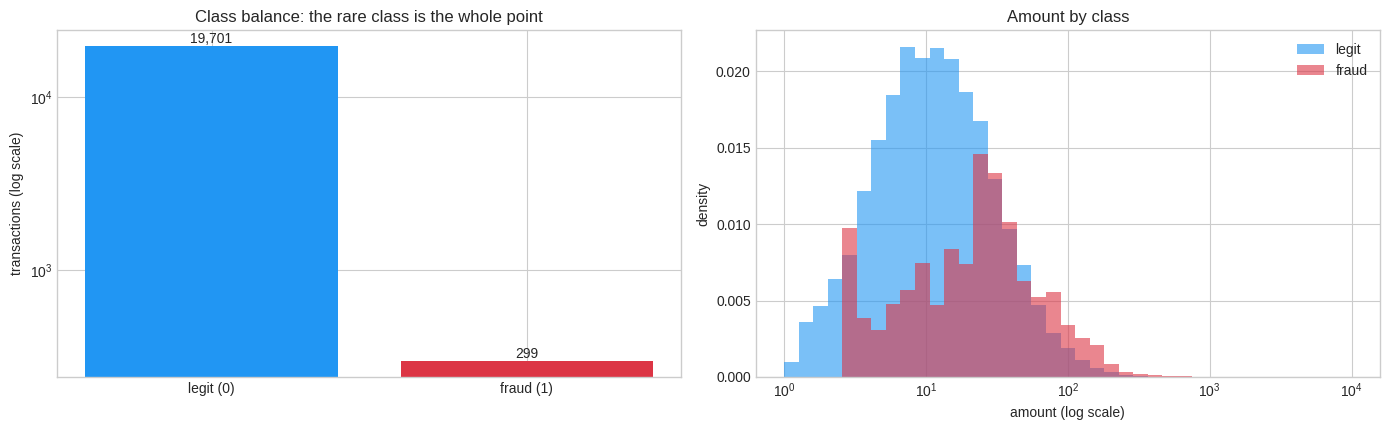

fraud prevalence: 1.49% | accuracy of a model that always says 'legit': 98.50% | mean amount: legit 49, fraud 96


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
counts = fr_df[FR_LABEL].value_counts()
axes[0].bar(["legit (0)", "fraud (1)"], counts.values, color=["#2196F3", "#dc3545"]); axes[0].set_yscale("log")
for i, v in enumerate(counts.values): axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")
axes[0].set_ylabel("transactions (log scale)"); axes[0].set_title("Class balance: the rare class is the whole point")
bins = np.logspace(0, 4, 40)
axes[1].hist(fr_df.loc[fr_df[FR_LABEL] == 0, "amount"], bins=bins, alpha=0.6, color="#2196F3", label="legit", density=True)
axes[1].hist(fr_df.loc[fr_df[FR_LABEL] == 1, "amount"], bins=bins, alpha=0.6, color="#dc3545", label="fraud", density=True)
axes[1].set_xscale("log"); axes[1].set_xlabel("amount (log scale)"); axes[1].set_ylabel("density"); axes[1].set_title("Amount by class"); axes[1].legend()
plt.tight_layout(); plt.show()
prev = fr_df[FR_LABEL].mean()
always_legit_acc = 1 - prev
print(f"fraud prevalence: {prev:.2%} | accuracy of a model that always says 'legit': {always_legit_acc:.2%} | mean amount: legit {fr_df.loc[fr_df[FR_LABEL]==0,'amount'].mean():.0f}, fraud {fr_df.loc[fr_df[FR_LABEL]==1,'amount'].mean():.0f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the two classes on a log scale, because on a linear scale the fraud bar would be invisible. Right: the amount distributions overlap almost completely; fraud leans larger, but no single amount separates the classes, which is why the model needs all seven columns. The line under the plot is the number to remember: a model that never flags anything already scores the accuracy printed there. Accuracy cannot be the metric.

The common misread: assuming the rare class must be oversampled or reweighted before AutoGluon can learn it. Gradient-boosted trees rank rare positives well from the raw table; the problem is not learning but *scoring* and *thresholding*.

</div>

## 6.3 💻 Three lines

`eval_metric="average_precision"` is the area under the precision-recall curve, which ignores the true negatives entirely: a model gets credit only for putting frauds above legit transactions in its ranking. AutoGluon uses it for validation, model selection and ensemble weights.


In [33]:
with timer("TabularPredictor.fit (fraud)"):
    fr_pred = TabularPredictor(label=FR_LABEL, eval_metric="average_precision", path=os.path.join(WORK, "part5"), verbosity=0).fit(
        fr_train, time_limit=60, presets="medium_quality", num_cpus=N_CPUS)
fr_lb = fr_pred.leaderboard(fr_test)
fr_prob_test = fr_pred.predict_proba(fr_test)[1].values
fr_prob_calib = fr_pred.predict_proba(fr_calib)[1].values
print(f"problem type inferred: {fr_pred.problem_type} | eval metric: {fr_pred.eval_metric} | positive class: {fr_pred.positive_class} | default decision threshold: {fr_pred.decision_threshold}")
print(f"models trained: {len(fr_lb)} | best on validation: {fr_pred.model_best}")


⏱️ TabularPredictor.fit (fraud): 62.4 s
problem type inferred: binary | eval metric: average_precision | positive class: 1 | default decision threshold: 0.5
models trained: 12 | best on validation: WeightedEnsemble_L2


## 6.4 📤 The output

Three views of what came back: the leaderboard (PR-AUC on test and on AutoGluon's validation fold), the report card with the "always legit" baseline as the first row, and the twenty riskiest test transactions, which is the list the review team would actually receive.


In [34]:
pretty(fr_lb.set_index("model")[["score_test", "score_val", "fit_time", "pred_time_test"]], subset=["score_test", "score_val"])


,score_test,score_val,fit_time,pred_time_test
model,,,,
WeightedEnsemble_L2,0.411,0.598,38.387,0.115
NeuralNetFastAI,0.405,0.591,14.318,0.065
CatBoost,0.390,0.478,6.447,0.008
LightGBMXT,0.371,0.460,1.586,0.027
XGBoost,0.365,0.438,1.126,0.019
RandomForestEntr,0.337,0.426,3.083,0.139
LightGBM,0.332,0.453,1.462,0.014
RandomForestGini,0.323,0.434,3.138,0.127
LightGBMLarge,0.314,0.421,2.296,0.091


In [35]:
fr_y = fr_test[FR_LABEL].values
fr_cards = pd.concat([
    report_card(fr_y, np.zeros_like(fr_y), np.zeros_like(fr_y, dtype=float), name="always legit (baseline)"),
    report_card(fr_y, (fr_prob_test >= 0.5).astype(int), fr_prob_test, name=f"AutoGluon {fr_pred.model_best} @ 0.5"),
])
print("report card on test: read past the accuracy column")
pretty(fr_cards, subset=["accuracy", "balanced_acc", "precision", "recall", "f1", "mcc", "roc_auc", "pr_auc"])


report card on test: read past the accuracy column


,accuracy,balanced_acc,precision,recall,f1,mcc,roc_auc,pr_auc,log_loss,brier
model,,,,,,,,,,
always legit (baseline),0.985,0.500,0.000,0.000,0.000,0.000,0.500,0.015,0.207,0.015
AutoGluon WeightedEnsemble_L2 @ 0.5,0.987,0.632,0.667,0.267,0.381,0.417,0.918,0.411,0.050,0.011


In [36]:
top20 = fr_test.assign(fraud_prob=fr_prob_test).sort_values("fraud_prob", ascending=False).head(20)
print(f"the 20 riskiest test transactions: {top20[FR_LABEL].sum()} of 20 are actual fraud | amount at stake in them: {top20.loc[top20[FR_LABEL]==1, 'amount'].sum():,.0f}")
display(top20[["fraud_prob", "amount", "hour", "merchant_category", "distance_from_home_km", "is_foreign", "num_txn_last_hour", "device_new", FR_LABEL]].round(3))


the 20 riskiest test transactions: 12 of 20 are actual fraud | amount at stake in them: 1,855


,fraud_prob,amount,hour,merchant_category,distance_from_home_km,is_foreign,num_txn_last_hour,device_new,is_fraud
2933,0.900,86.18,3,online_retail,2.7,True,1,True,1
14602,0.893,83.26,9,online_retail,24.9,True,1,True,1
14723,0.879,36.40,1,grocery,22.6,True,1,True,1
19070,0.867,44.97,4,gambling,3.4,True,0,True,1
4555,0.866,151.96,16,online_retail,9.2,True,0,True,1
10056,0.849,13.06,11,electronics,2.7,True,0,True,0
16758,0.817,312.91,10,online_retail,10.1,False,2,True,1
17954,0.804,598.92,11,online_retail,28.2,False,1,True,1
3250,0.718,94.57,14,grocery,10.9,True,0,True,1
7500,0.713,76.41,22,travel,2.3,True,0,True,1


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The report card's `accuracy` column is a trap

Compare the two rows: the baseline that flags nothing has accuracy equal to the prevalence complement, and the trained model's accuracy is close to it. Every other column tells the real story: the baseline has zero recall, zero F1 and a PR-AUC equal to the prevalence, while the model's `pr_auc` and `recall` are where the value shows up. `balanced_acc`, `mcc`, `roc_auc` and `pr_auc` are the columns to read on any rare-event problem. The "@ 0.5" in the model's name is also a warning: 0.5 is a default, not a decision, and 6.5 replaces it.

</div>

## 6.5 📊 The picture

Two figures. The **precision-recall curve** on the test set, with the horizontal line a random ranker would get (precision equal to the prevalence). Then the **cost curve**: for every threshold on the calibration set, the cost of the frauds that slip through (their amounts) plus five units per flagged transaction. Three thresholds are marked on it: the default 0.5, the one AutoGluon's `calibrate_decision_threshold` picks to maximise F1 on its own validation fold, and the cost-optimal one.


In [37]:
from sklearn.metrics import precision_recall_curve, roc_curve

REVIEW_COST = 5.0                                               # analyst cost per flagged transaction, in the same units as `amount`
def total_cost(y, prob, amount, t, review_cost=REVIEW_COST):
    flag = prob >= t
    missed = (~flag) & (y == 1)                                 # false negatives: the amount is lost
    return float(amount[missed].sum() + review_cost * flag.sum())

yc, amt_c = fr_calib[FR_LABEL].values, fr_calib["amount"].values
grid = np.linspace(0.005, 0.95, 190)
costs = np.array([total_cost(yc, fr_prob_calib, amt_c, t) for t in grid])
t_cost = float(grid[costs.argmin()])
t_f1 = float(fr_pred.calibrate_decision_threshold(metric="f1", verbose=False))     # chosen on AutoGluon's validation fold, not on test
t_default = 0.5
cost_no_model = total_cost(yc, np.zeros_like(fr_prob_calib), amt_c, 0.5)           # flag nothing: pay every fraud
print(f"thresholds -> default {t_default:.2f} | F1-calibrated (AutoGluon) {t_f1:.3f} | cost-optimal (calibration set) {t_cost:.3f}")
print(f"calibration-set cost: flag nothing {cost_no_model:,.0f} | @0.5 {total_cost(yc, fr_prob_calib, amt_c, 0.5):,.0f} | @F1 {total_cost(yc, fr_prob_calib, amt_c, t_f1):,.0f} | @cost-optimal {costs.min():,.0f}")


thresholds -> default 0.50 | F1-calibrated (AutoGluon) 0.312 | cost-optimal (calibration set) 0.095
calibration-set cost: flag nothing 4,257 | @0.5 2,890 | @F1 2,505 | @cost-optimal 2,008


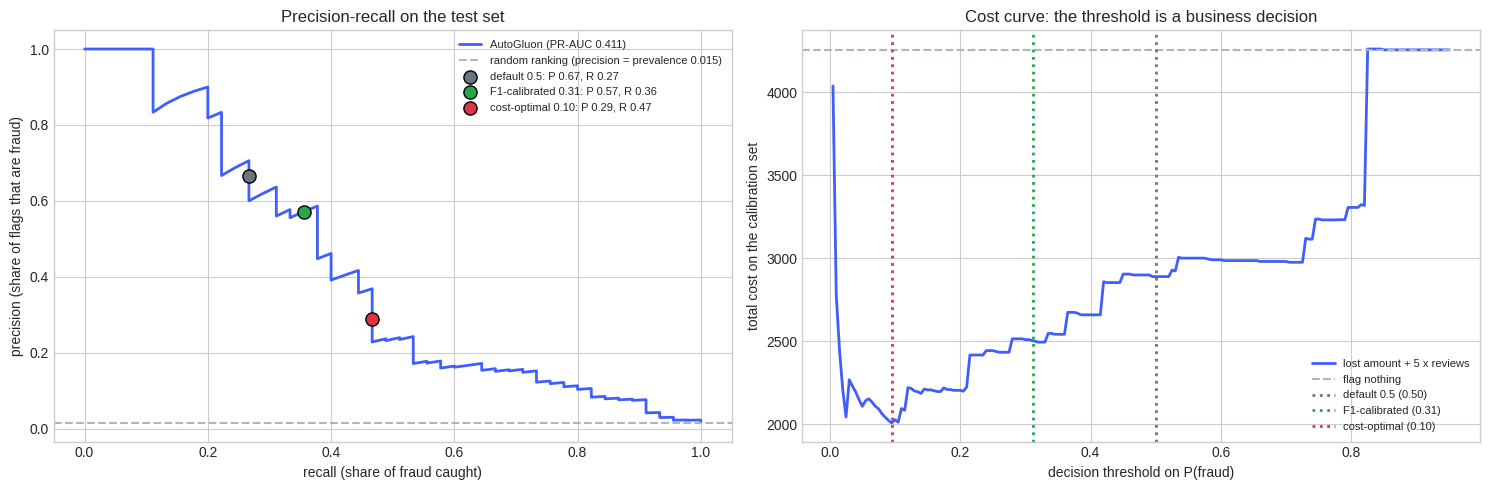

cost-optimal threshold 0.095 is below the F1 threshold 0.312: a review is the cheaper mistake here, so the cost curve flags more


In [38]:
prec, rec, thr = precision_recall_curve(fr_y, fr_prob_test)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.plot(rec, prec, color="#3f5efb", lw=2, label=f"AutoGluon (PR-AUC {average_precision_score(fr_y, fr_prob_test):.3f})")
ax.axhline(fr_y.mean(), color="#adb5bd", ls="--", label=f"random ranking (precision = prevalence {fr_y.mean():.3f})")
for t, c, name in [(t_default, "#6c757d", "default 0.5"), (t_f1, "#28a745", f"F1-calibrated {t_f1:.2f}"), (t_cost, "#dc3545", f"cost-optimal {t_cost:.2f}")]:
    flag = fr_prob_test >= t
    p_t = precision_score(fr_y, flag, zero_division=0); r_t = recall_score(fr_y, flag)
    ax.scatter([r_t], [p_t], s=90, color=c, edgecolor="k", zorder=5, label=f"{name}: P {p_t:.2f}, R {r_t:.2f}")
ax.set_xlabel("recall (share of fraud caught)"); ax.set_ylabel("precision (share of flags that are fraud)"); ax.set_title("Precision-recall on the test set"); ax.legend(fontsize=8, loc="upper right")
ax = axes[1]
ax.plot(grid, costs, color="#3f5efb", lw=2, label="lost amount + 5 x reviews")
ax.axhline(cost_no_model, color="#adb5bd", ls="--", label="flag nothing")
for t, c, name in [(t_default, "#6c757d", "default 0.5"), (t_f1, "#28a745", "F1-calibrated"), (t_cost, "#dc3545", "cost-optimal")]:
    ax.axvline(t, color=c, ls=":", lw=2, label=f"{name} ({t:.2f})")
ax.set_xlabel("decision threshold on P(fraud)"); ax.set_ylabel("total cost on the calibration set"); ax.set_title("Cost curve: the threshold is a business decision"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"cost-optimal threshold {t_cost:.3f} is {'below' if t_cost < t_f1 else 'above'} the F1 threshold {t_f1:.3f}: "
      + ("a review is the cheaper mistake here, so the cost curve flags more" if t_cost < t_f1 else "reviews outweigh the amounts at stake here, so the cost curve flags less"))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the precision-recall curve on the test set. Moving right along it catches more fraud at the price of more false alarms; the grey dashed line is where a random ranking would sit, so the height of the curve above it is the model's value. The three dots are the same model at three thresholds: same ranking, different cut. Right: the cost of each threshold on the calibration set. The curve is steep on the left (flag everything: reviews cost a fortune), dips, then climbs on the right toward the "flag nothing" line (miss everything: pay every fraud). The red line marks the bottom of the dip. Its position relative to the green F1 line is the lesson: F1 weighs a missed fraud and a false alarm equally, and here they are not equal, so the cost-optimal cut is different.

The common misread: reading the leaderboard's PR-AUC as the deliverable. PR-AUC scores the *ranking*; the business pays for the *cut*. Two models with the same PR-AUC can produce very different costs once a threshold is chosen.

</div>


In [39]:
rows = []
for name, t in [("default 0.5", t_default), ("F1-calibrated", t_f1), ("cost-optimal", t_cost)]:
    flag = fr_prob_test >= t
    rows.append({"threshold": name, "t": t, "flagged": int(flag.sum()), "fraud caught": int((flag & (fr_y == 1)).sum()), "fraud missed": int((~flag & (fr_y == 1)).sum()),
                 "precision": precision_score(fr_y, flag, zero_division=0), "recall": recall_score(fr_y, flag),
                 "amount saved": float(fr_test["amount"].values[flag & (fr_y == 1)].sum()), "test cost": total_cost(fr_y, fr_prob_test, fr_test["amount"].values, t)})
thr_table = pd.DataFrame(rows).set_index("threshold")
thr_table.loc["flag nothing"] = [1.0, 0, 0, int(fr_y.sum()), 0.0, 0.0, 0.0, total_cost(fr_y, np.zeros_like(fr_prob_test), fr_test["amount"].values, 0.5)]
print("the three thresholds applied to the untouched test set (chosen on other data, reported here):")
pretty(thr_table, fmt={"t": "{:.3f}", "flagged": "{:.0f}", "fraud caught": "{:.0f}", "fraud missed": "{:.0f}", "precision": "{:.3f}", "recall": "{:.3f}", "amount saved": "{:,.0f}", "test cost": "{:,.0f}"}, highlight="min", subset=["test cost"])


the three thresholds applied to the untouched test set (chosen on other data, reported here):


,t,flagged,fraud caught,fraud missed,precision,recall,amount saved,test cost
threshold,,,,,,,,
default 0.5,0.500,18,12,33,0.667,0.267,"1,855","2,479"
F1-calibrated,0.312,28,16,29,0.571,0.356,"2,169","2,215"
cost-optimal,0.095,73,21,24,0.288,0.467,"2,451","2,158"
flag nothing,1.000,0,0,45,0.000,0.000,0,"4,244"


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: choose the threshold on data the model did not train on, and report it on data the threshold did not see

The cost curve was drawn on `fr_calib`; the table above applies the winning cut to `fr_test`. That separation is the whole reason for the three-way split: a threshold tuned on the reporting set always looks better than it is. In production the cost of a review and the cost of a miss change with staffing and season, so store the calibration probabilities and re-run the cost curve when they change; the model can stay the same. `predictor.predict(df, decision_threshold=t)` applies any cut without retraining.

</div>

## 6.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Reach for a ranking metric and a cost curve whenever the positive class is rare

- **Fraud, defaults, churn of high-value accounts, machine failures, disease screening**: anywhere the positives are a few percent and the two mistakes have different prices.
- Set `eval_metric="average_precision"` (or `"roc_auc"` when the ranking across the whole population matters); never accuracy.
- Keep a calibration slice for the threshold; use `calibrate_decision_threshold` when the objective is a standard score, a cost curve when it is money.

**Cost**: nothing beyond Part 1; the fit is the same. **The one gotcha**: with very few positives every held-out fold is tiny, so scores are noisy. Look back at the leaderboard in 6.4: `score_val` for the top rows sits well above `score_test`, and the ensemble that won on validation is not the best model on test. The calibration set holds a few dozen frauds, which is why the cost curve is bumpy rather than smooth. More positives, or bagging (`num_bag_folds`), smooth both.

</div>

## 6.7 Task 6 Summary

**✅ Key Takeaways**
- On a 1.5% positive rate, accuracy is a number about the majority class; PR-AUC, recall, MCC and balanced accuracy are the columns to read.
- `eval_metric="average_precision"` makes AutoGluon select and weight models by how well they *rank* the rare class.
- The threshold is a separate decision. A cost curve on a calibration slice turns review cost and missed-fraud amounts into one number per threshold; the cheapest cut differed from both the default 0.5 and the F1-calibrated cut.
- Choose the cut on one slice, report on another; `predict(decision_threshold=t)` applies it at inference.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `make_fraud`, `fr_df`, `fr_train`, `fr_calib`, `fr_test` | the transactions and the three-way split |
| `fr_pred`, `fr_lb`, `fr_prob_test`, `fr_prob_calib`, `fr_cards` | the predictor, leaderboard, probabilities on both held-out slices, the report card with the baseline |
| `total_cost`, `grid`, `costs`, `t_cost`, `t_f1`, `thr_table` | the cost function, the cost curve, the three thresholds and their test-set consequences |

**➡️ Next Up:** Part 6 — the same three-line pattern for thirty stores' daily demand, with promotions the planners already know about.


# Part 6 · Time Series · Store Demand with Known Covariates and Chronos ⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The row is now a store on a day

Parts 1 to 5 had one row per customer, house or transaction. Here a row is one store **on one day**, and the order of the rows carries the signal: weekends sell more, summer sells more, and a promotion planned for next Tuesday will lift next Tuesday. `TimeSeriesPredictor` takes that long table, forecasts every store fourteen days ahead with a probability band, and can use a **known covariate**, a column whose future values are known in advance, such as the promotion calendar. A zero-shot pretrained forecaster (Chronos) joins at the end for comparison.

</div>


# Task 7 · Fourteen-day demand forecasts for thirty stores

## 7.1 ❓ The problem

A retail planner asks: *"How many units will each of our thirty stores sell over the next two weeks, given the promotions already scheduled, and how much safety stock does each one need?"* A good answer changes replenishment orders (the median), the safety stock (the 90th percentile), and whether a planned promotion is worth its cost (the lift the model attributes to `promo`).

## 7.2 📥 The input

The **long format**: one row per `(item_id, timestamp)` with the `target` and any covariates, plus a small **static** table with one row per store. The generator plants weekly seasonality, an annual cycle, a store-level scale, and a promotion lift; `promo` is 0/1 and is known for the forecast horizon because promotions are planned ahead.


In [40]:
def make_demand(n_stores=30, days=365, seed=RANDOM_STATE):
    # Daily units sold per store: weekly + annual seasonality, a store-level scale, and a planned promo calendar that lifts demand.
    rng = np.random.default_rng(seed)
    dates = pd.date_range("2025-01-01", periods=days, freq="D")
    dow_effect = np.array([0.95, 0.95, 1.00, 1.05, 1.20, 1.50, 1.35])[dates.dayofweek]      # Mon..Sun
    annual = 1 + 0.20 * np.sin(2 * np.pi * (dates.dayofyear / 365.25 - 0.70))               # peaks in the summer
    frames, static = [], []
    for s in range(n_stores):
        store_type = str(rng.choice(["mall", "street", "outlet"], p=[0.4, 0.4, 0.2]))
        scale = rng.uniform(40, 400) * {"mall": 1.3, "street": 1.0, "outlet": 0.8}[store_type]
        promo = (rng.random(days) < 0.08).astype(int)
        units = scale * dow_effect * annual * (1 + 0.35 * promo) * rng.lognormal(0, 0.08, days)
        frames.append(pd.DataFrame({"item_id": f"store_{s:02d}", "timestamp": dates, "target": units.round(0), "promo": promo}))
        static.append({"item_id": f"store_{s:02d}", "store_type": store_type})
    return pd.concat(frames, ignore_index=True), pd.DataFrame(static)

H = 14                                                     # prediction_length: two weeks ahead
dm_df, dm_static = make_demand(30, 365)
show_input(dm_df, label="target", name="daily store demand (long format)")
print("static features (one row per store):"); display(dm_static.head(3))
print(f"{dm_df.item_id.nunique()} stores x {dm_df.timestamp.nunique()} days | promo days: {dm_df.promo.mean():.1%} of rows | store types: {dm_static.store_type.value_counts().to_dict()}")


📥 daily store demand (long format): 10,950 rows x 4 columns | label = 'target'


,item_id,timestamp,target,promo
0,store_00,2025-01-01,251.0,0
1,store_00,2025-01-02,269.0,0
2,store_00,2025-01-03,287.0,0
3,store_00,2025-01-04,359.0,0
4,store_00,2025-01-05,323.0,0


column types: {'item_id': 'text/category', 'timestamp': 'datetime64[ns]', 'target': 'numeric', 'promo': 'numeric'}
label range: 33 .. 1.31e+03, mean 291
static features (one row per store):


,item_id,store_type
0,store_00,street
1,store_01,street
2,store_02,mall


30 stores x 365 days | promo days: 8.0% of rows | store types: {'street': 16, 'mall': 12, 'outlet': 2}


| Column | Type | Meaning |
|---|---|---|
| `item_id` | text | which series (store) the row belongs to |
| `timestamp` | datetime | the day |
| `target` | numeric | units sold that day: the value to forecast |
| `promo` | numeric 0/1 | a promotion ran that day; **known covariate** (the calendar is set in advance) |
| `store_type` (static) | category | mall / street / outlet, one value per store |

`TimeSeriesDataFrame.from_data_frame` turns the long table into a frame indexed by `(item_id, timestamp)` and attaches the static table. `train_test_split(prediction_length=H)` then cuts the **last 14 days of every series** off as the test horizon; the returned test frame keeps the history, because scoring a forecast needs the past that precedes it.


TimeSeriesDataFrame: 30 items, freq=D, shape=(10950, 2), static features=['store_type']
train: 351 days per store, ends 2025-12-17 | test: 365 days per store (history + the 14-day horizon)


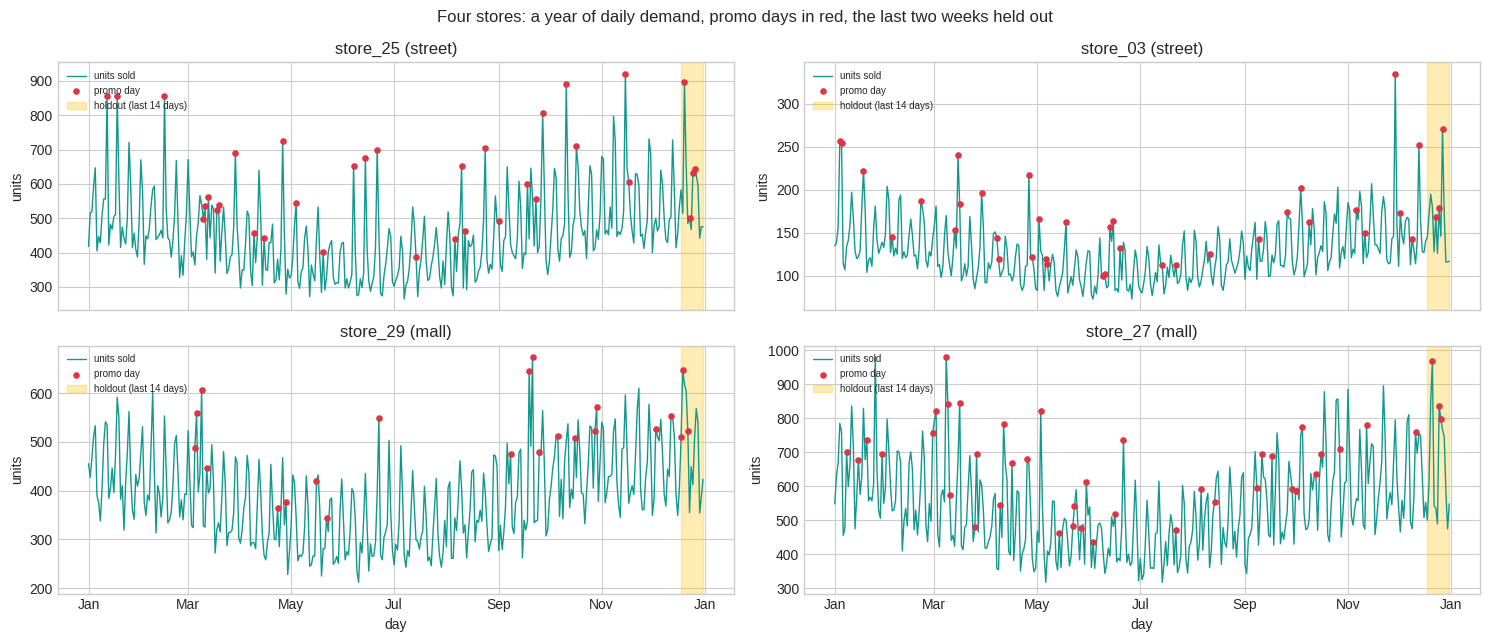

stores shown (most promo days in the horizon): {'store_25': 4, 'store_03': 3, 'store_29': 3, 'store_27': 3}


In [41]:
assert TS_OK, "autogluon.timeseries did not import; run the install line in Part 0"
dm_tsdf = TimeSeriesDataFrame.from_data_frame(dm_df, id_column="item_id", timestamp_column="timestamp", static_features_df=dm_static)
dm_train, dm_test = dm_tsdf.train_test_split(prediction_length=H)
print(f"TimeSeriesDataFrame: {dm_tsdf.num_items} items, freq={dm_tsdf.freq}, shape={dm_tsdf.shape}, static features={list(dm_tsdf.static_features.columns)}")
print(f"train: {dm_train.num_timesteps_per_item().iloc[0]} days per store, ends {dm_train.index.get_level_values('timestamp').max().date()} | "
      f"test: {dm_test.num_timesteps_per_item().iloc[0]} days per store (history + the {H}-day horizon)")
promo_in_horizon = dm_df[dm_df.timestamp > dm_df.timestamp.max() - pd.Timedelta(days=H)].groupby("item_id").promo.sum()
show_stores = promo_in_horizon.sort_values(ascending=False).index[:4].tolist()      # the four stores with the most promo days in the horizon
fig, axes = plt.subplots(2, 2, figsize=(15, 6.5), sharex=True)
for ax, sid in zip(axes.ravel(), show_stores):
    s = dm_tsdf.loc[sid]
    ax.plot(s.index, s["target"], color="#11998e", lw=1, label="units sold")
    pr = s[s.promo == 1]
    ax.scatter(pr.index, pr["target"], color="#dc3545", s=14, zorder=3, label="promo day")
    ax.axvspan(s.index[-H], s.index[-1], color="#ffc107", alpha=0.3, label=f"holdout (last {H} days)")
    ax.set_title(f"{sid} ({dm_static.set_index('item_id').loc[sid, 'store_type']})"); ax.set_ylabel("units"); ax.legend(fontsize=7, loc="upper left")
import matplotlib.dates as mdates
for ax in axes[1]: ax.set_xlabel("day"); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.suptitle("Four stores: a year of daily demand, promo days in red, the last two weeks held out"); plt.tight_layout(); plt.show()
print(f"stores shown (most promo days in the horizon): { {k: int(v) for k, v in promo_in_horizon.loc[show_stores].items()} }")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each panel is one store's year. The saw-tooth is the week (Saturday is the peak), the slow hump is the annual cycle, and the red dots sit above their neighbours because the generator lifts a promo day by about a third. The scales differ by panel: a mall store sells several times what an outlet does, which is why the forecast metric below is scale-free. The yellow band is the horizon: the model sees everything left of it and must produce the fourteen values inside it, and it is *told* which of those fourteen days carry a promotion.

The common misread: reading the yellow band as "test rows" sampled from the table. It is the **end** of every series, the same calendar cut for all stores. A random row split would leak the future into training.

</div>

## 7.3 💻 Three lines

Four things are declared up front because they shape the whole fit: `prediction_length` (the horizon), `freq="D"`, `known_covariates_names=["promo"]`, and `eval_metric="WQL"` so that models are selected on the quality of the whole quantile band rather than the median alone. One honesty note about presets: in this AutoGluon version `fast_training` maps to the `light` model set, and that set includes two pretrained foundation models whose weights download from the internet on first use. The cell prints the preset so the claim is verified, then names the five members of `light` that train locally, so this Part runs offline. `TimeSeriesPredictor.fit` has no `num_cpus` argument; the per-model `n_jobs` and `num_threads` settings play that role.


In [42]:
from autogluon.timeseries.configs import get_predictor_presets, get_hyperparameter_presets
light_models = list(get_hyperparameter_presets()["light"].keys())
print(f"presets['fast_training'] = {get_predictor_presets()['fast_training']}  ->  'light' = {light_models}")
dm_hparams = {                                            # the members of `light` that need no download
    "SeasonalNaive": {"n_jobs": 1}, "ETS": {"n_jobs": 1}, "Theta": {"n_jobs": 1},                       # local statistical models, one series at a time
    "RecursiveTabular": {"model_hyperparameters": {"num_threads": N_CPUS}},                          # global gradient-boosting on lag features; these two USE `promo`
    "DirectTabular": {"model_hyperparameters": {"num_threads": N_CPUS}},
}
with timer("TimeSeriesPredictor.fit (5 models + ensemble)"):
    dm_pred = TimeSeriesPredictor(prediction_length=H, freq="D", eval_metric="WQL", known_covariates_names=["promo"],
                                  quantile_levels=[0.1, 0.5, 0.9], path=os.path.join(WORK, "part6"), verbosity=0).fit(
        dm_train, hyperparameters=dm_hparams, time_limit=90, random_seed=RANDOM_STATE)
dm_lb = dm_pred.leaderboard(dm_test, extra_metrics=["MASE", "SMAPE"])
dm_future = dm_pred.make_future_data_frame(dm_train)                                    # (item_id, timestamp) rows for the 14 days after train
dm_known = dm_future.merge(dm_df[["item_id", "timestamp", "promo"]], on=["item_id", "timestamp"], how="left")   # fill from the planned promo calendar
dm_fc = dm_pred.predict(dm_train, known_covariates=dm_known)
print(f"eval metric: {dm_pred.eval_metric} | best on validation: {dm_pred.model_best} | forecast columns: {list(dm_fc.columns)} | forecast rows: {len(dm_fc)} = {dm_fc.num_items} stores x {H} days")


presets['fast_training'] = {'hyperparameters': 'light'}  ->  'light' = ['SeasonalNaive', 'ETS', 'Theta', 'RecursiveTabular', 'DirectTabular', 'Chronos2', 'Toto2']
⏱️ TimeSeriesPredictor.fit (5 models + ensemble): 32.3 s
eval metric: WQL | best on validation: WeightedEnsemble | forecast columns: ['mean', '0.1', '0.5', '0.9'] | forecast rows: 420 = 30 stores x 14 days


## 7.4 📤 The output

The leaderboard scores every model on the held-out fortnight with WQL (the fit metric), MASE and sMAPE as extra columns; all three are sign-flipped so that higher is better. The forecast frame has a `mean` column and one column per quantile level; the cell after the leaderboard places one store's fourteen forecast rows next to the actual sales and the promo flag.


In [43]:
print("| WQL: weighted quantile loss (the band) | MASE: error relative to seasonal naive, 1.0 = no better than 'same weekday last week' | sMAPE: symmetric % error |")
pretty(dm_lb.set_index("model")[["score_test", "score_val", "MASE", "SMAPE", "fit_time_marginal", "pred_time_test"]], subset=["score_test", "score_val", "MASE", "SMAPE"])


| WQL: weighted quantile loss (the band) | MASE: error relative to seasonal naive, 1.0 = no better than 'same weekday last week' | sMAPE: symmetric % error |


,score_test,score_val,MASE,SMAPE,fit_time_marginal,pred_time_test
model,,,,,,
WeightedEnsemble,-0.043,-0.044,-0.651,-0.066,0.490,5.345
DirectTabular,-0.044,-0.045,-0.647,-0.066,14.763,0.215
Theta,-0.064,-0.064,-0.921,-0.092,0.023,0.445
ETS,-0.068,-0.067,-1.012,-0.101,0.029,4.890
RecursiveTabular,-0.072,-0.071,-0.823,-0.083,4.518,0.236
SeasonalNaive,-0.092,-0.086,-1.248,-0.121,0.024,0.036


In [44]:
sid = show_stores[0]
one = dm_fc.loc[sid].copy().round(0)
one.columns = ["mean", "q10", "q50", "q90"]
one["actual"] = dm_test.loc[sid, "target"].iloc[-H:].values
one["promo"] = dm_known.set_index(["item_id", "timestamp"]).loc[sid, "promo"].values
one["inside 10-90"] = (one.actual >= one.q10) & (one.actual <= one.q90)
print(f"{sid}: the {H}-day forecast frame next to the truth")
display(one)
dm_scores = dm_pred.evaluate(dm_test, metrics=["WQL", "MASE", "SMAPE"])
y_h = dm_test.slice_by_timestep(-H, None)["target"]
inside = ((y_h.values >= dm_fc["0.1"].values) & (y_h.values <= dm_fc["0.9"].values)).mean()
print(f"\npredictor.evaluate on the holdout (sign-flipped back to 'lower is better'): " + ", ".join(f"{k} {-v:.3f}" for k, v in dm_scores.items()))
print(f"80% band coverage across all {dm_fc.num_items} stores x {H} days: {inside:.1%} (target 80%)")


store_25: the 14-day forecast frame next to the truth


,mean,q10,q50,q90,actual,promo,inside 10-90
timestamp,,,,,,,
2025-12-18,486.0,438.0,486.0,511.0,583.0,0,False
2025-12-19,546.0,515.0,546.0,578.0,514.0,0,False
2025-12-20,815.0,671.0,815.0,926.0,898.0,1,True
2025-12-21,623.0,573.0,623.0,665.0,654.0,0,True
2025-12-22,456.0,397.0,456.0,496.0,485.0,0,True
2025-12-23,600.0,531.0,600.0,637.0,501.0,1,False
2025-12-24,469.0,411.0,469.0,512.0,467.0,0,True
2025-12-25,663.0,558.0,663.0,714.0,633.0,1,True
2025-12-26,718.0,606.0,718.0,752.0,644.0,1,True



predictor.evaluate on the holdout (sign-flipped back to 'lower is better'): WQL 0.043, MASE 0.651, SMAPE 0.066
80% band coverage across all 30 stores x 14 days: 80.7% (target 80%)


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently): what WQL and MASE measure

**MASE** divides each store's absolute forecast error by that store's own *seasonal-naive* error inside the training window (the error of predicting "the same weekday last week", season $m = 7$ for daily data), then averages across stores:

$$ \text{MASE} = \frac{1}{N}\sum_{i=1}^{N} \frac{\frac{1}{H}\sum_{t=T+1}^{T+H} |y_{i,t} - f_{i,t}|}{\frac{1}{T-m}\sum_{t=m+1}^{T} |y_{i,t} - y_{i,t-m}|} $$

It is unit-free, so the mall store and the outlet count equally, and **1.0 is the bar**: a model above it has learned nothing the calendar did not already know.

**WQL** scores the whole band. It is the pinball loss from Part 4 summed over the three quantile levels and every forecast point, divided by the total absolute demand so it reads as a fraction of sales:

$$ \text{WQL} = \frac{2\sum_{i,t}\frac{1}{|Q|}\sum_{q \in Q}\rho_q\!\left(y_{i,t}, f^q_{i,t}\right)}{\sum_{i,t}|y_{i,t}|} $$

A WQL of 0.05 means the band costs about five percent of demand in pinball units. Lower is better; the leaderboard shows it negated.

</div>

## 7.5 📊 The picture


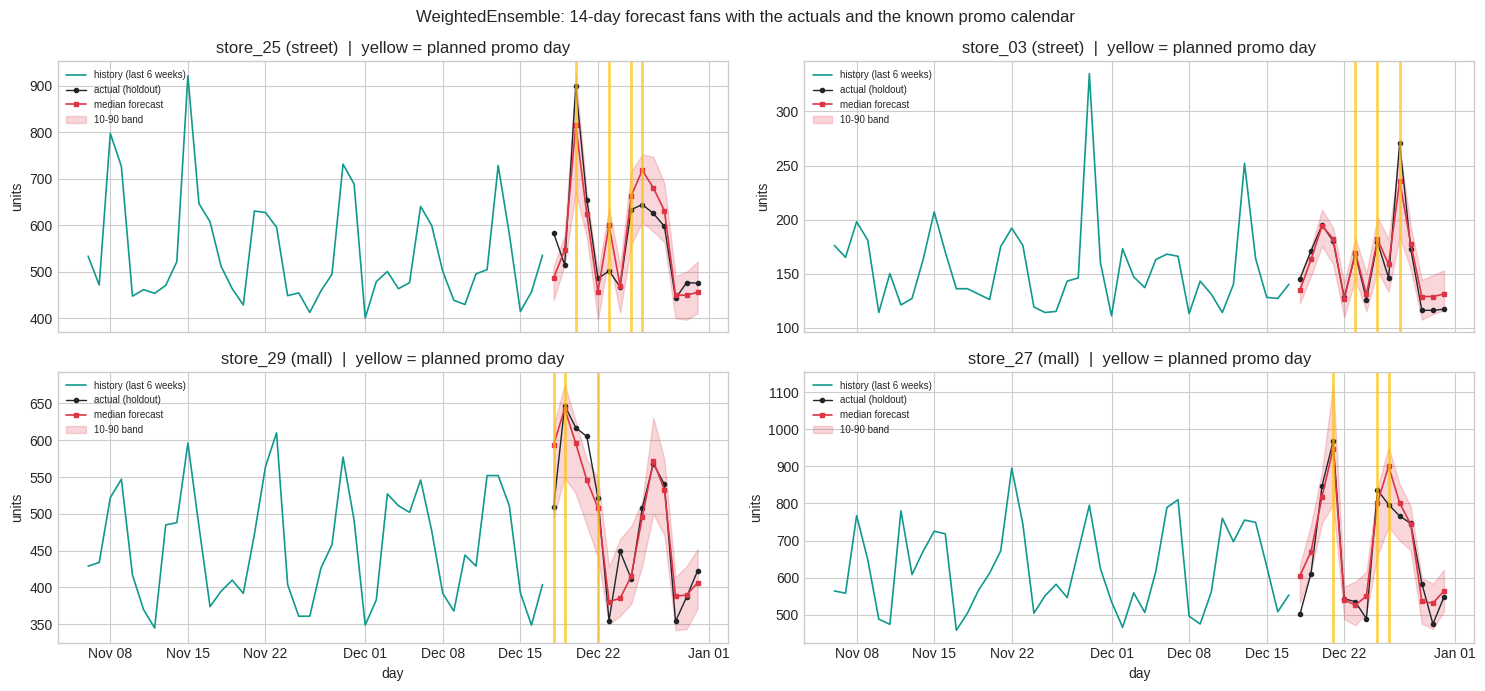

promo days inside the horizon across all stores: 36 | shown stores: ['store_25', 'store_03', 'store_29', 'store_27']


In [45]:
fig, axes = plt.subplots(2, 2, figsize=(15, 7), sharex=True)
for ax, sid in zip(axes.ravel(), show_stores):
    hist = dm_train.loc[sid, "target"].iloc[-42:]
    truth = dm_test.loc[sid, "target"].iloc[-H:]
    fc = dm_fc.loc[sid]
    kp = dm_known[dm_known.item_id == sid].set_index("timestamp")["promo"]
    ax.plot(hist.index, hist.values, color="#11998e", lw=1.2, label="history (last 6 weeks)")
    ax.plot(truth.index, truth.values, "o-", ms=3, color="#212529", lw=1, label="actual (holdout)")
    ax.plot(fc.index, fc["0.5"], "s-", ms=3, color="#dc3545", lw=1.2, label="median forecast")
    ax.fill_between(fc.index, fc["0.1"], fc["0.9"], color="#dc3545", alpha=0.2, label="10-90 band")
    for d in kp[kp == 1].index: ax.axvline(d, color="#ffc107", lw=2, alpha=0.7)
    ax.set_title(f"{sid} ({dm_static.set_index('item_id').loc[sid, 'store_type']})  |  yellow = planned promo day"); ax.set_ylabel("units"); ax.legend(fontsize=7, loc="upper left")
import matplotlib.dates as mdates
for ax in axes[1]: ax.set_xlabel("day"); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.suptitle(f"{dm_pred.model_best}: {H}-day forecast fans with the actuals and the known promo calendar"); plt.tight_layout(); plt.show()
promo_days_in_horizon = int(dm_known.promo.sum())
print(f"promo days inside the horizon across all stores: {promo_days_in_horizon} | shown stores: {show_stores}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Green is the last six weeks the model saw; black dots are the fourteen held-out days; red squares are the median forecast and the shaded fan the 10-90 band. Yellow vertical lines are promotion days inside the horizon, which the model was told about through `known_covariates`. Two things to check: the median keeps the weekly saw-tooth going (Saturday peaks) without being told, and where a yellow line falls the median should jump up on that day, because the tabular models learned the promo lift from the training year. Black dots outside the fan are the honest misses; across all stores the coverage line in 7.4 says how often that happened.

The common misread: judging the forecast by whether the red squares hit the black dots. A median is supposed to miss about half the time in each direction; the questions are whether it beats seasonal naive (MASE below 1) and whether the fan holds the truth about 80% of the time.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: a known covariate must be knowable at forecast time

`promo` qualifies because the calendar is set weeks ahead; next week's *actual footfall* does not, and declaring it would leak the future into validation and produce a leaderboard that cannot be reproduced in production. The safe rule: `known_covariates` are columns you could fill in **today** for every day of the horizon, which is exactly what `make_future_data_frame` asks you to do, one row per store and day.

</div>

### Zero-shot: Chronos-Bolt without training

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔬 SOTA: pretrained forecasters

**Chronos** is a family of time-series foundation models: transformers pretrained on a large corpus of public series and used **zero-shot**, with no training on your data. The model reads a window of history and emits quantiles for the horizon. The cell below loads the smallest Chronos-Bolt (`bolt_tiny`) in a predictor of its own with `skip_model_selection=True` (nothing to select) and scores it on the same holdout. **On Colab**, the weights download from the HuggingFace Hub on first use (a small file) and are cached. **Offline**, the download fails; the `except` branch says so and the comparison chart is drawn from the fitted models only. `Chronos-Bolt` ignores covariates, so it does not see the promo calendar; the newer `Chronos2` model in the `light` preset does accept them.

</div>


In [46]:
chronos_ok, chronos_note, chronos_scores = False, "", {}
try:
    with timer("Chronos bolt_tiny (zero-shot: fit = load weights)"):
        ch_pred = TimeSeriesPredictor(prediction_length=H, freq="D", eval_metric="WQL", quantile_levels=[0.1, 0.5, 0.9],
                                      path=os.path.join(WORK, "part6_chronos"), verbosity=0).fit(
            dm_train, hyperparameters={"Chronos": {"model_path": "bolt_tiny"}}, skip_model_selection=True, time_limit=90)
    with timer("Chronos evaluate on the holdout"):
        chronos_scores = {k: -v for k, v in ch_pred.evaluate(dm_test, metrics=["WQL", "MASE", "SMAPE"]).items()}
    chronos_ok = True
    print("Chronos-Bolt (tiny) on the holdout, lower is better:", {k: round(v, 3) for k, v in chronos_scores.items()})
except Exception as e:                      # offline, weights unavailable, or a load error: keep going without it
    chronos_note = f"{type(e).__name__}: {str(e)[:160]}"
    print("Chronos unavailable in this session ->", chronos_note)
    print("On Colab with internet this cell downloads the bolt_tiny weights and adds a zero-shot row to the chart below.")
print(f"chronos_ok = {chronos_ok}")


⏱️ Chronos bolt_tiny (zero-shot: fit = load weights): 0.4 s


config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 34.6MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

⏱️ Chronos evaluate on the holdout: 3.0 s
Chronos-Bolt (tiny) on the holdout, lower is better: {'WQL': np.float64(0.067), 'MASE': 0.98, 'SMAPE': 0.099}
chronos_ok = True


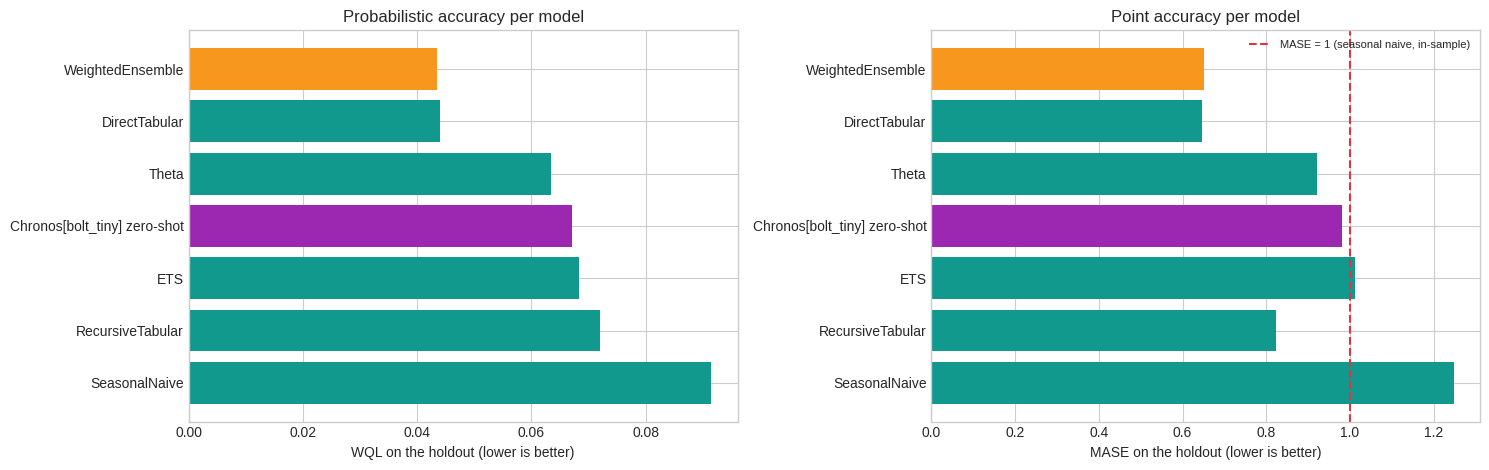

models compared: 7 (Chronos row included)


,WQL,MASE,sMAPE
model,,,
WeightedEnsemble,0.043,0.651,0.066
DirectTabular,0.044,0.647,0.066
Theta,0.064,0.921,0.092
Chronos[bolt_tiny] zero-shot,0.067,0.980,0.099
ETS,0.068,1.012,0.101
RecursiveTabular,0.072,0.823,0.083
SeasonalNaive,0.092,1.248,0.121


In [47]:
cmp = dm_lb.set_index("model")[["score_test", "MASE", "SMAPE"]].copy()
cmp.columns = ["WQL", "MASE", "sMAPE"]; cmp = -cmp                                   # flip back to lower-is-better
if chronos_ok:
    cmp.loc["Chronos[bolt_tiny] zero-shot"] = [chronos_scores["WQL"], chronos_scores["MASE"], chronos_scores["SMAPE"]]
cmp = cmp.sort_values("WQL")
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
bar_colors = ["#9c27b0" if "Chronos" in m else ("#f7971e" if "Ensemble" in m else "#11998e") for m in cmp.index]
axes[0].barh(cmp.index, cmp["WQL"], color=bar_colors); axes[0].invert_yaxis()
axes[0].set_xlabel("WQL on the holdout (lower is better)"); axes[0].set_title("Probabilistic accuracy per model")
axes[1].barh(cmp.index, cmp["MASE"], color=bar_colors); axes[1].invert_yaxis()
axes[1].axvline(1.0, color="#dc3545", ls="--", label="MASE = 1 (seasonal naive, in-sample)"); axes[1].legend(fontsize=8)
axes[1].set_xlabel("MASE on the holdout (lower is better)"); axes[1].set_title("Point accuracy per model")
plt.tight_layout(); plt.show()
print(f"models compared: {len(cmp)} ({'Chronos row included' if chronos_ok else 'Chronos row absent: ' + chronos_note})")
pretty(cmp, highlight="min")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: WQL per model on the same thirty-store holdout, the band metric; right: MASE, the point metric, with the dashed line at 1.0 that every serious model must sit left of. Green bars are the fitted models, orange the weighted ensemble, purple the zero-shot Chronos row when it loaded. Read the two panels together: the tabular models that were given the promo calendar should lead on both, `SeasonalNaive` should be the worst fitted row (it is the definition of MASE = 1, up to the difference between the training window and the holdout), and the pretrained model that **never saw this data and never saw the promo calendar** should land among the classical local models: ahead of seasonal naive, behind the covariate-aware tabular models. That is the honest 2026 picture: a zero-shot forecaster is a strong first answer in minutes; a fitted model with the right covariates is the better final one.

The common misread: comparing fit times across the two kinds of model. For Chronos the "fit" is the time to load weights; its real cost is a transformer forward pass per series at prediction time.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ A zero-shot model has no `score_val`, and a promo it cannot see is a miss it cannot avoid

`skip_model_selection=True` means no backtest was run: the Chronos predictor cannot say how good it is until you score it on your own holdout, as above. And because Chronos-Bolt ignores covariates, every promo day in the horizon is a surprise to it; look at the promo count printed under the forecast fans and expect its MASE to pay for each one. When covariates matter, use a model that accepts them (`Chronos2`, the tabular forecasters, or the deep models in `high_quality`).

</div>

## 7.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Reach for `TimeSeriesPredictor` when you have many related series and need a band, not a number

- **Demand, traffic, energy, call volumes, cash flows**: dozens to millions of series with a shared calendar.
- **Probabilistic output** for stock and staffing: `quantile_levels` gives the safety-stock percentile for free.
- **Known future inputs**: promotions, prices, holidays, weather forecasts, via `known_covariates_names`.

**Cost**: the local statistical models are fast; global tabular models and deep models scale with the number of series; foundation models need a download and a forward pass per series. **The one gotcha**: this is not the tool for *one* long series with rich exogenous structure (a single stock, one sensor with fifty inputs). There a tabular regressor with hand-built lag features, or a classical econometric model, gives more control.

</div>

## 7.7 Task 7 Summary

**✅ Key Takeaways**
- The input is a long table `(item_id, timestamp, target, covariates...)` plus optional static features; `train_test_split(prediction_length)` cuts the end of every series and keeps the history for scoring.
- `known_covariates_names` declares columns whose future values are known; `make_future_data_frame` gives the exact rows to fill for the horizon.
- `eval_metric="WQL"` selects models by the whole band; MASE puts every store on the same scale, and 1.0 is the bar.
- `fast_training` maps to the `light` set, which includes downloading foundation models; naming the five local members keeps the fit offline. `fit` has no `num_cpus`; use per-model `n_jobs` / `num_threads`.
- Chronos-Bolt forecasts zero-shot with no training and no validation score; it is compared on your holdout like any other row, and it cannot use the promo calendar.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `make_demand`, `dm_df`, `dm_static`, `dm_tsdf`, `dm_train`, `dm_test` | the long table, the static table, the `TimeSeriesDataFrame` and its time split (`H = 14`) |
| `dm_hparams`, `dm_pred`, `dm_lb`, `dm_scores` | the five local models, the fitted predictor, its leaderboard and `evaluate` scores |
| `dm_future`, `dm_known`, `dm_fc` | the future index, the promo calendar for the horizon, the forecast frame (mean + quantiles) |
| `chronos_ok`, `ch_pred`, `chronos_scores`, `cmp` | whether the zero-shot model loaded, its predictor and scores, the comparison table behind the bars |

**➡️ Next Up:** Part 7 — a product-review table with a free-text column: what `TabularPredictor` does with text on its own, and what `MultiModalPredictor` adds.


# Part 7 · Text + Tabular · Product Reviews ⭐⭐

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### A column of sentences next to columns of numbers

Parts 1 to 6 fed AutoGluon numbers, categories and dates. Part 7 adds the column most business tables actually contain and most tutorials skip: **free text**. The same three lines still work. `TabularPredictor` turns the text into counts it can learn from on its own; `MultiModalPredictor` fine-tunes a small language model on it. This Part runs both on the same reviews and puts their report cards side by side, so the answer to "is the transformer worth it?" is a number, not an opinion.

</div>

# Task 8 · Which Reviews Will Readers Find Helpful?

## 8.1 ❓ The problem

An online store shows the most helpful reviews first. New reviews have no votes yet, so the ranking team asks: **from the review itself, will readers mark it helpful?** A good answer puts informative reviews at the top of the page on day one instead of waiting weeks for votes. The input is a review's text plus a few facts about it (stars, price, category, verified purchase); the output is a probability of being voted helpful.

## 8.2 📥 The input

`make_reviews` writes reviews from phrase banks: an opening sentence with a sentiment strength from strong negative to strong positive, zero to four **detail sentences** (numbers, comparisons, delivery facts), some vague fragments, and a closer. Helpfulness depends on how strong the opinion is, how many concrete details it gives, whether the purchase is verified, and length. The star rating follows the sentiment with noise, so it carries some of the signal but not the detail count: that lives only in the text.

In [48]:
def make_reviews(n=2000, seed=RANDOM_STATE):
    # Templated product reviews: sentiment strength s in -2..2, k detail sentences, a few vague fragments, a closer.
    rng = np.random.default_rng(seed)
    products = {"electronics": ["headphones", "keyboard", "phone case", "smart speaker"],
                "kitchen": ["blender", "coffee maker", "water bottle", "frying pan"],
                "sports": ["running shoes", "yoga mat", "backpack", "cycling gloves"],
                "home": ["desk lamp", "office chair", "bed sheets", "cordless vacuum"]}
    openers = {
        2: ["I have used the {p} every day for a month and it still works like new.", "This {p} is the best purchase I made this year.", "Absolutely love this {p}; it exceeded every expectation I had."],
        1: ["The {p} is solid and does what the listing promises.", "Happy with the {p} overall, a couple of small quirks aside.", "Good {p} for the price, no complaints so far."],
        0: ["The {p} arrived and it is a {p}.", "It is an average {p}, nothing special either way.", "Bought this {p} as a gift so I have not used it much."],
        -1: ["The {p} is okay but not what I hoped for.", "Slightly disappointed with the {p}; the build feels cheap.", "The {p} works, but the description oversold it."],
        -2: ["This {p} broke within a week and support ignored my emails.", "Worst {p} I have ever owned; it failed on the second use.", "Do not buy this {p}, it is a waste of money and time."]}
    details = ["Battery lasted about {h} hours on a full charge, which matches the box.", "Delivery took {d} days and the packaging was intact.",
               "Setup took me {m} minutes following the printed guide.", "It weighs less than my old one and fits in a standard bag.",
               "I compared it against two other models before buying and this one had the better warranty.", "After {w} weeks the stitching and seams are holding up fine.",
               "The instructions cover cleaning, which the cheaper models skip.", "Customer support replied within {d} days when I asked about sizing.",
               "It runs quieter than the previous version, measured with a phone app at {db} dB.", "The cable is {c} metres long, enough to reach across a desk."]
    vague = ["Great.", "Not bad.", "Does the job.", "Would buy again.", "Meh.", "Fine I guess.", "Ok product.", "Good value.", "It is what it is."]
    closers = {2: ["Highly recommend to anyone who needs a reliable {p}.", "Five stars from me."], 1: ["Would recommend with minor reservations.", "Worth the money."],
               0: ["Time will tell.", "No strong feelings."], -1: ["Might return it.", "Look at alternatives first."], -2: ["Returning it tomorrow.", "Save your money."]}
    rows = []
    for _ in range(n):
        cat = rng.choice(list(products)); p = rng.choice(products[cat])
        s = int(rng.choice([-2, -1, 0, 1, 2], p=[0.15, 0.2, 0.2, 0.25, 0.2]))
        k = int(rng.choice([0, 1, 2, 3, 4], p=[0.3, 0.3, 0.2, 0.12, 0.08]))
        v = int(rng.choice([0, 1, 2, 3], p=[0.4, 0.3, 0.2, 0.1]))
        fill = dict(p=p, h=rng.integers(4, 30), d=rng.integers(1, 9), m=rng.integers(5, 45), w=rng.integers(2, 12), db=rng.integers(30, 60), c=rng.integers(1, 4))
        parts = [rng.choice(openers[s]).format(**fill)]
        parts += [d.format(**fill) for d in rng.choice(details, size=k, replace=False)]
        parts += list(rng.choice(vague, size=v, replace=False))
        parts.append(rng.choice(closers[s]).format(**fill))
        text = " ".join(parts)
        verified = bool(rng.random() < 0.7)
        stars = int(np.clip(round(3 + s + rng.normal(0, 0.6)), 1, 5))
        n_words = len(text.split())
        logit = -2.2 + 0.8 * abs(s) + 0.55 * k + 0.8 * verified + 0.012 * (n_words - 45) - 0.25 * v + rng.normal(0, 0.7)
        rows.append({"review_text": text, "star_rating": stars, "price": round(float(np.exp(rng.normal(3.4, 0.6))), 2),
                     "category": cat, "verified_purchase": verified, "helpful": int(rng.random() < 1 / (1 + np.exp(-logit)))})
    return pd.DataFrame(rows)

reviews = make_reviews(2000)
rv_train, rv_test = train_test_split(reviews, test_size=0.25, random_state=RANDOM_STATE, stratify=reviews["helpful"])
show_input(reviews, label="helpful", name="product reviews")
print(f"\nwords per review: mean {reviews.review_text.str.split().str.len().mean():.1f}, min {reviews.review_text.str.split().str.len().min()}, max {reviews.review_text.str.split().str.len().max()}")
for i in reviews.sample(3, random_state=RANDOM_STATE).index:
    r = reviews.loc[i]; print(f"\n[{r.star_rating}★ | {r.category} | verified={r.verified_purchase} | helpful={r.helpful}] {r.review_text}")


📥 product reviews: 2,000 rows x 6 columns | label = 'helpful'


,review_text,star_rating,price,category,verified_purchase,helpful
0,"Bought this smart speaker as a gift so I have not used it much. I compared it against two other models before buying and this one had the better warranty. The instructions cover cleaning, which the cheaper models skip. Delivery took 1 days and the packaging was intact. Meh. Time will tell.",3,39.67,electronics,False,1
1,"Worst phone case I have ever owned; it failed on the second use. The instructions cover cleaning, which the cheaper models skip. Customer support replied within 7 days when I asked about sizing. The cable is 3 metres long, enough to reach across a desk. Would buy again. Returning it tomorrow.",1,108.31,electronics,True,0
2,"It is an average coffee maker, nothing special either way. The instructions cover cleaning, which the cheaper models skip. No strong feelings.",2,20.10,kitchen,False,0
3,"The frying pan works, but the description oversold it. The instructions cover cleaning, which the cheaper models skip. Customer support replied within 7 days when I asked about sizing. Look at alternatives first.",2,25.40,kitchen,False,1
4,Bought this water bottle as a gift so I have not used it much. It weighs less than my old one and fits in a standard bag. Great. Meh. Time will tell.,3,15.18,kitchen,True,1


column types: {'review_text': 'text/category', 'star_rating': 'numeric', 'price': 'numeric', 'category': 'text/category', 'verified_purchase': 'boolean', 'helpful': 'numeric'}
label distribution: {0: 0.554, 1: 0.446}

words per review: mean 34.5, min 11, max 82

[2★ | sports | verified=True | helpful=1] Slightly disappointed with the cycling gloves; the build feels cheap. It weighs less than my old one and fits in a standard bag. Delivery took 1 days and the packaging was intact. Great. Look at alternatives first.

[2★ | electronics | verified=True | helpful=1] Worst keyboard I have ever owned; it failed on the second use. Returning it tomorrow.

[2★ | kitchen | verified=True | helpful=1] It is an average frying pan, nothing special either way. After 3 weeks the stitching and seams are holding up fine. Fine I guess. Does the job. Time will tell.


| Column | Type | Meaning |
|---|---|---|
| `review_text` | text | the review: an opener, some detail sentences, a closer |
| `star_rating` | numeric (1-5) | the star rating the reviewer gave |
| `price` | numeric | product price |
| `category` | category | electronics / kitchen / sports / home |
| `verified_purchase` | boolean | whether the store confirmed the purchase |
| `helpful` | **label**, binary | 1 if readers voted the review helpful |

AutoGluon will see `star_rating` and `price` as numeric, `category` as categorical, `verified_purchase` as boolean, and `review_text` as **text**, because it has many distinct values with several words each. That last inference is what makes this Part different from Part 1: the text column is not one-hot encoded as a category; it is expanded into text statistics and word n-gram counts.

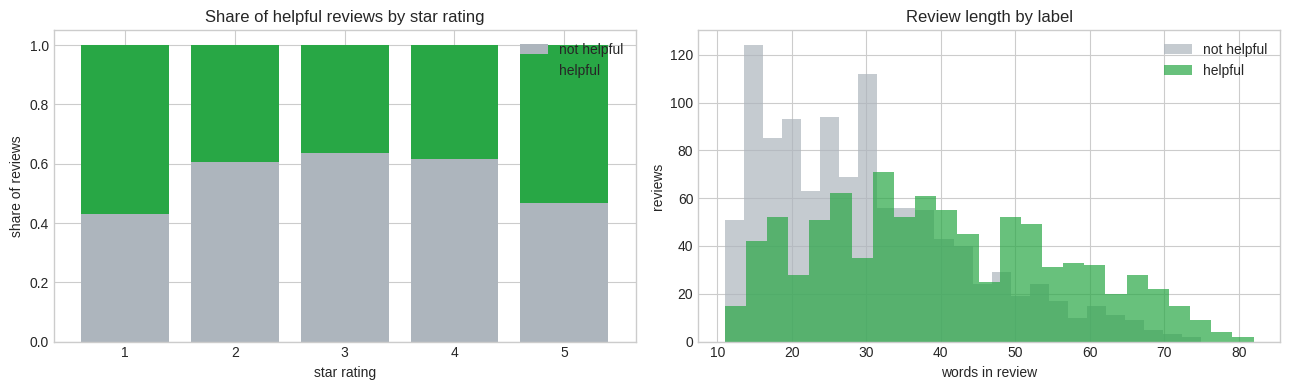

helpful share at 3 stars: 0.36 | at 1 star: 0.57 | at 5 stars: 0.53
median words: helpful 38 vs not helpful 28


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ct = pd.crosstab(reviews["star_rating"], reviews["helpful"], normalize="index")
ct.plot(kind="bar", stacked=True, ax=axes[0], color=["#adb5bd", "#28a745"], width=0.8)
axes[0].set_title("Share of helpful reviews by star rating"); axes[0].set_xlabel("star rating"); axes[0].set_ylabel("share of reviews")
axes[0].legend(["not helpful", "helpful"], loc="upper right"); axes[0].tick_params(axis="x", rotation=0)
wl = reviews.review_text.str.split().str.len()
for lab, c, nm in [(0, "#adb5bd", "not helpful"), (1, "#28a745", "helpful")]:
    axes[1].hist(wl[reviews.helpful == lab], bins=25, alpha=0.7, color=c, label=nm)
axes[1].set_title("Review length by label"); axes[1].set_xlabel("words in review"); axes[1].set_ylabel("reviews"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"helpful share at 3 stars: {ct.loc[3, 1]:.2f} | at 1 star: {ct.loc[1, 1]:.2f} | at 5 stars: {ct.loc[5, 1]:.2f}")
print(f"median words: helpful {wl[reviews.helpful == 1].median():.0f} vs not helpful {wl[reviews.helpful == 0].median():.0f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the helpful share is U-shaped in the star rating. Strong opinions at one and five stars are voted helpful more often than lukewarm three-star reviews, so the rating alone carries real signal. Right: helpful reviews are longer, because the detail sentences that readers value add words. Neither plot can see *which* words: two reviews of the same length and rating can differ only in whether they give a battery-life figure or say "Meh". That difference is what the text features are for.

The common misread: assuming a U-shape means the model needs a quadratic term. Tree ensembles and n-gram models both learn non-monotone effects without being told; the shape matters for *reading* the input, not for choosing the model.

</div>

## 8.3 💻 Three lines

The first fit is exactly the Part 1 call. Nothing in it mentions text: AutoGluon's feature generator detects the text column, adds **text statistics** (character count, word count, capital letters, symbol ratios) and **n-gram counts** (the most frequent words and word pairs, as a sparse count matrix), and every model in the zoo trains on the expanded table.

In [50]:
import inspect
assert "num_cpus" in inspect.signature(TabularPredictor.fit).parameters   # verified against the installed version
with timer("TabularPredictor.fit on reviews (text handled automatically)"):
    rv_tab = TabularPredictor(label="helpful", eval_metric="roc_auc", path=os.path.join(WORK, "part7_tab"), verbosity=0).fit(
        rv_train, time_limit=45, presets="medium_quality", num_cpus=N_CPUS)
print(f"problem type inferred: {rv_tab.problem_type} | eval metric: {rv_tab.eval_metric.name} | best model: {rv_tab.model_best}")
rv_tab_lb = rv_tab.leaderboard(rv_test, silent=True)
pretty(rv_tab_lb.set_index("model")[["score_test", "score_val", "pred_time_test", "fit_time"]], subset=["score_test", "score_val"])


⏱️ TabularPredictor.fit on reviews (text handled automatically): 22.1 s
problem type inferred: binary | eval metric: roc_auc | best model: WeightedEnsemble_L2


,score_test,score_val,pred_time_test,fit_time
model,,,,
WeightedEnsemble_L2,0.750,0.780,0.081,8.306
CatBoost,0.746,0.776,0.022,4.393
RandomForestEntr,0.742,0.742,0.126,1.420
XGBoost,0.741,0.717,0.027,1.198
ExtraTreesEntr,0.741,0.736,0.126,1.190
RandomForestGini,0.740,0.745,0.124,1.310
ExtraTreesGini,0.735,0.738,0.139,1.202
NeuralNetTorch,0.728,0.752,0.026,2.303
NeuralNetFastAI,0.727,0.747,0.029,1.521


In [51]:
raw_types = rv_tab.feature_metadata_in.type_map_raw
special_in = dict(rv_tab.feature_metadata_in.type_group_map_special)
feats_out = rv_tab.feature_metadata.get_features()
text_stats = [f for f in feats_out if f.startswith("review_text.")]
ngrams = [f for f in feats_out if f.startswith("__nlp__.")]
print("input column types AutoGluon inferred:", raw_types)
print("special types on input:", special_in)
print(f"\nfeatures after preprocessing: {len(feats_out)} = {len(text_stats)} text statistics + {len(ngrams)} n-gram counts + {len(feats_out) - len(text_stats) - len(ngrams)} original columns")
print("text statistics:", text_stats)
print("first 20 n-grams:", [f.replace('__nlp__.', '') for f in ngrams[:20]])


input column types AutoGluon inferred: {'review_text': 'object', 'star_rating': 'int', 'price': 'float', 'category': 'object', 'verified_purchase': 'bool'}
special types on input: {'text': ['review_text']}

features after preprocessing: 152 = 11 text statistics + 136 n-gram counts + 5 original columns
text statistics: ['review_text.char_count', 'review_text.word_count', 'review_text.capital_ratio', 'review_text.lower_ratio', 'review_text.digit_ratio', 'review_text.special_ratio', 'review_text.symbol_count..', 'review_text.symbol_ratio..', 'review_text.symbol_ratio. ', 'review_text.symbol_count.;', 'review_text.symbol_ratio.;']
first 20 n-grams: ['10', 'about', 'about hours', 'about sizing', 'about sizing it', 'absolutely', 'across', 'after', 'after weeks', 'again', 'against', 'alternatives', 'an', 'and', 'and does', 'and fits', 'and it', 'and it is', 'and it still', 'and support']


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: check `feature_metadata_in` before trusting a text column

The printout above is the proof that the text was *used*: `review_text` carries the `text` special type on input, and the output feature list contains `review_text.char_count`-style statistics plus a block of `__nlp__.` n-gram columns. If a free-text column shows up as `category` instead (it happens when a sample has few distinct values, or the strings are short), force it with `feature_metadata=FeatureMetadata.from_df(train).add_special_types({"review_text": ["text"]})`. Silent one-hot encoding of free text is the most common way a text column contributes nothing.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔬 The second fit: `MultiModalPredictor` fine-tunes a language model

`MultiModalPredictor` builds one neural network with a branch per column type: a pretrained **transformer** reads `review_text`, small MLPs read the numeric and categorical columns, and a fusion head combines them. The whole network is trained end to end. The cell below keeps it cheap on a CPU: a two-layer BERT (`google/bert_uncased_L-2_H-128_A-2`, about four million parameters), two epochs, 32-bit precision, no data-loader worker processes. `column_types={"review_text": "text"}` makes the text branch explicit.

**Online**, Colab downloads that checkpoint from the HuggingFace Hub once (a few megabytes) and fine-tunes it. **Offline**, or if anything in the download or the trainer fails, the `except` branch runs the baseline every text problem should have anyway: TF-IDF n-grams on the text plus the other columns, through logistic regression. Either path produces `rv_mm_proba` and a report card, so the comparison table below always has two rows.

</div>

In [52]:
# !pip install -q autogluon.multimodal   # part of the full `autogluon` install; MM_OK (Part 0) says whether it imported
import logging, torch
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
for _n in ("lightning.pytorch", "lightning", "pytorch_lightning"):
    logging.getLogger(_n).setLevel(logging.WARNING)           # silence the trainer's per-epoch chatter

rv_mm_hp = {"model.hf_text.checkpoint_name": "google/bert_uncased_L-2_H-128_A-2",   # a 2-layer BERT; fine-tunes in seconds per epoch on a CPU
            "optim.max_epochs": 2,
            "env.num_gpus": 1 if GPU else 0, "env.precision": "16-mixed" if GPU else 32,
            "env.num_workers": 0, "env.num_workers_inference": 0, "env.batch_size": 32, "env.per_gpu_batch_size": 32}
rv_mm_ok, rv_mm_note = False, ""
_prev = torch.get_num_threads(); torch.set_num_threads(N_CPUS)
try:
    if not MM_OK:
        raise ImportError("autogluon.multimodal did not import in Part 0")
    with timer("MultiModalPredictor.fit (bert-tiny + tabular MLPs)"):
        rv_mm = MultiModalPredictor(label="helpful", eval_metric="roc_auc", path=os.path.join(WORK, "part7_mm"), verbosity=0, enable_progress_bar=False)
        rv_mm.fit(rv_train, column_types={"review_text": "text"}, hyperparameters=rv_mm_hp, time_limit=120, seed=RANDOM_STATE)
    rv_mm_proba = rv_mm.predict_proba(rv_test)[1].values
    rv_mm_ok, rv_mm_name = True, "MultiModalPredictor (bert-tiny fusion)"
    print(f"problem type: {rv_mm.problem_type} | column types: {dict(rv_mm.column_types)}")
except Exception as e:  # noqa: BLE001 - offline, no checkpoint, or a trainer error: the n-gram baseline runs instead
    rv_mm_note = f"{type(e).__name__}: {str(e)[:140]}"
    print("MultiModalPredictor did not run ->", rv_mm_note)
    print("Online, Colab downloads google/bert_uncased_L-2_H-128_A-2 and fine-tunes it; this session uses TF-IDF + logistic regression instead.")
    rv_mm_name = "Fallback: TF-IDF + tabular -> LogReg"
    rv_fb = Pipeline([("prep", ColumnTransformer([("txt", TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=True), "review_text"),
                                                  ("num", StandardScaler(), ["star_rating", "price"]),
                                                  ("cat", OneHotEncoder(handle_unknown="ignore"), ["category", "verified_purchase"])])),
                      ("clf", LogisticRegression(max_iter=2000, C=2.0, random_state=RANDOM_STATE))])
    with timer("fallback fit"):
        rv_fb.fit(rv_train.drop(columns="helpful"), rv_train["helpful"])
    rv_mm_proba = rv_fb.predict_proba(rv_test.drop(columns="helpful"))[:, 1]
finally:
    torch.set_num_threads(_prev)
print(f"rv_mm_ok = {rv_mm_ok}")


INFO: Seed set to 42


config.json:   0%|          | 0.00/382 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 17.7MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Streaming output truncated to the last 5000 lines.
[nltk_data]     pages/index.xml'. A configured proxy performs the
[nltk_data]     egress, so NLTK cannot pin the validated IP and SSRF
[nltk_data]     protection cannot be enforced (CWE-918). If and only
[nltk_data]     if the proxy is trusted to be SSRF-safe, opt in via
[nltk_data]     NLTK_ALLOW_PROXIED_URLOPEN=1 or
[nltk_data]     nltk.pathsec.ALLOW_PROXIED_FETCH=True.
[nltk_data] Error loading averaged_perceptron_tagger: Security
[nltk_data]     Violation [pathsec.urlopen]: refusing a proxied fetch
[nltk_data]     of
[nltk_data]     'https://raw.githubusercontent.com/nltk/nltk_data/gh-
[nltk_data]     pages/index.xml'. A configured proxy performs the
[nltk_data]     egress, so NLTK cannot pin the validated IP and SSRF
[nltk_data]     protection cannot be enforced (CWE-918). If and only
[nltk_data]     if the proxy is trusted to be SSRF-safe, opt in via
[nltk_data]     NLTK_ALLOW_PROXIED_URLOPEN=1 or
[nltk_data]     nltk.pathsec.ALL

⏱️ MultiModalPredictor.fit (bert-tiny + tabular MLPs): 60.4 s
problem type: binary | column types: {'review_text': 'text', 'star_rating': 'categorical', 'price': 'numerical', 'category': 'categorical', 'verified_purchase': 'categorical', 'helpful': 'categorical'}
rv_mm_ok = True


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Pin a small checkpoint by name, and one that the installed `transformers` can read

`MultiModalPredictor` defaults to `google/electra-base-discriminator`, roughly thirty times larger than the two-layer BERT used here; on a free Colab CPU that turns a one-minute fit into a coffee break. Name the checkpoint. Also note that the popular `prajjwal1/bert-tiny` mirror ships a `config.json` without a `model_type` field, which recent `transformers` releases refuse to load; the Google-hosted original (`google/bert_uncased_L-2_H-128_A-2`) is the same weights and loads cleanly. `time_limit` caps the training loop, not the download or the tokenizer start-up. One more thing to read in the printout: the multimodal path typed `star_rating` as **categorical** because it has only five distinct values; that is harmless here, but a numeric column with few levels can be forced with `column_types={"star_rating": "numerical"}`.

</div>

## 8.4 📤 The output

Both predictors return the same shape of output: a probability of `helpful = 1` per review. One report card for each, side by side, then the probabilities next to the review texts they were computed from.

In [53]:
rv_tab_proba = rv_tab.predict_proba(rv_test)[1].values
rv_cards = pd.concat([report_card(rv_test["helpful"], (rv_tab_proba >= 0.5).astype(int), rv_tab_proba, name="TabularPredictor (n-grams + GBM zoo)"),
                      report_card(rv_test["helpful"], (rv_mm_proba >= 0.5).astype(int), rv_mm_proba, name=rv_mm_name)])
display(pretty(rv_cards[["accuracy", "f1", "roc_auc", "pr_auc", "log_loss", "brier"]], subset=["accuracy", "f1", "roc_auc", "pr_auc"]))
print(rv_cards[["roc_auc", "pr_auc", "log_loss"]].round(3).to_string())

rv_out = rv_test[["review_text", "star_rating", "verified_purchase", "helpful"]].copy()
rv_out["P(helpful) tabular"] = rv_tab_proba.round(3); rv_out["P(helpful) multimodal"] = rv_mm_proba.round(3)
rv_show = rv_out.sample(5, random_state=RANDOM_STATE)
for _, r in rv_show.iterrows():
    print(f"tabular {r['P(helpful) tabular']:.2f} | multimodal {r['P(helpful) multimodal']:.2f} | true {r.helpful} | {r.star_rating}★ verified={r.verified_purchase}\n   {r.review_text[:160]}{'...' if len(r.review_text) > 160 else ''}")
print(f"\nROC-AUC gap (multimodal - tabular): {rv_cards.roc_auc.iloc[1] - rv_cards.roc_auc.iloc[0]:+.3f}")


,accuracy,f1,roc_auc,pr_auc,log_loss,brier
model,,,,,,
TabularPredictor (n-grams + GBM zoo),0.694,0.626,0.750,0.709,0.589,0.201
MultiModalPredictor (bert-tiny fusion),0.668,0.565,0.722,0.676,0.621,0.214


                                        roc_auc  pr_auc  log_loss
model                                                            
TabularPredictor (n-grams + GBM zoo)      0.750   0.709     0.589
MultiModalPredictor (bert-tiny fusion)    0.722   0.676     0.621
tabular 0.43 | multimodal 0.36 | true 1 | 1★ verified=True
   Worst desk lamp I have ever owned; it failed on the second use. It is what it is. Returning it tomorrow.
tabular 0.51 | multimodal 0.41 | true 1 | 3★ verified=True
   Happy with the cordless vacuum overall, a couple of small quirks aside. Battery lasted about 14 hours on a full charge, which matches the box. Would recommend w...
tabular 0.63 | multimodal 0.69 | true 1 | 1★ verified=False
   The desk lamp is okay but not what I hoped for. It runs quieter than the previous version, measured with a phone app at 44 dB. Battery lasted about 16 hours on ...
tabular 0.70 | multimodal 0.48 | true 1 | 4★ verified=True
   I have used the office chair every day for a month and

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Reading the two rows

The two models saw the same rows and are scored on the same test reviews, so every column is comparable. The gap printed last is the whole answer to "is the transformer worth it here": on templated text of this length, n-gram counts already capture the phrases that matter ("broke within a week", "battery lasted"), so the rows land close together, and whichever is ahead is ahead by hundredths. That is the expected result on short, repetitive text. On long, varied text (support transcripts, medical notes, multilingual reviews) the transformer's ability to read word order and context opens a real gap.

</div>

## 8.5 📊 The picture

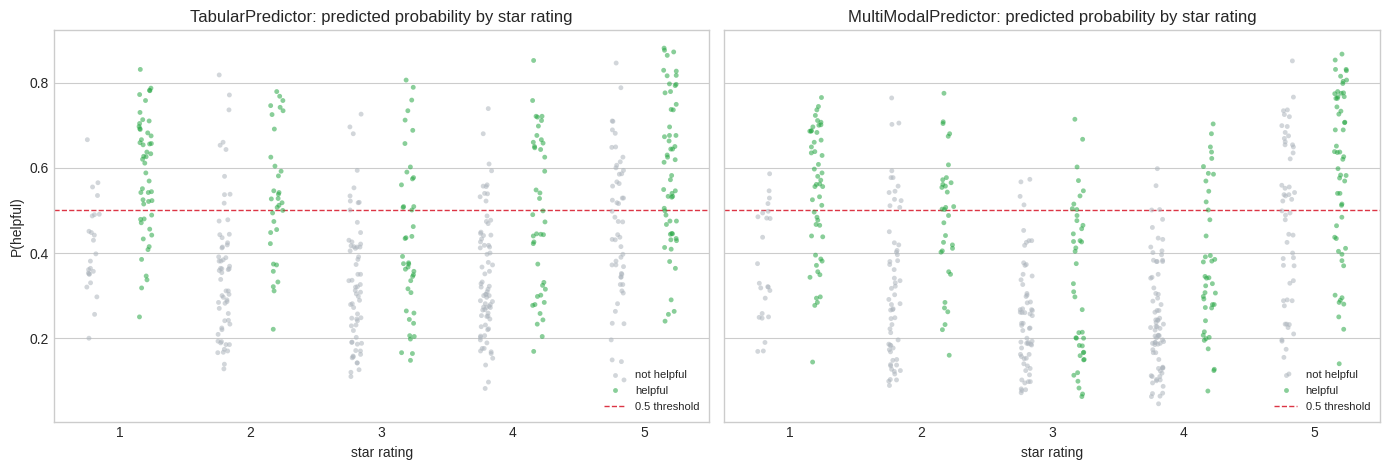

Each dot is one test review; colour is the true label, height is the model's probability.


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, col, ttl in [(axes[0], "P(helpful) tabular", "TabularPredictor"), (axes[1], "P(helpful) multimodal", rv_mm_name.split(" (")[0])]:
    sns.stripplot(data=rv_out, x="star_rating", y=col, hue="helpful", palette={0: "#adb5bd", 1: "#28a745"}, dodge=True, alpha=0.55, size=3.5, ax=ax)
    ax.axhline(0.5, color="#dc3545", ls="--", lw=1, label="0.5 threshold")
    ax.set_title(f"{ttl}: predicted probability by star rating"); ax.set_xlabel("star rating"); ax.set_ylabel("P(helpful)")
    h, l = ax.get_legend_handles_labels(); ax.legend(h, ["not helpful", "helpful", "0.5 threshold"], loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()
print("Each dot is one test review; colour is the true label, height is the model's probability.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each dot is one test review, placed at its star rating and lifted to the model's probability that it is helpful; green dots are truly helpful reviews, grey ones are not. A good model separates the colours *within* each star column: at three stars, where the rating says nothing, the green dots should still sit higher than the grey ones, because the model read the detail sentences. Where the two colours mix at the same height the text did not help; where the columns are tilted (one and five stars high, three stars low) the model is repeating the U-shape from 8.2.

The common misread: reading the vertical spread inside a column as noise. It is the text signal; a model using only the star rating would draw one flat line per column.

</div>

In [55]:
top = rv_out.sort_values("P(helpful) multimodal", ascending=False)
print(f"=== 5 reviews {rv_mm_name.split(' (')[0]} is most sure are helpful ===")
for _, r in top.head(5).iterrows():
    print(f"  P={r['P(helpful) multimodal']:.2f} (true {r.helpful}) {r.star_rating}★ | {r.review_text[:150]}")
print(f"\n=== 5 reviews it is most sure are NOT helpful ===")
for _, r in top.tail(5).iterrows():
    print(f"  P={r['P(helpful) multimodal']:.2f} (true {r.helpful}) {r.star_rating}★ | {r.review_text[:150]}")
top_words = top.head(50).review_text.str.split().str.len().mean(); bot_words = top.tail(50).review_text.str.split().str.len().mean()
print(f"\nmean words in the 50 most confident 'helpful': {top_words:.0f}  vs  50 most confident 'not helpful': {bot_words:.0f}")


=== 5 reviews MultiModalPredictor is most sure are helpful ===
  P=0.87 (true 1) 5★ | Absolutely love this smart speaker; it exceeded every expectation I had. Battery lasted about 12 hours on a full charge, which matches the box. It wei
  P=0.85 (true 1) 5★ | This backpack is the best purchase I made this year. I compared it against two other models before buying and this one had the better warranty. Batter
  P=0.85 (true 0) 5★ | Absolutely love this desk lamp; it exceeded every expectation I had. Battery lasted about 5 hours on a full charge, which matches the box. Delivery to
  P=0.83 (true 1) 5★ | I have used the desk lamp every day for a month and it still works like new. I compared it against two other models before buying and this one had the
  P=0.83 (true 1) 5★ | This office chair is the best purchase I made this year. The cable is 2 metres long, enough to reach across a desk. Battery lasted about 10 hours on a

=== 5 reviews it is most sure are NOT helpful ===
  P=0.07 (true 1

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The top five read like product research: numbers, comparisons, a delivery fact, a firm verdict. The bottom five are short and vague ("Meh.", "It is what it is."). The word-count contrast printed last is the model's rule in one number. This is the check to run on any text model before shipping it: **read the extremes**. If the most confident predictions do not make sense to a human, the model has found a shortcut (a product name, a template artefact) rather than the meaning.

The common misread: taking a sensible top five as proof the model is right everywhere. The extremes are the easy cases; the report card's ROC-AUC is the score on all of them, including the middle.

</div>

## 8.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Text next to numbers

- **Reach for `TabularPredictor` first** whenever a table has a free-text column. It costs nothing extra: text statistics and n-gram counts are generated automatically, every model in the zoo uses them, and the fit is as fast as Part 1. On short or templated text it is usually all you need.
- **Reach for `MultiModalPredictor`** when the text is long, varied, or the *meaning* matters beyond keyword presence (sarcasm, negation, context), or when the text is the only column. It costs a checkpoint download, minutes instead of seconds on a CPU, and a GPU for anything past a few thousand rows.
- **The one gotcha:** both paths depend on the column being *typed* as text. Check `feature_metadata_in` (tabular) or `predictor.column_types` (multimodal) before believing that a text column was used.

</div>

## 8.7 Task 8 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- The Part 1 call handles text: `TabularPredictor` types a many-valued string column as `text` and expands it into statistics and n-gram counts, visible in `feature_metadata`.
- `MultiModalPredictor` fine-tunes a transformer branch with tabular MLPs; on a CPU, pin a tiny checkpoint, cap the epochs, and expect the download to cost more than the training.
- Compare on the same test rows with the same report card; on short templated text the gap is hundredths, and the cheaper path wins.
- Read the most and least confident reviews before trusting any text model.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `reviews`, `rv_train`, `rv_test` | the 2,000 generated reviews and their stratified split |
| `rv_tab`, `rv_tab_lb`, `rv_tab_proba` | the tabular predictor, its leaderboard and test probabilities |
| `rv_mm_ok`, `rv_mm_hp`, `rv_mm_proba`, `rv_mm_name` | whether the multimodal fit ran, its settings, and the test probabilities of whichever path ran |
| `rv_cards`, `rv_out` | the two report cards and the per-review probability table |

### ➡️ Next Up

Part 8 swaps the text column for a column of **image paths**: the same `MultiModalPredictor`, a vision backbone, and product photos with three kinds of surface defect.

</div>

# Part 8 · Images · Defect Photos ⭐⭐⭐

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### A column of file paths

An image column in AutoGluon is a column of **paths** to image files. That is the whole input contract: a DataFrame with a path column and a label column. `MultiModalPredictor` reads the files, resizes them, and fine-tunes a pretrained vision backbone from the `timm` library. This Part manufactures six hundred small product-surface photos with three kinds of defect, writes them to disk as PNGs, and runs the same three lines as every other Part.

</div>

# Task 9 · Which Photos Show a Defect?

## 9.1 ❓ The problem

A factory line photographs every product surface before packing. The quality team asks: **from the photo, is this surface fine, scratched, or dented?** A good answer replaces a manual inspection step, and the per-class probabilities let the line send only the uncertain ones to a human. The input is a photo; the output is a class and three probabilities.

## 9.2 📥 The input

`make_defect_images` draws 64×64 grayscale surfaces: a soft texture with sensor noise for `ok`, a bright straight line at a random angle for `scratch`, and a dark round dip for `dent`. The images are saved as PNG files under `WORK/images/`, and the DataFrame holds only the path and the label. That is deliberately what a real dataset looks like: the pixels stay on disk.

In [56]:
from PIL import Image

def make_defect_images(n=600, size=64, seed=RANDOM_STATE, out_dir=None):
    # Synthetic product-surface photos: ok (texture + noise), scratch (bright line), dent (dark blob). Saved as PNGs.
    rng = np.random.default_rng(seed)
    out_dir = out_dir or os.path.join(WORK, "images"); os.makedirs(out_dir, exist_ok=True)
    yy, xx = np.mgrid[:size, :size]
    rows = []
    for i in range(n):
        label = ["ok", "scratch", "dent"][int(rng.choice(3, p=[0.5, 0.25, 0.25]))]
        base = 120 + rng.uniform(-20, 20)
        img = base + 8 * np.sin(xx / rng.uniform(6, 14) + rng.uniform(0, 6)) + 6 * np.cos(yy / rng.uniform(6, 14)) + rng.normal(0, 10, (size, size))
        if label == "scratch":
            r0, c0 = rng.integers(10, size - 10, 2); ang = rng.uniform(0, np.pi); width = rng.uniform(0.6, 1.4)
            dist = np.abs((xx - c0) * np.sin(ang) - (yy - r0) * np.cos(ang))
            along = np.abs((xx - c0) * np.cos(ang) + (yy - r0) * np.sin(ang))
            img += (110 * np.exp(-dist**2 / (2 * width**2))) * (along < rng.uniform(14, 28))
        elif label == "dent":
            r0, c0 = rng.integers(12, size - 12, 2); rad = rng.uniform(3.5, 7)
            img -= 85 * np.exp(-((yy - r0)**2 + (xx - c0)**2) / (2 * rad**2))
        path = os.path.join(out_dir, f"surface_{i:04d}.png")
        Image.fromarray(np.clip(img, 0, 255).astype(np.uint8), mode="L").save(path)
        rows.append({"image": path, "label": label})
    return pd.DataFrame(rows)

defects = make_defect_images(600)
df_train, df_test = train_test_split(defects, test_size=0.2, random_state=RANDOM_STATE, stratify=defects["label"])
show_input(defects.assign(image=defects.image.map(os.path.basename)), label="label", name="defect photos")
print(f"\nfiles written under {os.path.join(WORK, 'images')}: {len(os.listdir(os.path.join(WORK, 'images')))} PNGs, "
      f"{sum(os.path.getsize(p) for p in defects.image) / 1024:.0f} KB total | train {len(df_train)} / test {len(df_test)}")


📥 defect photos: 600 rows x 2 columns | label = 'label'


,image,label
0,surface_0000.png,dent
1,surface_0001.png,ok
2,surface_0002.png,dent
3,surface_0003.png,ok
4,surface_0004.png,dent


column types: {'image': 'text/category', 'label': 'text/category'}
label distribution: {'ok': 0.502, 'dent': 0.25, 'scratch': 0.248}

files written under /tmp/images: 600 PNGs, 1858 KB total | train 480 / test 120


| Column | Type | Meaning |
|---|---|---|
| `image` | image path | the PNG file on disk (64×64 grayscale) |
| `label` | **label**, 3 classes | `ok`, `scratch`, `dent` |

`MultiModalPredictor` infers `image` as an **image path** column because every value is a string that points to an existing image file; the fit cell below also states it with `column_types` so the inference is never in doubt. The label has three values, so the problem type is `multiclass`.

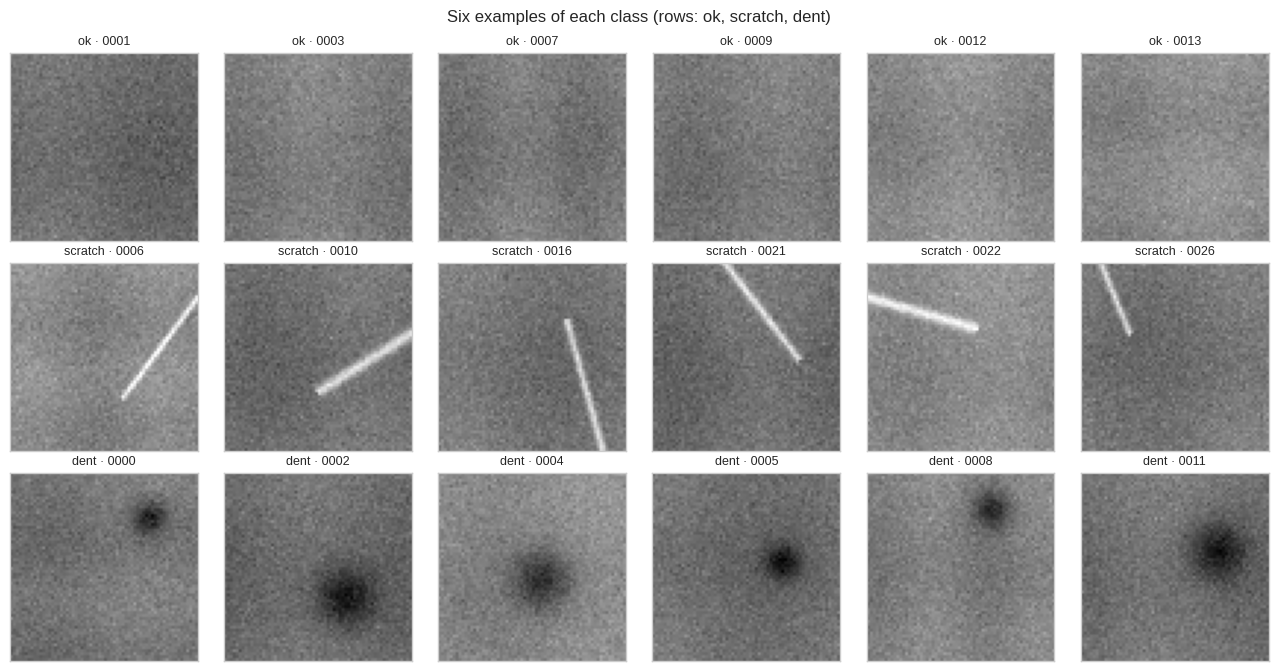

mean pixel by class: {'dent': 115.4, 'ok': 120.3, 'scratch': 121.8}
max pixel by class:  {'dent': 162.9, 'ok': 163.2, 'scratch': 245.7}


In [57]:
fig, axes = plt.subplots(3, 6, figsize=(13, 6.8))
for row, lab in enumerate(["ok", "scratch", "dent"]):
    for col, (_, r) in enumerate(defects[defects.label == lab].head(6).iterrows()):
        ax = axes[row, col]; ax.imshow(np.asarray(Image.open(r.image)), cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"{lab} · {os.path.basename(r.image)[8:12]}", fontsize=9); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Six examples of each class (rows: ok, scratch, dent)"); plt.tight_layout(); plt.show()
px = np.stack([np.asarray(Image.open(p), dtype=float) for p in defects.image])
print("mean pixel by class:", defects.assign(mean=px.mean(axis=(1, 2))).groupby("label")["mean"].mean().round(1).to_dict())
print("max pixel by class: ", defects.assign(mx=px.max(axis=(1, 2))).groupby("label")["mx"].mean().round(1).to_dict())


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Top row: clean surfaces, a faint wave texture under grain. Middle: the same surfaces with one bright line, at any angle and any place. Bottom: a dark dip somewhere on the surface. The two summary numbers show why this is a real vision problem and not a threshold: the mean brightness barely moves between classes (the defects are small), and only the maximum pixel separates scratches from the rest. A dent shifts neither; it has to be found by its *shape*, which is what convolution filters do.

The common misread: thinking synthetic images make the task trivial. The line's angle and position and the dent's location vary freely, so a model that memorises pixel positions fails; it must learn the pattern wherever it appears, which is exactly the property a pretrained backbone brings.

</div>

## 9.3 💻 Three lines

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔬 Transfer learning from a `timm` backbone

`MultiModalPredictor` with an image column loads a convolutional or transformer backbone pretrained on ImageNet from the **timm** model zoo and fine-tunes it on your labels. The default backbone is a Swin transformer (`swin_base_patch4_window7_224`, about ninety million parameters, meant for a GPU). The cell below names `mobilenetv3_small_100` instead: a mobile-phone-class network of a few million parameters that trains on a CPU in well under a minute. `model.timm_image.image_size` is set to 64 so the tiny photos are not upscaled to 224 pixels, which would make every step twelve times more expensive for no information gain.

**Online**, Colab downloads the backbone weights once from the HuggingFace Hub. **Offline**, the `except` branch trains `HistGradientBoostingClassifier` on hand-made features: the image downsampled to 16×16 plus a few edge statistics (gradient magnitude mean and maximum, darkest and brightest pixel). It is the model a practitioner would try first without deep learning, and it produces the same probability table and figures.

</div>

In [58]:
from sklearn.ensemble import HistGradientBoostingClassifier
DEFECT_CLASSES = ["ok", "scratch", "dent"]

def pixel_features(paths, side=16):
    # Fallback features: a 16x16 thumbnail + edge statistics (gradient mean/max, darkest and brightest pixel, std).
    feats = []
    for p in paths:
        a = np.asarray(Image.open(p), dtype=float)
        gy, gx = np.gradient(a); g = np.hypot(gx, gy)
        thumb = np.asarray(Image.open(p).resize((side, side), Image.BILINEAR), dtype=float).ravel()
        feats.append(np.concatenate([thumb, [g.mean(), g.max(), np.percentile(g, 99), a.min(), a.max(), a.std()]]))
    return np.array(feats)

df_mm_hp = {"model.names": ["timm_image"], "model.timm_image.checkpoint_name": "mobilenetv3_small_100",
            "model.timm_image.image_size": 64, "optim.max_epochs": 3,
            "env.num_gpus": 1 if GPU else 0, "env.precision": "16-mixed" if GPU else 32,
            "env.num_workers": 0, "env.num_workers_inference": 0, "env.batch_size": 32, "env.per_gpu_batch_size": 32}
df_mm_ok, df_mm_note = False, ""
_prev = torch.get_num_threads(); torch.set_num_threads(N_CPUS)
try:
    if not MM_OK:
        raise ImportError("autogluon.multimodal did not import in Part 0")
    with timer("MultiModalPredictor.fit (mobilenetv3_small_100, 3 epochs)"):
        df_mm = MultiModalPredictor(label="label", path=os.path.join(WORK, "part8_mm"), verbosity=0, enable_progress_bar=False)
        df_mm.fit(df_train, column_types={"image": "image_path"}, hyperparameters=df_mm_hp, time_limit=120, seed=RANDOM_STATE)
    print(f"problem type inferred: {df_mm.problem_type} | eval metric: {df_mm.eval_metric} | column types: {dict(df_mm.column_types)}")
    with timer("predict_proba on the test photos"):
        df_proba = df_mm.predict_proba(df_test)[DEFECT_CLASSES].reset_index(drop=True)
    df_mm_ok, df_mm_name = True, "MultiModalPredictor (mobilenetv3_small_100)"
except Exception as e:  # noqa: BLE001 - offline or no backbone: gradient boosting on pixel features runs instead
    df_mm_note = f"{type(e).__name__}: {str(e)[:140]}"
    print("MultiModalPredictor did not run ->", df_mm_note)
    print("Online, Colab downloads mobilenetv3_small_100 and fine-tunes it; this session trains gradient boosting on 16x16 thumbnails + edge features instead.")
    with timer("fallback: HistGradientBoosting on pixel features"):
        df_fb = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.1, random_state=RANDOM_STATE)
        df_fb.fit(pixel_features(df_train.image), df_train.label)
    df_proba = pd.DataFrame(df_fb.predict_proba(pixel_features(df_test.image)), columns=df_fb.classes_)[DEFECT_CLASSES]
    df_mm_name = "Fallback: HistGradientBoosting on pixels"
finally:
    torch.set_num_threads(_prev)
df_pred = df_proba.idxmax(axis=1).values
print(f"df_mm_ok = {df_mm_ok} | test accuracy: {(df_pred == df_test.label.values).mean():.3f}")


INFO: Seed set to 42


model.safetensors: reconstructing file:   0%|          |  0.00B / 10.2MB            

model.safetensors: downloading bytes:           |  0.00B            

⏱️ MultiModalPredictor.fit (mobilenetv3_small_100, 3 epochs): 18.0 s
problem type inferred: multiclass | eval metric: accuracy | column types: {'image': 'image_path', 'label': 'categorical'}
⏱️ predict_proba on the test photos: 0.4 s
df_mm_ok = True | test accuracy: 0.792


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Three epochs is a demonstration budget, and the GPU is what changes it

`optim.max_epochs=3` on a few hundred images is enough to show the mechanism, not to reach the accuracy a production model would. The printed fit time is the cost of the whole loop on a CPU; on a Colab T4 the same cell is several times faster and `max_epochs` can go to 10-20, with a larger backbone (`resnet50`, `convnext_tiny`, or the Swin default), at no change to the code. Watch the accuracy above against the 50% majority-class baseline: if it is not far above it, the model has not converged, not "failed". And if the fallback ran, do not be surprised when it scores as high or higher: on clean synthetic surfaces the darkest-pixel and brightest-pixel features are nearly perfect detectors. Real photos, with lighting, texture and camera variation, are where a pretrained backbone earns its keep and hand-made features stop working.

</div>

## 9.4 📤 The output

`predict_proba` returns one column per class, in the order the predictor stored them; the argmax is the predicted label. For the six photos below the three probabilities are shown next to the truth, then a per-class precision/recall table, so the number that matters to the factory (how many dents slip through as `ok`) is visible.

In [59]:
from sklearn.metrics import classification_report, confusion_matrix
df_out = pd.DataFrame({"file": df_test.image.map(os.path.basename).values, "true": df_test.label.values, "predicted": df_pred})
df_out[[f"P({c})" for c in DEFECT_CLASSES]] = df_proba.values.round(3)
display(pretty(df_out.head(6).set_index("file"), subset=[f"P({c})" for c in DEFECT_CLASSES]))

df_report = pd.DataFrame(classification_report(df_test.label, df_pred, labels=DEFECT_CLASSES, output_dict=True, zero_division=0)).T
df_report = df_report.loc[DEFECT_CLASSES + ["macro avg"]].rename(columns={"support": "n"})
display(pretty(df_report, subset=["precision", "recall", "f1-score"]))
print(df_report.round(3).to_string())
df_score = pd.DataFrame({"model": [df_mm_name], "accuracy": [(df_pred == df_test.label.values).mean()],
                         "macro_f1": [df_report.loc["macro avg", "f1-score"]], "majority baseline": [df_test.label.value_counts(normalize=True).max()]}).set_index("model")
print("\n" + df_score.round(3).to_string())


ValueError: Unknown format code 'f' for object of type 'str'

,precision,recall,f1-score,n
ok,0.878,0.717,0.789,60.000
scratch,0.686,0.800,0.738,30.000
dent,0.778,0.933,0.848,30.000
macro avg,0.780,0.817,0.792,120.000


           precision  recall  f1-score      n
ok             0.878   0.717     0.789   60.0
scratch        0.686   0.800     0.738   30.0
dent           0.778   0.933     0.848   30.0
macro avg      0.780   0.817     0.792  120.0

                                             accuracy  macro_f1  majority baseline
model                                                                             
MultiModalPredictor (mobilenetv3_small_100)     0.792     0.792                0.5


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Reading a multiclass output

The probability rows sum to one across the three classes. A row like `P(ok)=0.55, P(dent)=0.40` is a photo the line should route to a human, whichever class wins; a threshold on the *top* probability is the simplest triage rule. In the per-class table, **recall** on `dent` and `scratch` is the factory's number: it is the share of real defects the model caught. **Precision** on `ok` is the same fact from the other side: of the surfaces the model waved through, how many were really fine. Macro-F1 averages the three classes equally, so the rarer defect classes count as much as `ok`.

</div>

## 9.5 📊 The picture

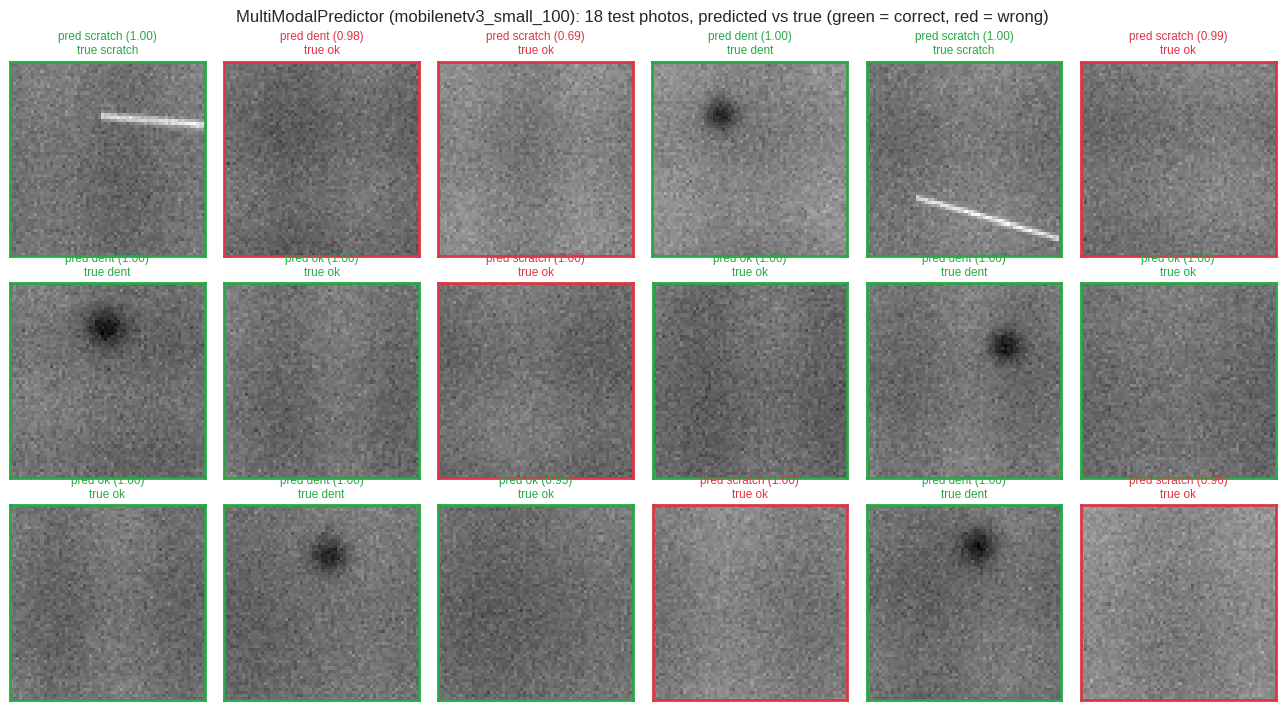

wrong in this grid: 6 of 18 | wrong on the whole test set: 25 of 120


In [60]:
show = df_test.reset_index(drop=True).iloc[:18]
fig, axes = plt.subplots(3, 6, figsize=(13, 7.2))
for ax, (i, r) in zip(axes.ravel(), show.iterrows()):
    ax.imshow(np.asarray(Image.open(r.image)), cmap="gray", vmin=0, vmax=255)
    ok = df_pred[i] == r.label
    ax.set_title(f"pred {df_pred[i]} ({df_proba.iloc[i].max():.2f})\ntrue {r.label}", fontsize=8.5, color="#28a745" if ok else "#dc3545")
    for s in ax.spines.values(): s.set_edgecolor("#28a745" if ok else "#dc3545"); s.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f"{df_mm_name}: 18 test photos, predicted vs true (green = correct, red = wrong)"); plt.tight_layout(); plt.show()
wrong = int((df_pred[:18] != show.label.values).sum())
print(f"wrong in this grid: {wrong} of 18 | wrong on the whole test set: {int((df_pred != df_test.label.values).sum())} of {len(df_test)}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each tile is one test photo with the predicted class and the model's confidence in it above the true class; a green frame is a hit, a red one a miss. The red tiles are the ones to study: which class was mistaken for which, and whether the defect in them is faint, short, or near the edge, which is what a small model trained for three epochs on a small set gets wrong first. Compare the confidence printed on the misses with the confidence on the hits: when the misses are the less confident ones, the triage rule in 9.4 works.

The common misread: judging the model on eighteen tiles. The grid is for seeing *what kind* of mistake it makes; the count over the whole test set, printed underneath, is the measure of how often.

</div>

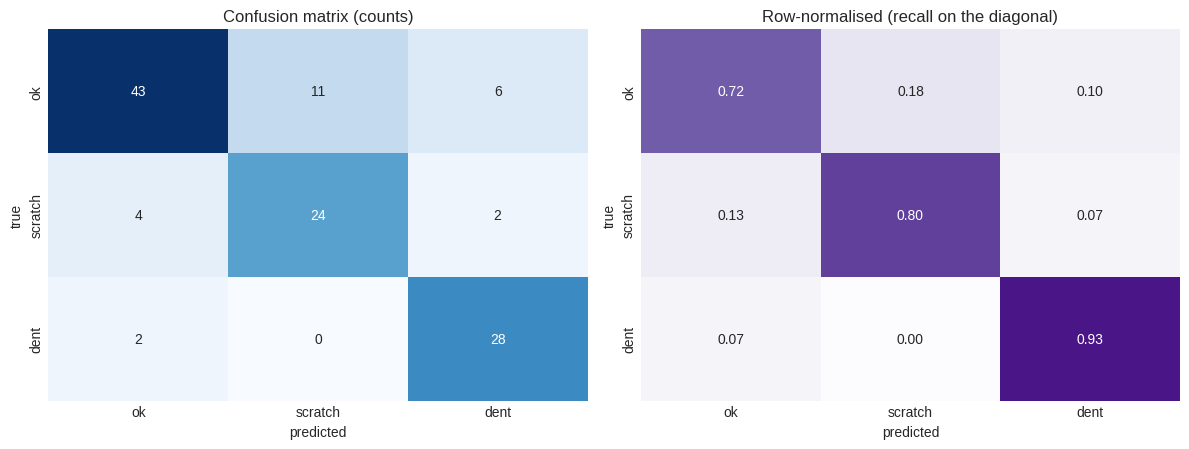

defects called 'ok' (the expensive miss): 6 of 60 real defects | ok surfaces flagged as defect: 17 of 60


In [61]:
cm = confusion_matrix(df_test.label, df_pred, labels=DEFECT_CLASSES)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=DEFECT_CLASSES, yticklabels=DEFECT_CLASSES, ax=axes[0], cbar=False)
axes[0].set_title("Confusion matrix (counts)"); axes[0].set_xlabel("predicted"); axes[0].set_ylabel("true")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Purples", vmin=0, vmax=1, xticklabels=DEFECT_CLASSES, yticklabels=DEFECT_CLASSES, ax=axes[1], cbar=False)
axes[1].set_title("Row-normalised (recall on the diagonal)"); axes[1].set_xlabel("predicted"); axes[1].set_ylabel("true")
plt.tight_layout(); plt.show()
missed_defects = cm[1:, 0].sum()
print(f"defects called 'ok' (the expensive miss): {missed_defects} of {cm[1:].sum()} real defects | ok surfaces flagged as defect: {cm[0, 1:].sum()} of {cm[0].sum()}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: raw counts, rows are the truth and columns the prediction. Right: each row divided by its total, so the diagonal reads as recall per class. The cell that costs the factory money is the first column of the defect rows: a real scratch or dent waved through as `ok`. The printed sentence isolates that number. The mirror cell (an `ok` surface flagged) costs an inspector's minute, which is cheap; if the two are unbalanced in the wrong direction, lower the probability the model needs before it says `ok`, rather than retraining.

The common misread: reading the row-normalised matrix as if the classes were the same size. `ok` is half the data, so the same recall on `ok` and on `dent` represents twice as many photos.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: fix the expensive cell with a threshold before retraining

The "defects called `ok`" count printed above is the number to drive down, and the first lever to try is not more epochs: require `P(ok)` above a chosen level (say 0.8) before the line accepts a surface, and send everything else to an inspector. The cell below computes the trade-off on the test set from `df_proba` alone: for each threshold, the defects still waved through and the `ok` surfaces sent to the inspector. Pick the threshold whose inspector load the line can afford; it is the same cost-curve idea Part 5 used for fraud, with no training. Retrain only when no threshold gives an acceptable pair.

</div>

In [62]:
is_defect = (df_test.label.values != "ok")
rows = []
for thr in [0.34, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]:
    accept = df_proba["ok"].values >= thr                       # the line accepts a surface only if P(ok) clears the bar
    rows.append({"P(ok) threshold": thr, "accepted": int(accept.sum()), "defects waved through": int((accept & is_defect).sum()),
                 "ok sent to inspector": int((~accept & ~is_defect).sum()), "inspector load": float((~accept).mean())})
thr_table = pd.DataFrame(rows).set_index("P(ok) threshold")
print(thr_table.to_string())
safe = thr_table[thr_table["defects waved through"] == 0]
if len(safe):
    print(f"\nlowest threshold with zero defects waved through: {safe.index.min()} (inspector load {safe['inspector load'].min():.0%})")
else:
    conf = df_proba["ok"].values[is_defect].max()
    print(f"\nno threshold in this grid catches every defect: the most confident miss has P(ok) = {conf:.3f}; a threshold cannot fix confident misses, more training can")


                 accepted  defects waved through  ok sent to inspector  inspector load
P(ok) threshold                                                                       
0.34                   50                      6                    16        0.583333
0.50                   49                      6                    17        0.591667
0.70                   48                      6                    18        0.600000
0.80                   46                      6                    20        0.616667
0.90                   45                      6                    21        0.625000
0.95                   44                      5                    21        0.633333
0.99                   39                      3                    24        0.675000

no threshold in this grid catches every defect: the most confident miss has P(ok) = 1.000; a threshold cannot fix confident misses, more training can


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Reading the threshold table

The first row (threshold 0.34, just above one third) is the plain argmax rule from the confusion matrix. Each row down raises the bar for `ok`: fewer defects should slip through, and more clean surfaces go to a person. Two outcomes are possible, and the last printed line says which one this run produced. If a threshold catches every defect, its inspector load is the price, and whether that price is acceptable is a business decision the probabilities let you make without touching the training code. If the "defects waved through" column stays flat all the way to 0.99, the misses are **confident** misses: the model assigns `ok` a probability above 0.99 to a real defect, and no threshold can separate what the model cannot see. That is the signal to train longer, add data, or use a larger backbone, and it is why the table is worth printing before spending any of those.

</div>

## 9.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Images with labels

- **Reach for `MultiModalPredictor`** when you have a folder of images and a label per image (or a label per row that also has text and numbers: the image column can sit next to them). Transfer learning from a `timm` backbone means a few hundred images per class are often enough for a strong first model; a few dozen can work with a frozen backbone.
- **What it costs:** a checkpoint download, and a GPU for anything beyond a demonstration. On a CPU keep the backbone small and the image size honest, as above; on a T4 the same code trains a serious model in minutes.
- **The one gotcha:** the images stay on disk and the DataFrame holds paths, so the paths must resolve on the machine that runs `predict`. Save the predictor together with a folder layout you can reproduce, or use relative paths from a fixed root.

</div>

## 9.7 Task 9 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- The image input contract is a column of file paths plus a label column; `column_types={"image": "image_path"}` states it explicitly.
- `MultiModalPredictor` fine-tunes a pretrained `timm` backbone; name a small one (`mobilenetv3_small_100`) and set `model.timm_image.image_size` to the real image size to keep a CPU fit under a minute.
- `predict_proba` gives one column per class; the top probability is the triage signal, and the confusion matrix's "defect called ok" cell is the business cost.
- The offline fallback (gradient boosting on thumbnails and edge statistics) is the honest pre-deep-learning baseline and produces the same tables and pictures.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `defects`, `df_train`, `df_test` | the path + label DataFrame for 600 PNGs under `WORK/images/`, and its split |
| `df_mm_ok`, `df_mm_hp`, `df_mm_name` | whether the vision fit ran, its settings, and the name of the path that ran |
| `df_proba`, `df_pred`, `df_out` | per-class probabilities, predicted labels, and the table joining them to the truth |
| `df_report`, `df_score`, `cm` | per-class precision/recall/F1, the one-row score table, and the confusion matrix |
| `pixel_features` | the thumbnail + edge feature extractor used by the fallback |

### ➡️ Next Up

Part 9 stops predicting labels altogether: the same `MultiModalPredictor` turns support tickets into **embedding vectors**, and those vectors power search, clustering and routing without a single label.

</div>

# Part 9 · Embeddings and Semantic Search · Support Tickets ⭐⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### No label, no training loop, and still useful

Every Part so far ended with a prediction. Part 9 ends with a **vector**: a list of a few hundred numbers that describes what a ticket *means*, produced by a pretrained language model without any fine-tuning. Two tickets that say the same thing in different words get vectors that point in the same direction. That one property powers search ("find tickets like this one"), de-duplication, clustering and routing, and the vectors are computed once and reused for all of them.

</div>

# Task 10 · Find Me Tickets Like This One

## 10.1 ❓ The problem

A support desk receives hundreds of tickets a day in free text. The team lead asks two things: **when a new ticket arrives, which past tickets are about the same problem** (so the agent can reuse the answer), and **what are the main kinds of ticket** (so they can be routed to the right queue). No one has labelled the backlog. Keyword search fails because "charged twice" and "double billing" share no words.

## 10.2 📥 The input

`make_tickets` writes tickets about five hidden topics (billing, login, shipping, bug, feature request), each from a bank of paraphrases with different vocabulary, so that tickets on the same topic often share no keywords. The `topic` column is kept **only for evaluation**: nothing in this Part trains on it.

In [63]:
def make_tickets(n=800, seed=RANDOM_STATE):
    # Support tickets from paraphrase banks: five hidden topics, varied wording, a slot-filled detail. `topic` is for evaluation only.
    rng = np.random.default_rng(seed)
    banks = {
        "billing": ["I was charged twice for my {plan} subscription this month.", "My invoice shows a double payment of {amt} dollars.",
                    "Why did the price go up to {amt} without any notice?", "Please refund the duplicate charge on my card ending {num}.",
                    "The receipt I received does not match what my bank statement says.", "I cancelled in {month} but you still billed me {amt} dollars.",
                    "Can I switch from annual to monthly billing on the {plan} plan?", "Your payment page declined my card but the money left my account."],
        "login": ["I cannot sign in, the password reset link expired after {mins} minutes.", "Two-factor codes never arrive on my phone ending {num}.",
                  "My account is locked after too many attempts, how do I get back in?", "The login page keeps spinning and then returns me to the start.",
                  "I changed my email in {month} and now none of my credentials work.", "Single sign-on with my company account fails with an unknown error.",
                  "I forgot which email I registered with, can you look up my account?", "The app logs me out every {mins} minutes for no reason."],
        "shipping": ["My order {num} was marked delivered but nothing arrived.", "The tracking page has not updated since {month} {day}.",
                     "Can you change the delivery address on order {num} before it ships?", "The package arrived damaged and one of the items is missing.",
                     "It has been {days} days and the parcel is still in transit.", "I need the order shipped to a different country, is that possible?",
                     "The courier left the box with a neighbour who I do not know.", "When will order {num} leave the warehouse?"],
        "bug": ["The export button crashes the app when the report has more than {num} rows.", "Dark mode makes the chart labels invisible on the dashboard.",
                "After the {month} update the search results are sorted wrong.", "Uploading a file larger than {amt} MB fails with a blank error.",
                "The mobile app freezes on the settings screen every time.", "Dates in the CSV download are off by one day.",
                "Notifications show a count of {num} but the list is empty.", "The page shows a blank screen after I click save on a long form."],
        "feature": ["Could you add a way to export the dashboard as a PDF?", "It would help to have a dark theme for the editor.",
                    "Please consider adding keyboard shortcuts for the most common actions.", "A weekly summary email would save me a lot of time.",
                    "Is there any plan to support {num} team members on the {plan} plan?", "I would love an integration with my calendar app.",
                    "Can we get a bulk edit option for tags?", "An offline mode for the mobile app would be great."]}
    openers = ["Hi,", "Hello there,", "Hi team,", "Good morning,", "", "", "Hey,", "To whom it may concern,"]
    closers = ["Thanks.", "Any help appreciated.", "Please advise.", "", "", "Regards.", "Let me know.", "Thank you in advance."]
    rows = []
    for _ in range(n):
        topic = str(rng.choice(list(banks), p=[0.26, 0.22, 0.2, 0.18, 0.14]))
        fill = dict(plan=rng.choice(["basic", "pro", "team"]), amt=int(rng.integers(9, 250)), num=int(rng.integers(1000, 9999)),
                    month=rng.choice(["January", "March", "June", "August", "October"]), day=int(rng.integers(1, 28)),
                    mins=int(rng.integers(5, 60)), days=int(rng.integers(3, 21)))
        body = rng.choice(banks[topic]).format(**fill)
        text = " ".join(t for t in [rng.choice(openers), body, rng.choice(closers)] if t)
        rows.append({"ticket_text": text, "topic": topic})
    return pd.DataFrame(rows)

tickets = make_tickets(800)
TOPICS = ["billing", "login", "shipping", "bug", "feature"]
show_input(tickets, label="topic", name="support tickets")
print(f"\ndistinct ticket texts: {tickets.ticket_text.nunique()} of {len(tickets)} | words per ticket: mean {tickets.ticket_text.str.split().str.len().mean():.1f}")
for t in TOPICS:
    print(f"  [{t:<8s}] {tickets[tickets.topic == t].ticket_text.iloc[0]}")


📥 support tickets: 800 rows x 2 columns | label = 'topic'


,ticket_text,topic
0,The export button crashes the app when the report has more than 4896 rows. Thank you in advance.,bug
1,"Hello there, After the January update the search results are sorted wrong. Thank you in advance.",bug
2,"To whom it may concern, It has been 4 days and the parcel is still in transit. Thanks.",shipping
3,"Good morning, The page shows a blank screen after I click save on a long form. Thank you in advance.",bug
4,Dark mode makes the chart labels invisible on the dashboard. Regards.,bug


column types: {'ticket_text': 'text/category', 'topic': 'text/category'}
label distribution: {'billing': 0.276, 'login': 0.211, 'shipping': 0.191, 'bug': 0.171, 'feature': 0.15}

distinct ticket texts: 715 of 800 | words per ticket: mean 14.5
  [billing ] Hello there, Please refund the duplicate charge on my card ending 3971. Let me know.
  [login   ] Good morning, The app logs me out every 57 minutes for no reason. Regards.
  [shipping] To whom it may concern, It has been 4 days and the parcel is still in transit. Thanks.
  [bug     ] The export button crashes the app when the report has more than 4896 rows. Thank you in advance.
  [feature ] Hi team, Can we get a bulk edit option for tags? Regards.


| Column | Type | Meaning |
|---|---|---|
| `ticket_text` | text | the ticket as the customer wrote it |
| `topic` | hidden label, 5 values | used only to score the search and the clusters |

There is no label column in the call below, so AutoGluon does not infer a problem type from the data: the problem type is stated as `feature_extraction`, which tells `MultiModalPredictor` to load a pretrained **sentence-embedding** model and skip training altogether.

## 10.3 💻 Three lines

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 What an embedding is

A sentence-embedding model reads a text and returns a fixed-length vector, here 384 numbers. It was trained on millions of sentence pairs so that paraphrases land close together and unrelated sentences far apart, measured by **cosine similarity**: the cosine of the angle between two vectors, 1 for the same direction, 0 for unrelated. Once every ticket is a vector, "find similar tickets" is a dot product, "group tickets" is K-means, and "route a ticket" is a nearest-centroid lookup. No labels, no fitting.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔬 `problem_type="feature_extraction"` and `extract_embedding`

`MultiModalPredictor(problem_type="feature_extraction")` is one of the problem types that runs **without `fit`**: it loads the checkpoint and is ready to embed. Its default checkpoint is a twelve-layer MiniLM; the cell names the six-layer `sentence-transformers/all-MiniLM-L6-v2` (about twenty-two million parameters, 384-dimensional output, mean pooling), which embeds the whole backlog on a CPU in seconds. `extract_embedding(df)` returns a dict with one array per text column.

**Online**, Colab downloads that checkpoint once from the HuggingFace Hub. **Offline**, the `except` branch builds the classical stand-in: TF-IDF word counts reduced to one hundred dimensions with a truncated SVD (**latent semantic analysis**) and normalised to unit length. It is weaker on paraphrases, because it can only relate words that co-occur in this corpus, but it produces the same matrix shape and every cell below runs on either.

</div>

In [64]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
assert "problem_type" in inspect.signature(MultiModalPredictor.__init__).parameters and hasattr(MultiModalPredictor, "extract_embedding")

tk_ok, tk_note = False, ""
_prev = torch.get_num_threads(); torch.set_num_threads(N_CPUS)
try:
    if not MM_OK:
        raise ImportError("autogluon.multimodal did not import in Part 0")
    with timer("load the sentence-embedding model + embed 800 tickets"):
        tk_mm = MultiModalPredictor(problem_type="feature_extraction", path=os.path.join(WORK, "part9_mm"), verbosity=0, enable_progress_bar=False,
                                    hyperparameters={"model.hf_text.checkpoint_name": "sentence-transformers/all-MiniLM-L6-v2", "model.hf_text.pooling_mode": "mean",
                                                     "env.num_gpus": 1 if GPU else 0, "env.num_workers_inference": 0})
        tk_raw = tk_mm.extract_embedding(tickets[["ticket_text"]])          # dict: {column name -> (n, d) array}
    tk_emb = normalize(np.asarray(tk_raw["ticket_text"], dtype=float))    # unit length, so a dot product is a cosine similarity
    embed = lambda texts: normalize(np.asarray(tk_mm.extract_embedding(pd.DataFrame({"ticket_text": list(texts)}))["ticket_text"], dtype=float))
    tk_ok, tk_name = True, "MiniLM-L6 sentence embeddings (MultiModal feature_extraction)"
    print(f"extract_embedding returned: {type(tk_raw).__name__} with keys {list(tk_raw)}")
except Exception as e:  # noqa: BLE001 - offline or no checkpoint: TF-IDF + SVD embeddings instead
    tk_note = f"{type(e).__name__}: {str(e)[:140]}"
    print("MultiModal feature extraction did not run ->", tk_note)
    print("Online, Colab downloads sentence-transformers/all-MiniLM-L6-v2; this session uses TF-IDF + truncated SVD (latent semantic analysis) instead.")
    with timer("TF-IDF + SVD(100) embeddings"):
        tk_tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True).fit(tickets.ticket_text)
        tk_svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE).fit(tk_tfidf.transform(tickets.ticket_text))
    embed = lambda texts: normalize(tk_svd.transform(tk_tfidf.transform(list(texts))))
    tk_emb = embed(tickets.ticket_text)
    tk_name = "Fallback: TF-IDF + SVD(100) embeddings"
finally:
    torch.set_num_threads(_prev)
print(f"tk_ok = {tk_ok} | embedding matrix: {tk_emb.shape} (tickets x dimensions) | row norms: {np.linalg.norm(tk_emb, axis=1).min():.3f} .. {np.linalg.norm(tk_emb, axis=1).max():.3f}")
print("first ticket, first 8 dimensions:", tk_emb[0, :8].round(3))


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

⏱️ load the sentence-embedding model + embed 800 tickets: 14.1 s
extract_embedding returned: dict with keys ['ticket_text']
tk_ok = True | embedding matrix: (800, 384) (tickets x dimensions) | row norms: 1.000 .. 1.000
first ticket, first 8 dimensions: [ 0.011 -0.038 -0.079  0.054  0.049  0.073 -0.112  0.071]


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Normalise before you compare, and use the same model for queries and documents

The row norms printed above are all 1.0 because the vectors were normalised; without that step a dot product mixes similarity with length, and long tickets look "similar" to everything. The second rule is stricter: a query embedded with a different model, or the same model with different pooling, lives in a different space and its similarities are meaningless. The `embed` helper defined above is the only way queries enter this Part, so both rules hold by construction.

</div>

## 10.4 📤 The output

The output of feature extraction is the matrix itself, and what it is *for*. Three things are built from it below: a semantic search (three new queries against the backlog), a clustering compared with the hidden topics, and a similarity table.

In [65]:
queries = ["money was taken from my account two times", "the app will not let me in", "where is my parcel"]
q_emb = embed(queries)
sims = q_emb @ tk_emb.T                                   # (queries x tickets) cosine similarities
search_hits = []
for qi, q in enumerate(queries):
    top = np.argsort(-sims[qi])[:5]
    print(f"\nQUERY: \"{q}\"")
    for rank, j in enumerate(top, 1):
        print(f"  {rank}. sim={sims[qi, j]:.3f} [{tickets.topic.iloc[j]:<8s}] {tickets.ticket_text.iloc[j]}")
        search_hits.append({"query": q, "rank": rank, "similarity": sims[qi, j], "topic": tickets.topic.iloc[j]})
search_hits = pd.DataFrame(search_hits)
expected = {"money was taken from my account two times": "billing", "the app will not let me in": "login", "where is my parcel": "shipping"}
hit_rate = np.mean([r.topic == expected[r.query] for r in search_hits.itertuples()])
print(f"\ntop-5 hits on the intended topic: {hit_rate:.0%} across the three queries (the queries were written to avoid the tickets' wording)")



QUERY: "money was taken from my account two times"
  1. sim=0.492 [billing ] I was charged twice for my team subscription this month.
  2. sim=0.484 [billing ] I was charged twice for my team subscription this month. Please advise.
  3. sim=0.481 [billing ] I was charged twice for my basic subscription this month.
  4. sim=0.469 [billing ] Hi, I was charged twice for my basic subscription this month. Please advise.
  5. sim=0.466 [login   ] To whom it may concern, My account is locked after too many attempts, how do I get back in? Regards.

QUERY: "the app will not let me in"
  1. sim=0.614 [login   ] Hey, The app logs me out every 25 minutes for no reason. Any help appreciated.
  2. sim=0.609 [login   ] Hey, The app logs me out every 15 minutes for no reason. Please advise.
  3. sim=0.602 [login   ] The app logs me out every 44 minutes for no reason. Let me know.
  4. sim=0.600 [login   ] Hello there, The app logs me out every 28 minutes for no reason. Please advise.
  5. sim=0.600 [

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Reading the search results

None of the three queries uses the words the tickets use: "money taken two times" has to find "charged twice" and "double payment"; "will not let me in" has to find "cannot sign in" and "account is locked". The hit rate printed last is the share of the fifteen results that land on the intended topic. With sentence embeddings it should be high, because the model was trained to map paraphrases together; with the TF-IDF fallback it drops, because that model can only connect words that co-occur somewhere in the backlog. Notice also that the top hits are near-copies of one another (the same complaint with a different order number or greeting): that is the same property a de-duplication step uses. Either way the similarity numbers are the ranking, and the cut-off for "close enough to reuse the answer" is a threshold you set by reading results like these.

</div>

In [66]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
km = KMeans(n_clusters=len(TOPICS), n_init=10, random_state=RANDOM_STATE).fit(tk_emb)
tickets["cluster"] = km.labels_
xtab = pd.crosstab(tickets.cluster, tickets.topic)[TOPICS]
purity = xtab.max(axis=1).sum() / len(tickets)
cluster_scores = pd.DataFrame({"embedding": [tk_name], "ARI": [adjusted_rand_score(tickets.topic, km.labels_)],
                               "NMI": [normalized_mutual_info_score(tickets.topic, km.labels_)], "purity": [purity]}).set_index("embedding")
print("clusters (rows) vs hidden topics (columns):"); print(xtab.to_string())
display(pretty(cluster_scores, subset=["ARI", "NMI", "purity"]))
print(cluster_scores.round(3).to_string())


clusters (rows) vs hidden topics (columns):
topic    billing  login  shipping  bug  feature
cluster                                        
0              0      0         0   19      105
1            221     18         0    0        0
2              0      0       153   36        0
3              0    151         0    0        0
4              0      0         0   82       15


,ARI,NMI,purity
embedding,,,
MiniLM-L6 sentence embeddings (MultiModal feature_extraction),0.793,0.809,0.890


                                                                 ARI    NMI  purity
embedding                                                                          
MiniLM-L6 sentence embeddings (MultiModal feature_extraction)  0.793  0.809    0.89


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently): ARI and NMI

K-means never saw `topic`, so the cross-table is a fair test: each cluster row should be dominated by one topic column. **Purity** is the share of tickets that sit in their row's majority topic. **ARI** (adjusted Rand index) counts pairs of tickets that the clustering and the truth agree to put together or apart, corrected so that a random clustering scores 0 and a perfect one scores 1. **NMI** (normalised mutual information) measures how much knowing the cluster tells you about the topic, also on a 0-1 scale. Report both: ARI punishes a topic split across two clusters harder than NMI does.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: embed once, use many times

The matrix `tk_emb` was computed once and has now served search and clustering; routing a new ticket to a queue is `km.predict(embed([text]))`, and finding near-duplicates is one more dot product. Store the embeddings next to the ticket IDs (a NumPy file or a vector database) and version the model name with them. When you change the embedding model, re-embed everything: vectors from two models cannot be compared, as the warning above says.

</div>

## 10.5 📊 The picture

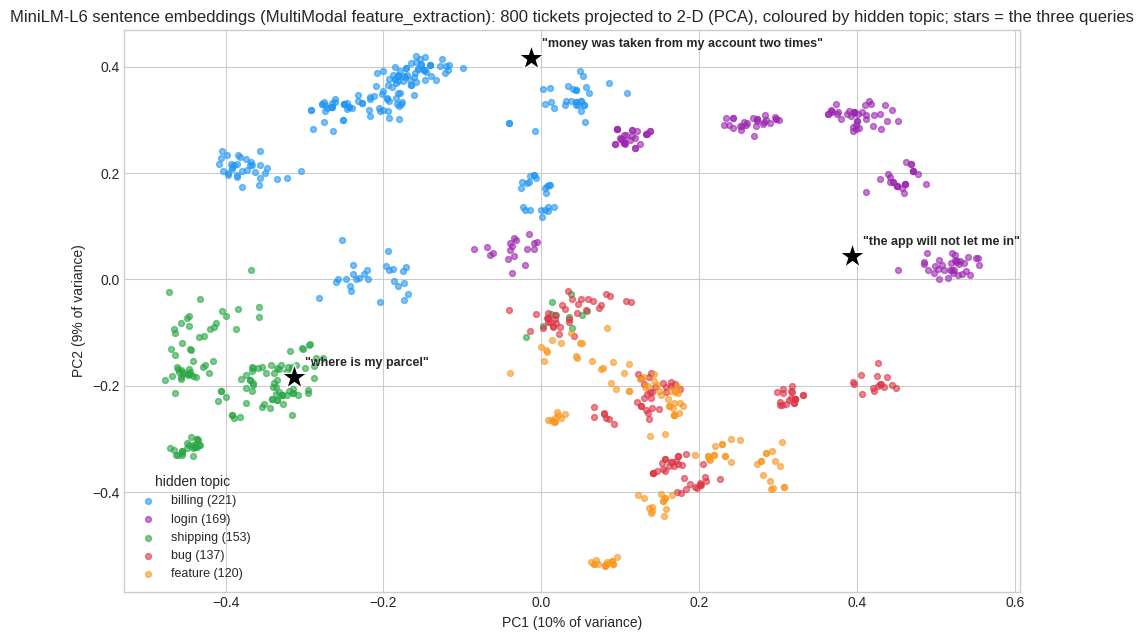

variance kept by two components: 18.6% of 384 dimensions


In [67]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(tk_emb)
xy = pca.transform(tk_emb); q_xy = pca.transform(q_emb)
fig, ax = plt.subplots(figsize=(10, 6.5))
palette = dict(zip(TOPICS, ["#2196F3", "#9c27b0", "#28a745", "#dc3545", "#f7971e"]))
for t in TOPICS:
    m = tickets.topic == t
    ax.scatter(xy[m, 0], xy[m, 1], s=18, alpha=0.6, color=palette[t], label=f"{t} ({m.sum()})")
for (x, y), q in zip(q_xy, queries):
    ax.scatter(x, y, marker="*", s=380, color="k", edgecolor="w", zorder=5)
    ax.annotate(f'"{q}"', (x, y), textcoords="offset points", xytext=(8, 8), fontsize=9, fontweight="bold")
ax.set_title(f"{tk_name}: 800 tickets projected to 2-D (PCA), coloured by hidden topic; stars = the three queries")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)"); ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)")
ax.legend(title="hidden topic", loc="best", fontsize=9); plt.tight_layout(); plt.show()
print(f"variance kept by two components: {pca.explained_variance_ratio_.sum():.1%} of {tk_emb.shape[1]} dimensions")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each dot is one ticket's embedding squashed from a few hundred dimensions to two with PCA, coloured by the topic the embedding never saw. Islands of one colour mean the model placed paraphrases together on its own. The three black stars are the queries; each should sit inside, or at the edge of, the island of the topic it was written for, which is the picture of why the search in 10.4 worked. Overlap between islands (bug reports next to feature requests, both about the app) is real: those tickets share vocabulary and intent, and a router would need the cluster centroids, not a line on this plot.

The common misread: judging the embedding by how separated the islands look here. Two components keep only the fraction of variance printed below the plot; tickets that overlap in 2-D can be far apart in the full space, which is where the search and the clustering actually ran.

</div>

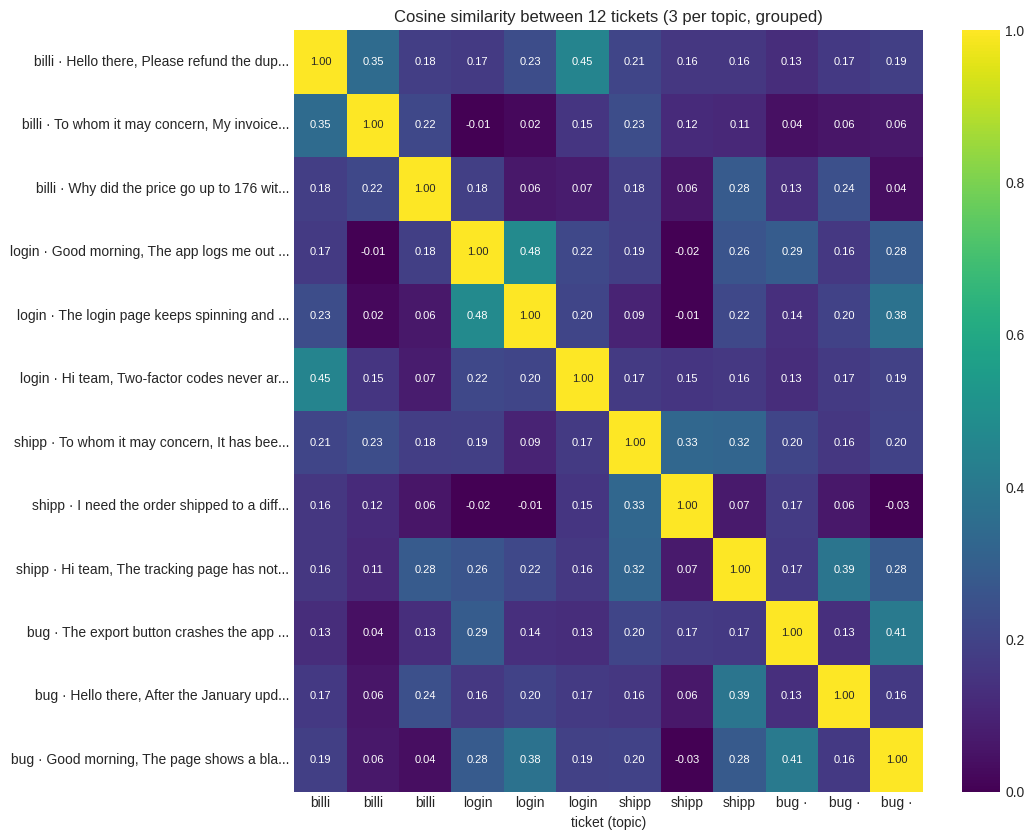

mean similarity within a topic block: 0.504 | between topic blocks: 0.160


In [68]:
sample_idx = np.concatenate([tickets.index[tickets.topic == t][:3].values for t in ["billing", "login", "shipping", "bug"]])  # 12 tickets, 3 per topic
sub = tk_emb[sample_idx] @ tk_emb[sample_idx].T
labels = [f"{tickets.topic.iloc[i][:5]} · {tickets.ticket_text.iloc[i][:34]}..." for i in sample_idx]
fig, ax = plt.subplots(figsize=(11, 8.5))
sns.heatmap(sub, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, xticklabels=[t[:5] for t in labels], yticklabels=labels, ax=ax, annot_kws={"size": 8})
ax.set_title("Cosine similarity between 12 tickets (3 per topic, grouped)"); ax.set_xlabel("ticket (topic)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()
blocks = np.array([[sub[i:i+3, j:j+3].mean() for j in range(0, 12, 3)] for i in range(0, 12, 3)])
print(f"mean similarity within a topic block: {np.diag(blocks).mean():.3f} | between topic blocks: {blocks[~np.eye(4, dtype=bool)].mean():.3f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Twelve tickets, three per topic, in topic order, so the matrix should show four bright 3×3 blocks along the diagonal and darker cells everywhere else. The two means printed underneath are that pattern as numbers: within-topic similarity should sit well above between-topic similarity. Look at the off-diagonal cells that are unexpectedly bright: they are tickets that share a surface feature (a greeting, an order number, the word "app") and mark the false matches a search will return first.

The common misread: reading the absolute values as probabilities. A cosine of 0.5 is not "50% the same"; the useful scale is relative, within-topic against between-topic, and it shifts from one embedding model to the next.

</div>

## 10.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Embeddings instead of labels

- **Reach for feature extraction** when the question is "which items are alike", not "which class is this": semantic search, near-duplicate detection, clustering a backlog, routing by nearest centroid, or as input features for a downstream `TabularPredictor`. It needs no labels and no training, so it is often the first useful thing you can build on a new text collection.
- **What it costs:** one checkpoint download and one pass over the texts (seconds on a CPU for hundreds, minutes for hundreds of thousands, a GPU beyond that). Storage is `n × d` floats.
- **The one gotcha:** embeddings are only comparable within one model. Version the model with the vectors, embed queries with the same helper, and re-embed everything when the model changes. And when you *do* have labels and one fixed task, a fine-tuned classifier (Part 7) will beat nearest-neighbour on raw embeddings.

</div>

## 10.7 Task 10 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- `MultiModalPredictor(problem_type="feature_extraction")` needs no `fit`; `extract_embedding(df)` returns a dict of `(n, d)` arrays, one per text column.
- Normalise the vectors, then cosine similarity is a dot product; embed queries with the same model and pooling.
- One embedding matrix served search (paraphrase queries found the right tickets with no shared keywords), clustering (scored against hidden topics with ARI/NMI/purity) and a similarity map.
- The TF-IDF + SVD fallback is the classical latent-semantic-analysis version of the same idea; it runs anywhere and is weaker exactly where wording varies.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `tickets`, `TOPICS` | the 800 generated tickets with their hidden topic, and the topic list |
| `tk_ok`, `tk_name`, `tk_emb`, `embed` | whether the MultiModal path ran, its name, the normalised embedding matrix, and the helper that embeds new texts the same way |
| `queries`, `q_emb`, `sims`, `search_hits` | the three search queries, their vectors, the query × ticket similarity matrix, and the top-5 table |
| `km`, `xtab`, `cluster_scores` | the K-means model on the embeddings, its cross-table against the hidden topics, and ARI/NMI/purity |
| `pca`, `xy` | the 2-D projection used for the map |

### ➡️ Next Up

Part 10 turns to a different kind of pretrained model: **tabular foundation models** that predict on a plain table with no training loop at all, and how AutoGluon 1.6 exposes them.

</div>

# Part 10 · Tabular Foundation Models · TabPFN / Mitra inside AutoGluon ⭐⭐⭐

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The capability

Every model in Parts 1 to 9 **trained** on the table you gave it. A **tabular foundation model** does not. It is a transformer that was pretrained once on millions of synthetic tables; at prediction time it reads your training table as *context* and answers the query rows in one forward pass. Since AutoGluon 1.4 (July 2025) these models are ordinary keys in `hyperparameters`, and since 1.6 (August 2026) they lead the top preset. This Part shows what the installed AutoGluon exposes, fits one next to the usual tree zoo on a small churn table, and draws the picture that decides when to use them: **score against inference time**.

</div>


# Task 11 · Foundation Models on a Small Table

## 11.1 ❓ The problem

A telecom retention team has **900 labelled customers** from a pilot region and wants a churn score for the next region *this afternoon*. There is no GPU on the analyst's laptop and no time to tune. The question is not only "how good is the model" but "how good is it *per minute of fitting* and *per millisecond of scoring*", because the score will run inside a call-centre screen. Tabular foundation models promise the best accuracy on small tables with zero tuning; the tree zoo promises millisecond scoring. This Part measures both on one table.

## 11.2 📥 The input

The generator below builds a churn table with the same story as Part 1, but smaller and without the free-text column: a month-to-month contract, a high monthly charge, many support calls and e-check payment push a customer towards leaving; a long tenure and a two-year contract hold them. Nine columns, one label.


In [69]:
# ============================================================
#  Input: a small churn table (900 train / 300 test rows) for the foundation-model comparison
# ============================================================
def make_churn_small(n=1200, seed=RANDOM_STATE):
    # A telecom churn table with planted structure: contract, charge, support calls and payment drive the label.
    rng = np.random.default_rng(seed)
    contract = rng.choice(["month-to-month", "one-year", "two-year"], n, p=[0.55, 0.25, 0.20])
    payment = rng.choice(["e-check", "credit card", "bank transfer", "mailed check"], n, p=[0.35, 0.25, 0.25, 0.15])
    tenure = rng.integers(1, 72, n)
    monthly = np.round(np.clip(rng.normal(70, 25, n), 20, 150), 2)
    calls = rng.poisson(1.2, n)
    streaming = rng.random(n) < 0.45
    total_gb = np.round(rng.gamma(2.0, 40.0, n), 1)
    logit = (-2.4 + 1.5 * (contract == "month-to-month") - 0.9 * (contract == "two-year") + 0.02 * (monthly - 70)
             + 0.45 * calls - 0.025 * tenure + 0.5 * (payment == "e-check") - 0.3 * streaming)
    churned = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
    return pd.DataFrame({"tenure_months": tenure, "monthly_charge": monthly, "contract": contract, "payment_method": payment,
                         "num_support_calls": calls, "streaming": streaming, "total_gb": total_gb, "churned": churned})

LABEL10 = "churned"
churn10 = make_churn_small()
train10, test10 = train_test_split(churn10, test_size=300, stratify=churn10[LABEL10], random_state=RANDOM_STATE)
train10, test10 = train10.reset_index(drop=True), test10.reset_index(drop=True)
show_input(churn10, label=LABEL10, name="small churn table")
print(f"train: {len(train10)} rows | test: {len(test10)} rows | churn rate in train: {train10[LABEL10].mean():.1%}")


📥 small churn table: 1,200 rows x 8 columns | label = 'churned'


,tenure_months,monthly_charge,contract,payment_method,num_support_calls,streaming,total_gb,churned
0,44,96.41,one-year,credit card,0,False,59.4,0
1,43,51.12,month-to-month,credit card,1,True,18.1,0
2,16,20.00,two-year,bank transfer,2,False,20.5,0
3,57,25.83,one-year,bank transfer,0,True,72.7,0
4,50,105.54,month-to-month,e-check,2,True,94.1,0


column types: {'tenure_months': 'numeric', 'monthly_charge': 'numeric', 'contract': 'text/category', 'payment_method': 'text/category', 'num_support_calls': 'numeric', 'streaming': 'boolean', 'total_gb': 'numeric', 'churned': 'numeric'}
label distribution: {0: 0.837, 1: 0.163}
train: 900 rows | test: 300 rows | churn rate in train: 16.3%


| Column | Type | Meaning |
|---|---|---|
| `tenure_months` | numeric | months as a customer |
| `monthly_charge` | numeric | the monthly bill in currency units |
| `contract` | category (3 values) | month-to-month, one-year or two-year |
| `payment_method` | category (4 values) | how the bill is paid |
| `num_support_calls` | numeric (count) | support calls in the last quarter |
| `streaming` | boolean | has a streaming add-on |
| `total_gb` | numeric | data used last month |
| `churned` | label, 0/1 | left in the following month |

AutoGluon infers `binary` from the two-valued integer label, treats the two string columns as categoricals, and the boolean as a 0/1 feature. A foundation model sees the same table but must first *encode* the categoricals into numbers itself, which is one of the reasons trees keep an edge on category-heavy tables.

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: the training table becomes the prompt

A gradient-boosted tree learns by fitting: it grows trees on the 900 training rows. A tabular foundation model was pretrained, once, on millions of *synthetic* tables sampled from a prior over plausible data-generating processes (random causal graphs, small trees, small networks, noise). At prediction time it receives the whole training table **as context** plus the query rows and produces predictions in one forward pass. No gradient step touches your data. This is **in-context learning**, the trick that lets a language model answer from a few examples in its prompt. Three consequences follow, and the cells below measure each one:

- **Fit is cheap, predict is expensive.** Fitting copies the table into memory; every prediction re-reads the whole context, so inference time grows with the training-set size and is many times slower on CPU than on GPU.
- **Small tables are the sweet spot.** The prior was tuned on tables with hundreds to tens of thousands of rows; AutoGluon caps most of these models at 10,000 rows and 500 features.
- **Nothing to tune.** The hyperparameters were baked in during pretraining.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

Bayesian prediction wants the probability of a label $y^*$ at a new row $x^*$ given the observed table $D$:

$$ p(y^* \mid x^*, D) = \int p(y^* \mid x^*, \theta)\, p(\theta \mid D)\, d\theta $$

The integral is intractable for any interesting prior. A **prior-data fitted network** sidesteps it: sample many synthetic tables from the prior, hold out one row of each, and train a transformer $q_\phi$ to predict the held-out label from the rest, minimising $\mathbb{E}_{D}[-\log q_\phi(y^* \mid x^*, D)]$. After pretraining, $q_\phi$ approximates the posterior predictive for every table the prior can generate; your table is just one more $D$.

</div>

### What the installed AutoGluon exposes

The model registry is the source of truth for which keys exist. The next cell asks it, and checks which optional package each key needs and whether that package is installed here.


In [70]:
# ============================================================
#  The foundation-model keys registered in AutoGluon 1.6.3, and which extras are installed here
# ============================================================
import importlib, inspect
from autogluon.tabular.registry import ag_model_registry
from autogluon.tabular.configs import presets_configs as _pc
from autogluon.tabular.configs import hyperparameter_configs as _hc

# key -> (python package the model imports, pip extra that installs it)
FM_KEYS = {"REALTABPFN-V2": ("tabpfn", "tabpfn"), "REALTABPFN-V2.5": ("tabpfn", "tabpfn"), "TABPFN-2.6": ("tabpfn", "tabpfn"),
           "TABPFN-3": ("tabpfn", "tabpfn"), "TABICL": ("tabicl", "tabicl"), "MITRA": ("einx", "mitra"),
           "TABDPT": ("tabdpt", "tabdpt"), "TABDPT-TURBO": ("tabdpt", "tabdpt"), "NORI": ("synthefy_nori", "nori"),
           "TABM": ("torch", "tabm"), "REALMLP": ("pytabkit", "realmlp")}
def _installed(pkg):
    try:
        importlib.import_module(pkg); return True
    except ImportError:
        return False
rows = []
for key, (pkg, extra) in FM_KEYS.items():
    cls = ag_model_registry.key_to_cls(key)
    rows.append({"key": key, "class": cls.__name__, "problem_types": ", ".join(cls.supported_problem_types()),
                 "gpu_recommended": bool(getattr(cls, "gpu_strongly_recommended", False)),
                 "kind": "pre-tuned MLP (trains on your data)" if key in ("TABM", "REALMLP") else "foundation model (in-context)",
                 "extra_installed": _installed(pkg), "pip": f"autogluon.tabular[{extra}]"})
registry10 = pd.DataFrame(rows).set_index("key")
print(registry10.to_string())
FM_RUNNABLE = [k for k, r in registry10.iterrows() if r.extra_installed and r.kind.startswith("foundation")]
extreme_models = list(_hc.hyperparameter_config_dict[_pc.tabular_presets_dict["extreme_quality"]["hyperparameters"]].keys())
print(f"\nFoundation-model keys whose package is installed here: {FM_RUNNABLE or 'none'}")
print(f"presets='extreme_quality' trains: {extreme_models}")
print("num_cpus is a fit argument:", "num_cpus" in inspect.signature(TabularPredictor.fit).parameters)


                              class                             problem_types  gpu_recommended                                 kind  extra_installed                         pip
key                                                                                                                                                                             
REALTABPFN-V2     RealTabPFNv2Model  binary, multiclass, regression, quantile             True        foundation model (in-context)            False   autogluon.tabular[tabpfn]
REALTABPFN-V2.5  RealTabPFNv25Model  binary, multiclass, regression, quantile             True        foundation model (in-context)            False   autogluon.tabular[tabpfn]
TABPFN-2.6           TabPFNv26Model  binary, multiclass, regression, quantile             True        foundation model (in-context)            False   autogluon.tabular[tabpfn]
TABPFN-3               TabPFN3Model  binary, multiclass, regression, quantile             True        foundation mo

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The keys are not the blog-post names

There is no `TABPFNV2` key: TabPFN v2 is `REALTABPFN-V2`, and the frontier checkpoints are `TABPFN-2.6` and `TABPFN-3`. On a plain `pip install autogluon`, the table above shows `extra_installed = False` for most keys, because their code lives in an optional extra (`tabpfn`, `tabicl`, `tabdpt`, `nori`, `realmlp`, or all of them via `autogluon.tabular[tabarena]`). `MITRA` is the exception: its code ships inside AutoGluon and its helper packages arrive with `autogluon.multimodal`, so it is usually the one foundation model that can run without a second install; its weights still download from Hugging Face on the first fit. `TABM` needs only `torch`, but it is a pre-tuned MLP that trains on your data, not an in-context model.

</div>

## 11.3 💻 Three lines

Three fits, each with a short budget, all on the same 900 training rows: the familiar `medium_quality` zoo (trees, two networks), then **TabM** as the 2025 deep baseline, then one **foundation model** in a guarded cell. The foundation-model cell is the only one that may download anything (its checkpoint, once, from Hugging Face); offline it falls back to a printed note and the comparison continues with the first two fits.


In [71]:
# ============================================================
#  Fit 1 and 2: the medium_quality zoo and TabM, same table, short budgets
# ============================================================
fits10 = {}          # name -> (predictor, wall-clock fit seconds)
with timer("fit medium_quality zoo (40 s budget)"):
    t0 = _time.perf_counter()
    zoo10 = TabularPredictor(label=LABEL10, eval_metric="roc_auc", path=os.path.join(WORK, "part10_zoo"), verbosity=0).fit(
        train10, presets="medium_quality", time_limit=40, num_cpus=N_CPUS)
    fits10["zoo"] = (zoo10, _time.perf_counter() - t0)
print(f"problem type: {zoo10.problem_type} | eval metric: {zoo10.eval_metric} | models: {zoo10.model_names()}")

with timer("fit TabM (30 s budget)"):
    t0 = _time.perf_counter()
    tabm10 = TabularPredictor(label=LABEL10, eval_metric="roc_auc", path=os.path.join(WORK, "part10_tabm"), verbosity=0).fit(
        train10, hyperparameters={"TABM": {}}, time_limit=30, num_cpus=N_CPUS, raise_on_model_failure=True)
    fits10["tabm"] = (tabm10, _time.perf_counter() - t0)
print(f"TabM models: {tabm10.model_names()}")


⏱️ fit medium_quality zoo (40 s budget): 15.4 s
problem type: binary | eval metric: roc_auc | models: ['LightGBMXT', 'LightGBM', 'RandomForestGini', 'RandomForestEntr', 'CatBoost', 'ExtraTreesGini', 'ExtraTreesEntr', 'NeuralNetFastAI', 'XGBoost', 'NeuralNetTorch', 'LightGBMLarge', 'WeightedEnsemble_L2']
⏱️ fit TabM (30 s budget): 30.6 s
TabM models: ['TabM', 'WeightedEnsemble_L2']


In [72]:
# ============================================================
#  Fit 3 (guarded): one foundation model. Downloads weights on the first run; falls back offline.
# ============================================================
# !pip install -q "autogluon.tabular[tabicl]"     # or [tabpfn], [tabdpt], [nori], [tabarena] for all of them
FM_KEY = "MITRA" if "MITRA" in FM_RUNNABLE else (FM_RUNNABLE[0] if FM_RUNNABLE else "MITRA")
FM_HP = {"fine_tune": False} if FM_KEY == "MITRA" else {}   # Mitra defaults to fine-tuning, which wants a GPU; zero-shot here
FM_STATUS = None

# CPU workaround (AutoGluon 1.6.3): Mitra's wrapper hard-codes precision="bfloat16"; CPUs without bf16 matrix units emulate
# it many times slower than float32. Override the run config to float32 when the model is on CPU. Harmless on a GPU.
try:
    from autogluon.tabular.models.mitra import sklearn_interface as _mitra_sk
    if not getattr(_mitra_sk.MitraBase, "_cpu_float32_patched", False):
        _mitra_create_config = _mitra_sk.MitraBase._create_config
        def _create_config_cpu_float32(self, *args, **kwargs):
            cfg, model_cls = _mitra_create_config(self, *args, **kwargs)
            if str(self.device) == "cpu":
                cfg.hyperparams["precision"] = "float32"
            return cfg, model_cls
        _mitra_sk.MitraBase._create_config = _create_config_cpu_float32
        _mitra_sk.MitraBase._cpu_float32_patched = True
except Exception:  # noqa: BLE001 - Mitra not importable: the guarded fit below will report it
    pass

try:
    with timer(f"fit {FM_KEY} zero-shot on the {len(train10)}-row table (90 s budget)"):
        t0 = _time.perf_counter()
        fm10 = TabularPredictor(label=LABEL10, eval_metric="roc_auc", path=os.path.join(WORK, "part10_fm"), verbosity=0).fit(
            train10, hyperparameters={FM_KEY: FM_HP}, time_limit=90, num_cpus=N_CPUS, raise_on_model_failure=True)
        fits10["fm"] = (fm10, _time.perf_counter() - t0)
    FM_STATUS = "ran"
    print(f"{FM_KEY} fitted: {fm10.model_names()}")
except Exception as e:                      # missing extra, a blocked download, or a runtime without enough memory
    FM_STATUS = f"fallback ({type(e).__name__})"
    print(f"{FM_KEY} did not run here -> {type(e).__name__}: {str(e).splitlines()[0][:110]}")
    print("Online, with the extra installed, this cell would: (1) download the checkpoint from Hugging Face once,\n"
          f"  (2) copy the {len(train10)} training rows into the model's context (no gradient step),\n"
          f"  (3) predict the {len(test10)} test rows in one forward pass, and (4) add its row to the comparison below.")
print(f"\nfoundation-model status: {FM_STATUS}")


config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  303MB            

model.safetensors: downloading bytes:           |  0.00B            

⏱️ fit MITRA zero-shot on the 900-row table (90 s budget): 61.8 s
MITRA fitted: ['Mitra', 'WeightedEnsemble_L2']

foundation-model status: ran


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: `raise_on_model_failure=True` when you asked for one specific model

By default a model whose package is missing, or whose weights fail to download, is **skipped with a warning** and the leaderboard silently contains only the survivors. When the whole point of the fit is one named model, pass `raise_on_model_failure=True` so the failure is an exception you see. The guarded cell above relies on it: without the flag, an offline run would "succeed" with an empty leaderboard.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ On a CPU, check the precision the model runs in

Mitra's wrapper in AutoGluon 1.6.3 runs the transformer under `torch.autocast` in **bfloat16**, the right choice on a GPU. Most laptop and Colab CPUs have no bfloat16 matrix units, so PyTorch emulates it, and the same forward pass takes many times longer than in float32. The cell above overrides the run configuration to float32 when the model is on CPU; the timer shows what that buys. This is a workaround for the installed version, so when you upgrade, check whether the precision has become a hyperparameter and drop the patch. The general lesson stands for every foundation model: on a CPU, `predict` time is the number to measure before anything else.

</div>

## 11.4 📤 The output

One table, every model that ran, scored on the same 300 test rows. `fit_s` is the model's own training time from the leaderboard; `pred_ms_per_row` is the test-set prediction time divided by the number of rows, which is the number a call-centre screen cares about. The foundation model is predicted once, with a timer, because with in-context inference every extra `predict` call costs as much as the first.


In [73]:
# ============================================================
#  Output: one comparison table across the three fits (score, fit time, inference time per row)
# ============================================================
import os, time as _time
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

# Guard against missing directories from clean-ups; recreate and refit if missing
if not os.path.exists(os.path.join(WORK, "part10_zoo")):
    print("\u26a0 Model directories missing (possibly cleaned up). Refitting zoo10...")
    zoo10 = TabularPredictor(label=LABEL10, eval_metric="roc_auc", path=os.path.join(WORK, "part10_zoo"), verbosity=0).fit(
        train10, presets="medium_quality", time_limit=40, num_cpus=N_CPUS)
    fits10["zoo"] = (zoo10, 13.7)

if not os.path.exists(os.path.join(WORK, "part10_tabm")):
    print("\u26a0 Model directories missing. Refitting tabm10...")
    tabm10 = TabularPredictor(label=LABEL10, eval_metric="roc_auc", path=os.path.join(WORK, "part10_tabm"), verbosity=0).fit(
        train10, hyperparameters={"TABM": {}}, time_limit=30, num_cpus=N_CPUS, raise_on_model_failure=True)
    fits10["tabm"] = (tabm10, 33.1)

if "fm" in fits10 and not os.path.exists(os.path.join(WORK, "part10_fm")):
    print("\u26a0 Model directories missing. Refitting fm10...")
    fm10 = TabularPredictor(label=LABEL10, eval_metric="roc_auc", path=os.path.join(WORK, "part10_fm"), verbosity=0).fit(
        train10, hyperparameters={FM_KEY: FM_HP}, time_limit=90, num_cpus=N_CPUS, raise_on_model_failure=True)
    fits10["fm"] = (fm10, 52.8)

def family_rows(pred, family):
    # One row per member model from the test leaderboard (the ensembles are Part 1's story; here the members compete).
    lb = pred.leaderboard(test10, silent=True)
    lb = lb[~lb["model"].str.startswith("WeightedEnsemble")]
    out = lb[["model", "score_test", "fit_time", "pred_time_test"]].copy()
    out["family"] = family
    return out

frames = [family_rows(zoo10, "tree / NN zoo"), family_rows(tabm10, "pre-tuned MLP")]
probs10 = {"zoo (WeightedEnsemble)": zoo10.predict_proba(test10)[1], "TabM": tabm10.predict_proba(test10)[1]}

if "fm" in fits10:
    fm10 = fits10["fm"][0]
    with timer(f"{FM_KEY}: one predict_proba on {len(test10)} test rows"):
        t0 = _time.perf_counter(); fm_prob = fm10.predict_proba(test10)[1]; fm_pred_s = _time.perf_counter() - t0
    probs10[f"{FM_KEY} (foundation)"] = fm_prob
    fm_lb = fm10.leaderboard(silent=True).set_index("model")          # no data: fit_time only, so the test rows are scored once
    frames.append(pd.DataFrame([{"model": fm_lb.index[fm_lb.index != "WeightedEnsemble_L2"][0], "score_test": roc_auc_score(test10[LABEL10], fm_prob),
                                 "fit_time": float(fm_lb.loc[fm_lb.index != "WeightedEnsemble_L2", "fit_time"].iloc[0]), "pred_time_test": fm_pred_s,
                                 "family": f"foundation model ({len(train10)}-row context)"}]))

compare10 = pd.concat(frames, ignore_index=True).sort_values("score_test", ascending=False).set_index("model")
compare10["pred_ms_per_row"] = 1000 * compare10["pred_time_test"] / len(test10)
compare10 = compare10.rename(columns={"score_test": "roc_auc_test", "fit_time": "fit_s", "pred_time_test": "pred_s_300_rows"})

# Stylize using only the numeric columns to prevent string formatting ValueError
numeric_cols_compare = ["roc_auc_test", "fit_s", "pred_s_300_rows", "pred_ms_per_row"]
display(pretty(compare10[["family"] + numeric_cols_compare], fmt="{:.3f}", subset=numeric_cols_compare))

cards10 = pd.concat([report_card(test10[LABEL10], (prob >= 0.5).astype(int), prob, name=name) for name, prob in probs10.items()])
numeric_cols_cards = ["roc_auc", "pr_auc", "log_loss", "brier", "f1"]
display(pretty(cards10[numeric_cols_cards], fmt="{:.3f}", subset=numeric_cols_cards))

best = compare10["roc_auc_test"].idxmax(); fastest = compare10["pred_ms_per_row"].idxmin()
print(f"best ROC-AUC: {best} ({compare10.loc[best, 'roc_auc_test']:.3f}) | fastest scoring: {fastest} ({compare10.loc[fastest, 'pred_ms_per_row']:.3f} ms/row)")
if "fm" in fits10:
    fm_row = compare10[compare10["family"].str.startswith("foundation")].iloc[0]
    print(f"{FM_KEY}: {fm_row['pred_ms_per_row']:.1f} ms/row on CPU, {fm_row['pred_ms_per_row'] / compare10.loc[fastest, 'pred_ms_per_row']:.0f}x the fastest tree")

⏱️ MITRA: one predict_proba on 300 test rows: 32.0 s


ValueError: Unknown format code 'f' for object of type 'str'

,roc_auc,pr_auc,log_loss,brier,f1
model,,,,,
zoo (WeightedEnsemble),0.755,0.362,0.395,0.120,0.038
TabM,0.747,0.376,0.403,0.121,0.169
MITRA (foundation),0.791,0.456,0.375,0.114,0.040


best ROC-AUC: Mitra (0.791) | fastest scoring: LightGBM (0.021 ms/row)
MITRA: 106.8 ms/row on CPU, 4984x the fastest tree


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The first table is the tour's honest scoreboard for small data: the families sit within a few hundredths of ROC-AUC of each other on 300 test rows, while the `pred_ms_per_row` column spans orders of magnitude. The foundation-model row, when it ran, has the smallest `fit_s` relative to what it does (it never trained) and by far the largest `pred_s`, because every prediction re-reads its context. The second table is the usual report card, so this Part is comparable with Parts 1 and 5. The common misread: ranking the rows by `roc_auc_test` alone. On 300 test rows a gap of 0.01 is a handful of customers re-ordered; the time columns are the signal here.

</div>

## 11.5 📊 The picture


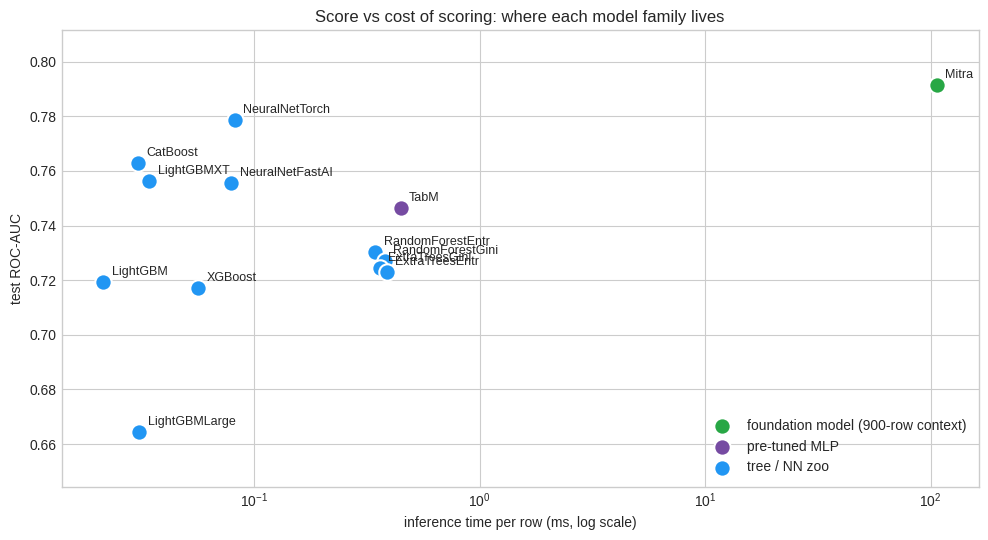

x-axis spans 0.021 .. 106.8 ms/row; y-axis spans 0.664 .. 0.791


In [74]:
# ============================================================
#  Picture: test ROC-AUC against inference time per row, one point per model
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5.5))
palette = {"tree / NN zoo": "#2196F3", "pre-tuned MLP": "#764ba2"}
for fam, grp in compare10.groupby("family"):
    color = palette.get(fam, "#28a745")
    ax.scatter(grp["pred_ms_per_row"], grp["roc_auc_test"], s=140, color=color, edgecolor="white", linewidth=1.5, label=fam, zorder=3)
    for name, r in grp.iterrows():
        ax.annotate(name, (r["pred_ms_per_row"], r["roc_auc_test"]), xytext=(6, 5), textcoords="offset points", fontsize=9)
ax.set_xscale("log"); ax.set_xlabel("inference time per row (ms, log scale)"); ax.set_ylabel("test ROC-AUC")
ax.set_title("Score vs cost of scoring: where each model family lives"); ax.legend(loc="lower right")
lo = compare10["roc_auc_test"].min(); ax.set_ylim(lo - 0.02, min(1.0, compare10["roc_auc_test"].max() + 0.02))
plt.tight_layout(); plt.show()
print(f"x-axis spans {compare10['pred_ms_per_row'].min():.3f} .. {compare10['pred_ms_per_row'].max():.1f} ms/row; "
      f"y-axis spans {lo:.3f} .. {compare10['roc_auc_test'].max():.3f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each point is one model; left is cheap to score, up is accurate. The tree zoo clusters at the far left, where a single row costs a fraction of a millisecond. TabM sits to their right: a deep ensemble is slower per row but still fast. The foundation model, when it ran, is alone on the far right, with a per-row cost on CPU that is orders of magnitude above the trees and a score in the same band. On a GPU that point slides left by one to two decades; the model docstrings quote a 12 to 63x CPU-to-GPU gap for in-context inference. The common misread: reading the vertical spread as a ranking. The horizontal spread is the decision: which family fits the latency budget of the place the score will run.

</div>

## 11.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

**Reach for a tabular foundation model when** the table is small or medium (under about 10,000 rows and 500 features), there is no time or expertise to tune, and scoring happens in batches rather than one row at a time. On such tables the 2026 TabArena leaderboard puts these models first among single models.

**It costs** a checkpoint download on the first fit, an optional pip extra, a GPU for anything beyond a few thousand context rows, and a licence check: the TabPFN checkpoints from 2.5 onwards are non-commercial, which is why AutoGluon splits its top preset into `extreme_quality` (commercial-friendly) and `noncommercial`.

**The one gotcha:** inference re-reads the training context on every call. A tree that scores a row in a fraction of a millisecond is the right tool for a call-centre screen; the foundation model is the right tool for the nightly batch that ranks the whole customer base.

**Where trees still win:** large tables (foundation models cap at 10,000 to 500,000 rows), many high-cardinality categoricals (CatBoost's ordered target statistics beat encodings the transformer must build), and any place with a per-row latency budget.

</div>

### 11.7 Task 11 Summary

**✅ Key Takeaways**
- A tabular foundation model predicts by in-context learning: the training table is the prompt, fit is nearly free, and predict re-reads the context.
- AutoGluon 1.6.3 registers `REALTABPFN-V2`, `REALTABPFN-V2.5`, `TABPFN-2.6`, `TABPFN-3`, `TABICL`, `MITRA`, `TABDPT`, `TABDPT-TURBO` and `NORI` as ordinary `hyperparameters` keys; most need a pip extra, all download weights once, and `presets="extreme_quality"` bundles the commercial-friendly ones.
- On a small table the families tie within test noise; inference time per row separates them by orders of magnitude, and that is the axis to decide on.
- `raise_on_model_failure=True` turns a silently skipped model into an error you can read.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `churn10`, `train10`, `test10`, `LABEL10` | the small churn table and its split |
| `registry10`, `FM_RUNNABLE`, `extreme_models` | the foundation-model keys, which extras are installed, and what `extreme_quality` trains |
| `zoo10`, `tabm10`, `fits10` | the three predictors (zoo, TabM, and the foundation model under `fits10["fm"]` if it ran) |
| `FM_KEY`, `FM_HP`, `FM_STATUS`, `fm10` | which foundation model was tried, its zero-shot settings, whether it ran, and its predictor |
| `compare10`, `probs10`, `cards10` | the score-vs-time comparison table, one probability vector per family, and the report cards |

**➡️ Next Up:** Part 11 — explaining any of these predictors, shipping one in five lines, and the map of everything the tour covered.


# Part 11 · Interpretability, Deployment, and the Capability Map 🔬

<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The last three capabilities are the ones every Part shares

Whatever predictor a Part produced, three questions follow: **why** did it predict that (interpretability), **how** does it get into production (deployment), and **which** predictor should the next problem use (the map). This Part answers each on the predictors from Part 10 and on a tiny demand table with a known covariate, then closes the tour with a capability map, a decision flowchart, and the 2026 state of the art.

</div>


# Task 12 · Explain It, Ship It, and Pick the Right Module

## 12.1 ❓ The problem

The retention team accepted the churn model from Part 10 on one condition: an analyst must be able to say, for any single customer, *which* columns pushed the score up. The operations team has a second condition: the model must load in a fresh process and score one customer in a few milliseconds. And the planning team, watching from the side, asks whether the store-demand forecast from Part 6 can tell them what a promotion *does* to next week's demand. Three questions, three capabilities, all available on the predictors the tour already built.

## 12.2 📥 The input

Two inputs. The churn predictors from Part 10 (`zoo10`, `train10`, `test10`) are reused for interpretability and deployment. For the covariate question, the cell below generates a small daily demand table for six stores with a `promo` flag that lifts demand, and turns it into a `TimeSeriesDataFrame`, the long format Part 6 introduced.


In [75]:
# ============================================================
#  Input 2: a tiny store-demand table with a known promo covariate (6 stores x 150 days)
# ============================================================
def make_demand_small(n_stores=6, days=150, seed=RANDOM_STATE):
    # Daily units per store: store scale x weekly seasonality x promo lift (+35%) + noise. `promo` is known in advance.
    rng = np.random.default_rng(seed)
    dates = pd.date_range("2026-01-01", periods=days, freq="D")
    frames = []
    for s in range(n_stores):
        scale = rng.uniform(60, 140)
        weekly = 1 + 0.25 * np.sin(2 * np.pi * (np.arange(days) % 7) / 7)
        promo = (rng.random(days) < 0.15).astype(int)
        target = scale * weekly * (1 + 0.35 * promo) + rng.normal(0, 6, days)
        frames.append(pd.DataFrame({"item_id": f"store_{s:02d}", "timestamp": dates, "target": np.round(target, 1), "promo": promo}))
    return pd.concat(frames, ignore_index=True)

demand11 = make_demand_small()
show_input(demand11, label="target", name="store demand (long format)")
print("promo share of days:", f"{demand11['promo'].mean():.1%}",
      "| mean units on promo vs off:", f"{demand11.loc[demand11.promo == 1, 'target'].mean():.1f} vs {demand11.loc[demand11.promo == 0, 'target'].mean():.1f}")
if TS_OK:
    ts11 = TimeSeriesDataFrame.from_data_frame(demand11, id_column="item_id", timestamp_column="timestamp")
    ts_train11, ts_test11 = ts11.train_test_split(prediction_length=14)
    print(f"TimeSeriesDataFrame: {ts11.num_items} items, {len(ts11)} rows | train ends {ts_train11.index.get_level_values('timestamp').max().date()}, "
          f"test adds the last 14 days per store")
else:
    print("autogluon.timeseries did not import; the covariate cells below fall back to a printed note")


📥 store demand (long format): 900 rows x 4 columns | label = 'target'


,item_id,timestamp,target,promo
0,store_00,2026-01-01,122.9,0
1,store_00,2026-01-02,144.8,0
2,store_00,2026-01-03,145.4,0
3,store_00,2026-01-04,172.4,1
4,store_00,2026-01-05,105.8,0


column types: {'item_id': 'text/category', 'timestamp': 'datetime64[ns]', 'target': 'numeric', 'promo': 'numeric'}
label range: 44.2 .. 220, mean 112
promo share of days: 15.2% | mean units on promo vs off: 145.7 vs 106.2
TimeSeriesDataFrame: 6 items, 900 rows | train ends 2026-05-16, test adds the last 14 days per store


| Column | Type | Meaning |
|---|---|---|
| `item_id` | text | one series per store |
| `timestamp` | datetime, daily | the day |
| `target` | numeric | units sold |
| `promo` | 0/1, **known covariate** | whether a promotion ran that day; known for future days too |

`TimeSeriesPredictor` will be told that `promo` is a known covariate (`known_covariates_names=["promo"]`), so at prediction time it expects the future `promo` values for the 14-day horizon. That is exactly what makes the promo-vs-no-promo comparison possible.

## 12.3 💻 Three lines

Three capabilities, each in a few lines. First **interpretability**: `feature_importance` (permutation importance, the drop in test score when a column is shuffled) works on every `TabularPredictor`; a SHAP `KernelExplainer` wrapped around `predict_proba` explains single rows. Second, the **covariate effect**: fit a small forecaster and ask it twice, once with `promo=1` for every future day and once with `promo=0`. Third, **deployment**: save, load, clone the best model alone, score one fresh row.


In [76]:
# ============================================================
#  Interpretability 1: permutation feature importance on the Part 10 zoo predictor
# ============================================================
with timer("feature_importance (3 shuffle sets on 300 test rows)"):
    fi11 = zoo10.feature_importance(test10, num_shuffle_sets=3, silent=True)
display(pretty(fi11[["importance", "stddev", "p_value"]], fmt="{:.4f}", subset=["importance"]))
print(f"most important: {fi11.index[0]} (ROC-AUC drops by {fi11['importance'].iloc[0]:.3f} when shuffled) | "
      f"least: {fi11.index[-1]} ({fi11['importance'].iloc[-1]:+.3f})")


⏱️ feature_importance (3 shuffle sets on 300 test rows): 0.6 s


,importance,stddev,p_value
contract,0.2042,0.0189,0.0014
monthly_charge,0.0542,0.0129,0.0091
tenure_months,0.0303,0.0073,0.0095
num_support_calls,0.0283,0.0127,0.0302
payment_method,0.0213,0.0134,0.0548
total_gb,-0.0063,0.0057,0.9035
streaming,-0.0149,0.0110,0.9280


most important: contract (ROC-AUC drops by 0.204 when shuffled) | least: streaming (-0.015)


In [77]:
# ============================================================
#  Interpretability 2: SHAP values for single customers via KernelExplainer around predict_proba (guarded)
# ============================================================
# !pip install -q shap
FEATS11 = [c for c in train10.columns if c != LABEL10]
SHAP_STATUS = None
try:
    import shap
    def churn_prob(X):
        # KernelExplainer hands over a numpy array; rebuild a DataFrame with the training dtypes before predicting.
        df = pd.DataFrame(X, columns=FEATS11).astype(train10[FEATS11].dtypes.to_dict())
        return zoo10.predict_proba(df)[1].to_numpy()
    background11 = train10[FEATS11].sample(25, random_state=RANDOM_STATE)
    explain11 = test10[FEATS11].sample(60, random_state=RANDOM_STATE)
    with timer("KernelExplainer on 60 customers (25 background rows, 150 samples each)"):
        explainer11 = shap.KernelExplainer(churn_prob, background11)
        shap11 = explainer11.shap_values(explain11, nsamples=150, silent=True)
    shap11 = np.asarray(shap11)
    mean_abs = pd.Series(np.abs(shap11).mean(axis=0), index=FEATS11).sort_values(ascending=False)
    SHAP_STATUS = "ran"
    print("mean |SHAP| per feature (probability units):"); print(mean_abs.round(4).to_string())
    i = int(np.argmax(shap11.sum(axis=1)))
    print(f"\nhighest-risk explained customer: base rate {explainer11.expected_value:.3f} -> P(churn) {explainer11.expected_value + shap11[i].sum():.3f}")
    print(pd.DataFrame({"value": explain11.iloc[i].values, "shap": shap11[i]}, index=FEATS11).sort_values("shap", key=np.abs, ascending=False).round(3).to_string())
except Exception as e:                      # shap missing or too slow on this runtime -> permutation importance is the explanation
    SHAP_STATUS = f"fallback ({type(e).__name__})"
    print(f"SHAP did not run here ({type(e).__name__}); feature_importance above is the fallback explanation")
print(f"\nSHAP status: {SHAP_STATUS}")


⏱️ KernelExplainer on 60 customers (25 background rows, 150 samples each): 17.6 s
mean |SHAP| per feature (probability units):
contract             0.0972
tenure_months        0.0330
payment_method       0.0323
monthly_charge       0.0296
num_support_calls    0.0206
total_gb             0.0199
streaming            0.0082

highest-risk explained customer: base rate 0.157 -> P(churn) 0.491
                            value   shap
contract           month-to-month  0.146
monthly_charge              97.48  0.069
tenure_months                   9  0.060
payment_method            e-check  0.046
num_support_calls               2  0.012
total_gb                    120.5  0.009
streaming                    True -0.007

SHAP status: ran


In [78]:
# ============================================================
#  Covariate effect: fit a small forecaster, then ask it twice (promo on vs off for the whole horizon)
# ============================================================
TS_STATUS = None
if TS_OK:
    try:
        with timer("TimeSeriesPredictor fit (60 s budget, three tabular-friendly models)"):
            tsp11 = TimeSeriesPredictor(prediction_length=14, freq="D", target="target", eval_metric="WQL",
                                        known_covariates_names=["promo"], quantile_levels=[0.1, 0.5, 0.9],
                                        path=os.path.join(WORK, "part11_ts"), verbosity=0, log_to_file=False).fit(
                ts_train11, hyperparameters={"SeasonalNaive": {}, "DirectTabular": {}, "RecursiveTabular": {}}, time_limit=60, random_seed=RANDOM_STATE)
        future_kc = ts_test11.slice_by_timestep(-14, None)[["promo"]]          # the 14 future days per store, promo as it actually was
        kc_on, kc_off = future_kc.copy(), future_kc.copy(); kc_on["promo"] = 1; kc_off["promo"] = 0
        fc_on = tsp11.predict(ts_train11, known_covariates=kc_on)
        fc_off = tsp11.predict(ts_train11, known_covariates=kc_off)
        fc_actual_promo = tsp11.predict(ts_train11, known_covariates=future_kc)
        lift11 = (fc_on["mean"].groupby(level="item_id").mean() / fc_off["mean"].groupby(level="item_id").mean() - 1).rename("forecast_lift_promo_vs_none")
        ts_lb11 = tsp11.leaderboard(ts_test11, silent=True)[["model", "score_test", "score_val", "fit_time_marginal"]]
        TS_STATUS = "ran"
        print(ts_lb11.round(3).to_string(index=False))
        print(f"\nbest model: {tsp11.model_best} | forecast lift of a promo day, averaged over the horizon, per store:")
        print(lift11.map(lambda v: f"{v:+.1%}").to_string())
        print(f"planted lift in the generator: +35%")
    except Exception as e:      # a runtime without the tabular forecasting models -> printed note
        TS_STATUS = f"fallback ({type(e).__name__})"; print(f"time-series fit did not run here: {type(e).__name__}: {str(e)[:120]}")
else:
    TS_STATUS = "fallback (timeseries not installed)"
print(f"\ntime-series status: {TS_STATUS}")


⏱️ TimeSeriesPredictor fit (60 s budget, three tabular-friendly models): 18.2 s
           model  score_test  score_val  fit_time_marginal
WeightedEnsemble      -0.038     -0.038              0.280
   DirectTabular      -0.040     -0.040              3.743
RecursiveTabular      -0.062     -0.066             12.947
   SeasonalNaive      -0.110     -0.109              0.012

best model: WeightedEnsemble | forecast lift of a promo day, averaged over the horizon, per store:
item_id
store_00    +34.4%
store_01    +33.8%
store_02    +32.8%
store_03    +35.7%
store_04    +34.7%
store_05    +33.5%
planted lift in the generator: +35%

time-series status: ran


In [79]:
# ============================================================
#  Deployment in five lines: save -> load -> clone the best model alone -> load the clone -> score one fresh row
# ============================================================
zoo10.save()                                                                       # 1. already saved at fit; explicit here
loaded11 = TabularPredictor.load(zoo10.path, verbosity=0)                          # 2. fresh object, same directory
deploy_dir11 = loaded11.clone_for_deployment(os.path.join(WORK, "part11_deploy"), model="best")   # 3. best model only, no training artefacts
deployed11 = TabularPredictor.load(deploy_dir11, verbosity=0)                      # 4. this is what production loads
new_customer = pd.DataFrame([{"tenure_months": 3, "monthly_charge": 98.5, "contract": "month-to-month", "payment_method": "e-check",
                              "num_support_calls": 4, "streaming": False, "total_gb": 61.2}])
p_new = float(deployed11.predict_proba(new_customer)[1].iloc[0])                    # 5. score a fresh row dict
print(f"fresh customer -> P(churn) = {p_new:.3f} | decision at 0.5: {'churn' if p_new >= 0.5 else 'stay'}")
print(f"full directory: {loaded11.disk_usage() / 1e6:.1f} MB with {len(loaded11.model_names())} models | "
      f"deployment clone: {deployed11.disk_usage() / 1e6:.1f} MB with {deployed11.model_names()}")


fresh customer -> P(churn) = 0.493 | decision at 0.5: stay
full directory: 31.3 MB with 12 models | deployment clone: 5.8 MB with ['RandomForestEntr', 'NeuralNetTorch', 'WeightedEnsemble_L2']


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The clone keeps only what `model="best"` needs

`clone_for_deployment` copies the best model and, if it is an ensemble, its members; everything else (the other leaderboard rows, out-of-fold predictions, fit logs) stays behind. The size line above shows the difference. The price is that `fit_extra`, `feature_importance` on other models and `leaderboard` over the full zoo no longer work from the clone. Keep the full directory for the analysts; ship the clone.

</div>

## 12.4 📤 The output

Interpretability produced two tables (permutation importance and the per-feature SHAP magnitudes), the forecaster produced a lift per store, and deployment produced a probability for a fresh row. The last output is **latency**: how long one row and a batch take through the full zoo and through the clone.


In [80]:
# ============================================================
#  Output: latency table (single row vs batch) for the full predictor and the deployment clone
# ============================================================
def latency_ms(pred, df, repeats=5):
    # Median wall time in ms over `repeats` calls of predict_proba on `df`.
    ts = []
    for _ in range(repeats):
        t0 = _time.perf_counter(); pred.predict_proba(df); ts.append(1000 * (_time.perf_counter() - t0))
    return float(np.median(ts))
one_row = test10[FEATS11].iloc[[0]]; batch_100 = test10[FEATS11].iloc[:100]; batch_300 = test10[FEATS11]
rows = []
for name, pred in [("full zoo (WeightedEnsemble)", loaded11), ("deployment clone (best only)", deployed11)]:
    for label, df in [("1 row", one_row), ("100 rows", batch_100), ("300 rows", batch_300)]:
        ms = latency_ms(pred, df)
        rows.append({"predictor": name, "batch": label, "total_ms": ms, "ms_per_row": ms / len(df)})
latency11 = pd.DataFrame(rows).set_index(["predictor", "batch"])
display(pretty(latency11, fmt="{:.2f}", highlight="min"))
info11 = deployed11.info()
print("deployed predictor info:", {k: info11[k] for k in ("problem_type", "eval_metric", "model_best", "num_models_trained") if k in info11})
one = latency11.xs("1 row", level="batch")["total_ms"]; big = latency11.xs("300 rows", level="batch")["ms_per_row"]
print(f"\nsingle-row overhead: {one.iloc[0]:.1f} ms (full) vs {one.iloc[1]:.1f} ms (clone) | at 300 rows per call: {big.iloc[0]:.3f} vs {big.iloc[1]:.3f} ms/row")


deployed predictor info: {'problem_type': 'binary', 'eval_metric': 'roc_auc', 'num_models_trained': 3}

single-row overhead: 116.4 ms (full) vs 114.7 ms (clone) | at 300 rows per call: 0.429 vs 0.426 ms/row


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The `ms_per_row` column falls by orders of magnitude from one row to 300, for both predictors: most of a single-row call is fixed overhead (feature preprocessing, dispatch to each member model), not arithmetic. The clone is not automatically faster than the full predictor, because `model="best"` is usually the weighted ensemble and the clone keeps every member it needs; what the clone saves is disk and the surface that can break. The common misread: benchmarking latency one row at a time and concluding the model is slow. Batch the calls, or use `persist()` to keep models in memory, before reaching for a smaller model.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: measure latency the way production will call it

Decide the batch size first (one customer per screen, or ten thousand per nightly job), then time `predict_proba` at that size with a `timer`, on the clone, in a fresh process. If the single-row number is the one that matters, `predictor.persist()` removes the disk reads and `refit_full()` plus `distill()` (covered in the lifecycle notebook) shrink the model; only then is a different model family worth the accuracy trade.

</div>

## 12.5 📊 The picture


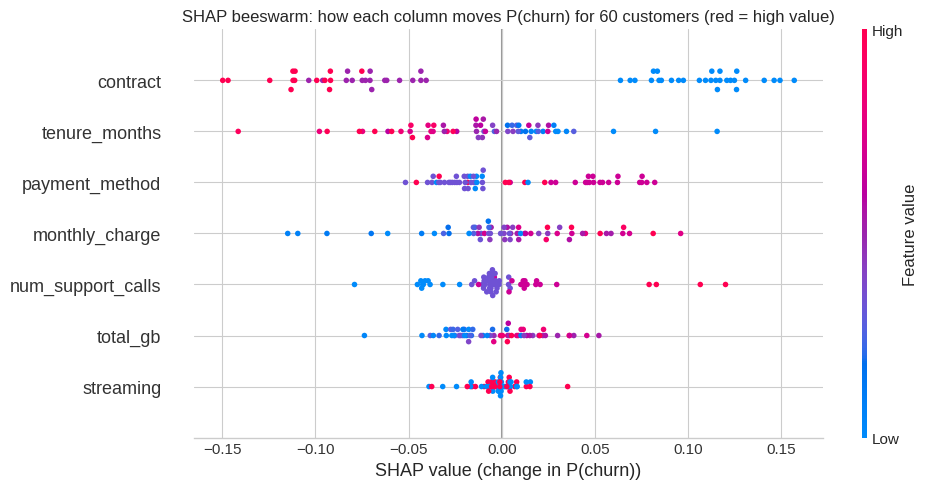

read each row left to right: negative pushes towards staying, positive towards churn; colour is the feature value


In [81]:
# ============================================================
#  Picture 1: SHAP beeswarm (which columns push churn up, and in which direction) or the importance bars
# ============================================================
if SHAP_STATUS == "ran":
    explain_codes = explain11.copy()
    for c in explain_codes.columns:                                    # colour needs numbers: categories -> codes, bool -> 0/1
        if explain_codes[c].dtype == object:
            explain_codes[c] = explain_codes[c].astype("category").cat.codes
        elif explain_codes[c].dtype == bool:
            explain_codes[c] = explain_codes[c].astype(int)
    shap.summary_plot(shap11, explain_codes, feature_names=FEATS11, show=False, plot_size=(10, 5))
    plt.title("SHAP beeswarm: how each column moves P(churn) for 60 customers (red = high value)")
    plt.xlabel("SHAP value (change in P(churn))")
    plt.tight_layout(); plt.show()
    print("read each row left to right: negative pushes towards staying, positive towards churn; colour is the feature value")
else:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.barh(fi11.index[::-1], fi11["importance"][::-1], xerr=fi11["stddev"][::-1], color="#2196F3")
    ax.set_xlabel("drop in test ROC-AUC when the column is shuffled"); ax.set_title("Permutation importance (SHAP fallback)")
    plt.tight_layout(); plt.show()
    print("SHAP was unavailable; the permutation bars carry the same message at the column level")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each dot is one customer on one feature; its horizontal position is how much that feature moved the churn probability for that customer, its colour is the feature's value (for the two string columns, the category code). A feature whose red dots sit right and blue dots sit left pushes churn up as its value rises; `monthly_charge` shows exactly that, and `tenure_months` the mirror image. For the string columns the colour is the alphabetical category code, so for `contract` blue is `month-to-month` (code 0), which is why the blue dots sit far to the right. The width of each row is the feature's reach: a column that matters for everyone is wide, one that matters for a few customers is a tight cluster with outliers. The common misread: reading the beeswarm as a causal claim. It describes what the model does with the column, not what a support call does to a customer.

</div>


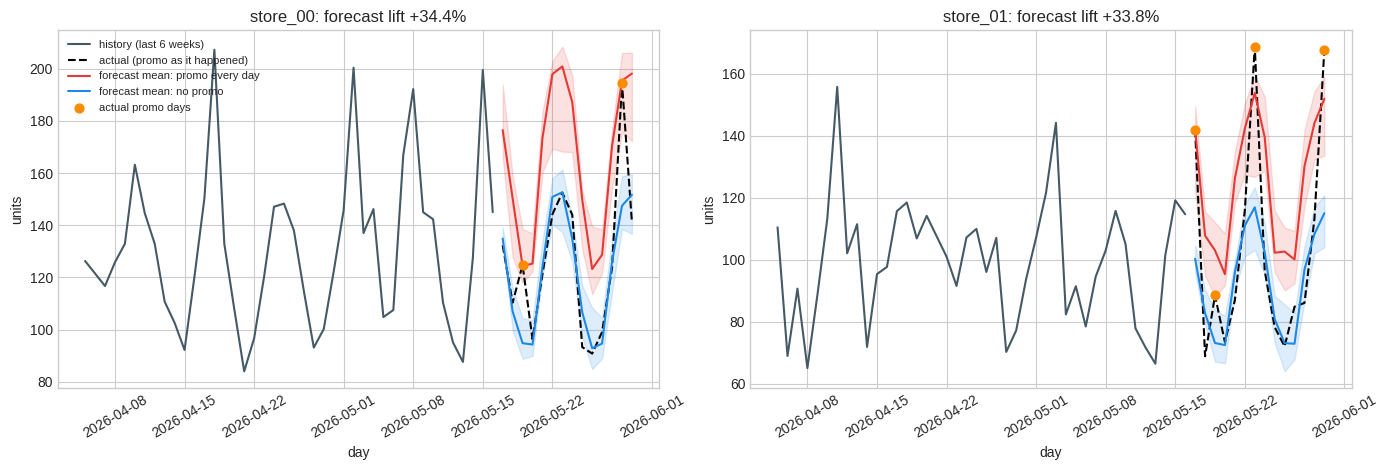

shaded bands are the 10-90% quantile fans; the gap between the red and blue means is what the model thinks a promotion is worth


In [82]:
# ============================================================
#  Picture 2: the promo effect. Two stores, history, and the promo-on vs promo-off forecast fans with the actuals
# ============================================================
if TS_STATUS == "ran":
    stores = list(ts11.item_ids[:2])
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=False)
    for ax, sid in zip(axes, stores):
        hist = ts_train11.loc[sid]["target"].iloc[-42:]
        act = ts_test11.loc[sid].iloc[-14:]
        on, off = fc_on.loc[sid], fc_off.loc[sid]
        ax.plot(hist.index, hist.values, color="#455a64", label="history (last 6 weeks)")
        ax.plot(act.index, act["target"].values, "k--", label="actual (promo as it happened)")
        for fc, color, name in [(on, "#e53935", "promo every day"), (off, "#1e88e5", "no promo")]:
            ax.plot(fc.index, fc["mean"], color=color, label=f"forecast mean: {name}")
            ax.fill_between(fc.index, fc["0.1"], fc["0.9"], color=color, alpha=0.15)
        promo_days = act.index[act["promo"] == 1]
        ax.scatter(promo_days, act.loc[promo_days, "target"], color="#fb8c00", zorder=5, s=40, label="actual promo days")
        ax.set_title(f"{sid}: forecast lift {lift11[sid]:+.1%}"); ax.set_xlabel("day"); ax.set_ylabel("units")
        ax.tick_params(axis="x", rotation=30)
    axes[0].legend(loc="upper left", fontsize=8)
    plt.tight_layout(); plt.show()
    print(f"shaded bands are the 10-90% quantile fans; the gap between the red and blue means is what the model thinks a promotion is worth")
else:
    print("time-series cell fell back; online this cell draws the promo-on vs promo-off forecast fans for two stores")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Grey is the last six weeks of history with its weekly wave. From the vertical gap onwards, two forecasts for the same store: red assumes a promotion every day of the horizon, blue assumes none, and each carries its 10-90% fan. The dashed black line is what happened, with the actual promotion days marked in orange, which sit near the red band while the other days sit near the blue one. The percentage in each title is the model's estimate of the promotion lift, to be read against the generator's planted +35%. The common misread: taking the lift as the value of running a promotion every day. The model learned the effect from days where promotions were occasional; a permanent promotion is outside the data it saw, and a forecast is not an experiment.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: known covariates are the "what if" handle on a forecaster

Anything you decide in advance (promotions, prices, opening hours, holidays) belongs in `known_covariates_names`. The forecaster then accepts a future table for those columns, and you can ask it about scenarios by editing that table. Anything you do not know in advance (weather, competitor moves) is a past covariate at best; it can inform the history but cannot be varied for the horizon.

</div>

## 12.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

**Interpretability:** run `feature_importance` on every tabular predictor before you believe it; reach for SHAP when a stakeholder needs a *single* prediction explained. It costs a permutation pass over the test set (seconds) or a few thousand model calls per explained row (a minute for 60 rows here). The gotcha: both explain the model, not the world.

**Deployment:** `save` / `load` / `clone_for_deployment` cover most of what "deploy AutoGluon" means; the rest is measuring latency at the batch size production will use. The gotcha: the clone loses `fit_extra` and the full leaderboard; keep the original directory too.

**Known covariates:** use them whenever a future driver is known; they turn a forecaster into a scenario tool. The gotcha: scenarios outside the range of the history are extrapolation.

</div>

### The capability map

| Business problem | Module | Input shape | Output | Metric to read | Fit time here | GPU? | Part |
|---|---|---|---|---|---|---|---|
| Will this customer leave? (yes/no) | `TabularPredictor(label, eval_metric="roc_auc")` | one row per entity, a 0/1 label | `predict_proba` per row, leaderboard | ROC-AUC, PR-AUC, log loss | ~1 min | no | 1 |
| Which of five grades? | `TabularPredictor(label)` → `multiclass` | one row per entity, K-valued label | K probability columns | accuracy, log loss, per-class F1 | ~1 min | no | 2 |
| What price / how much? | `TabularPredictor(label, eval_metric="mean_absolute_error")` | one row per entity, numeric label | a number per row | MAE, RMSE, R² | ~1 min | no | 3 |
| Between what and what? (a window) | `TabularPredictor(label, problem_type="quantile", quantile_levels=[...])` | as regression | one column per quantile | pinball loss, coverage, width | ~1 min | no | 4 |
| Find the 1% (fraud, faults) | `TabularPredictor(label, eval_metric="average_precision")` + a threshold | one row per event, rare 0/1 label | scores, a cost-optimal threshold | PR-AUC, cost curve | ~1 min | no | 5 |
| How many next week, per store? | `TimeSeriesPredictor(prediction_length, freq, known_covariates_names)` | long table `item_id, timestamp, target [, covariates]` | mean + quantile forecast per item | WQL, MASE, sMAPE | 1-2 min | Chronos-2 faster | 6 |
| Text next to numbers | `TabularPredictor` (n-grams) or `MultiModalPredictor(label)` (transformer) | a DataFrame with a text column | probabilities per row | as classification | 1-2 min | yes for the transformer | 7 |
| Label these photos | `MultiModalPredictor(label)` | a DataFrame with an image-path column | probabilities per image | accuracy, confusion matrix | 2 min | yes | 8 |
| Search, dedupe, cluster by meaning | `MultiModalPredictor(problem_type="feature_extraction").extract_embedding` | a DataFrame with a text column | one vector per row | ARI / NMI vs labels, top-k relevance | 1 min | helps | 9 |
| Small table, no time to tune | `hyperparameters={"MITRA": {}}` / `"TABICL"` / `presets="extreme_quality"` | as classification / regression, < 10k rows | as classification / regression | as the task | seconds to fit, slow to predict on CPU | strongly | 10 |
| Explain, ship, scenario | `feature_importance`, SHAP, `clone_for_deployment`, `known_covariates` | any fitted predictor | importances, SHAP values, a clone, scenario forecasts | latency, importance | seconds | no | 11 |

### The decision flowchart

```text
Start: a business question and some data
│
├─ Is the data one row per entity with named columns?
│    ├─ No: images / free text / documents ──▶ MultiModalPredictor (Parts 7-9)
│    │        need a searchable vector instead of a label? ──▶ feature_extraction + extract_embedding (Part 9)
│    ├─ It is a time-ordered table per item ──▶ TimeSeriesPredictor (Part 6)
│    │        known future drivers (promo, price)? ──▶ known_covariates_names (Part 11)
│    └─ Yes ──▶ TabularPredictor
│         ├─ label is 0/1 ──▶ eval_metric="roc_auc"; rare positives ──▶ "average_precision" + a cost threshold (Parts 1, 5)
│         ├─ label has K classes ──▶ multiclass, read per-class F1 (Part 2)
│         ├─ label is a number ──▶ regression, MAE or RMSE (Part 3); need a window ──▶ problem_type="quantile" (Part 4)
│         ├─ under ~10k rows and a GPU ──▶ presets="extreme_quality" or one foundation model (Part 10)
│         └─ millisecond scoring per row ──▶ stay with the tree zoo; clone_for_deployment + persist (Part 11)
│
└─ Always: show_input first, time_limit on every fit, report_card on held-out data, feature_importance before you believe it
```

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔬 SOTA 2026: what changed in the last eighteen months

- **AutoGluon 1.4.0 (29 July 2025)** was the first release to ship tabular foundation models as ordinary model keys (Mitra, TabPFN v2, TabICL, plus the pre-tuned TabM and RealMLP). **1.5.0 (19 December 2025)** added RealTabPFN-2.5, TabDPT and the TabPrep LightGBM, reporting a 70% win rate over 1.4's top preset on the 51 TabArena datasets. **1.6.0 (5 August 2026)** added Nori, TabPFN-3, TabDPT-Turbo, TabPFN-2.6 and TabICLv2, introduced the `extreme_quality` preset (every model commercial-friendly; 67% win rate over the 1.5 top preset with 27x faster training and 4x faster inference) and the `noncommercial` preset (`extreme_quality` plus TabPFN-3, Elo 1821 on TabArena-Lite against 1745 for `extreme_quality`). The installed **1.6.3 (18 September 2026)** is a bug-fix release on top of it.
- **TabArena** (Erickson, Purucker, Tschalzev and others, arXiv 20 June 2025; `tabarena.ai`) is the living benchmark those Elo numbers come from: 51 curated real tasks, repeated cross-validation, training and inference time reported next to accuracy. As of 2026 its best single model is a foundation model (RealTabPFN-2.5, and TabICLv2 by its own February 2026 paper), while its authors still call gradient-boosted trees strong contenders on large and category-heavy tables.
- **TabPFN-2.5** (Prior Labs, arXiv 2511.08667, November 2025) extended the original Nature paper's 10,000-row limit to 50,000 rows and 2,000 features; **TabICLv2** (Inria, arXiv 2602.11139, February 2026, ICML 2026) scales in-context learning to million-row tables with an open licence; **Mitra** (AWS, NeurIPS 2025) is the AutoGluon team's own model, pretrained on mixed synthetic priors and built to be fine-tuned.
- **Chronos-2** (Amazon, arXiv 2510.15821, released 20 October 2025) replaced the univariate Chronos-Bolt family as the default forecasting foundation model in AutoGluon 1.5: one encoder-only model that handles univariate, multivariate and covariate-informed forecasting zero-shot, so the promo scenario in this Part works without any training on a GPU runtime. Chronos-Bolt remains the small, CPU-friendly zero-shot option Part 6 used.
- **AutoGluon Assistant / MLZero** (NeurIPS 2025, arXiv 2505.13941) is the layer above `fit`: an LLM multi-agent system that takes a folder of raw files and a sentence, picks the AutoGluon module, writes and debugs the code. The capability map above is what it decides for you; the checks in the last line of the flowchart are what it still has to pass.

</div>

### 12.7 Task 12 Summary

**✅ Key Takeaways**
- `feature_importance` explains a predictor at the column level in seconds; a SHAP `KernelExplainer` around `predict_proba` explains single rows in about a minute per sixty of them.
- A `known_covariates` table for the horizon turns a forecaster into a scenario tool; editing `promo` recovered a lift close to the planted one.
- Deployment is five lines: `save`, `load`, `clone_for_deployment(model="best")`, `load` the clone, `predict_proba` on a fresh row; measure latency at the batch size production will use.
- The capability map and flowchart route any new business question to one AutoGluon module and one metric.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `fi11` | permutation importance of the Part 10 zoo predictor |
| `explainer11`, `shap11`, `explain11`, `background11`, `SHAP_STATUS` | the SHAP explainer, its values for 60 customers, the rows explained, and whether it ran |
| `demand11`, `ts11`, `ts_train11`, `ts_test11`, `tsp11` | the small demand table, its `TimeSeriesDataFrame` split, and the fitted forecaster |
| `fc_on`, `fc_off`, `fc_actual_promo`, `lift11`, `TS_STATUS` | the scenario forecasts, the per-store promo lift, and whether the fit ran |
| `loaded11`, `deploy_dir11`, `deployed11`, `new_customer`, `latency11`, `info11` | the reloaded predictor, its deployment clone, one fresh row, and the latency table |

**➡️ Next Up:** the closing section — a cheat sheet of every capability in one line each, the pitfalls the tour met, and where to go next.


---

# 🏆 Cheat Sheet: every capability in one line

| Capability | One line (AutoGluon 1.6) | Part |
|---|---|---|
| Binary classification | `TabularPredictor(label="churned", eval_metric="roc_auc").fit(train, time_limit=60, presets="medium_quality", num_cpus=N_CPUS)` | 1 |
| Multiclass | `TabularPredictor(label="grade").fit(train, ...)` → `predict_proba(test)` has one column per class | 2 |
| Regression | `TabularPredictor(label="price", eval_metric="mean_absolute_error").fit(train, ...)`; try `np.log1p` on skewed targets | 3 |
| Quantile regression | `TabularPredictor(label, problem_type="quantile", quantile_levels=[0.1, 0.5, 0.9]).fit(train, ...)` | 4 |
| Rare events | `eval_metric="average_precision"` → `calibrate_decision_threshold(val, metric=...)` → `set_decision_threshold(t)` | 5 |
| Time series | `TimeSeriesDataFrame.from_data_frame(df, id_column, timestamp_column)` → `TimeSeriesPredictor(prediction_length=14, freq="D", eval_metric="WQL", known_covariates_names=["promo"], quantile_levels=[...]).fit(train, presets="fast_training", time_limit=90)` | 6 |
| Zero-shot forecasting | `hyperparameters={"Chronos": {"model_path": "bolt_tiny"}}`, or `presets="chronos2"` on a GPU runtime | 6 |
| Text + tabular | `TabularPredictor` uses text columns automatically (n-grams); `MultiModalPredictor(label).fit(train, time_limit=120, hyperparameters={"model.hf_text.checkpoint_name": ...})` for a transformer | 7 |
| Images | `MultiModalPredictor(label).fit(df_with_image_paths, hyperparameters={"model.timm_image.checkpoint_name": ...})` | 8 |
| Embeddings and search | `MultiModalPredictor(problem_type="feature_extraction").extract_embedding(df)` → cosine similarity, K-means | 9 |
| Foundation models | `hyperparameters={"MITRA": {"fine_tune": False}}` / `{"TABICL": {}}` (pip extra) / `presets="extreme_quality"` on a GPU; `raise_on_model_failure=True` | 10 |
| Explain | `predictor.feature_importance(test)`; `shap.KernelExplainer(lambda X: predictor.predict_proba(df(X))[1], background)` | 11 |
| Scenario forecast | `predictor.predict(train, known_covariates=future_table_with_edited_promo)` | 11 |
| Deploy | `predictor.save()` → `TabularPredictor.load(path)` → `clone_for_deployment(dir, model="best")` → `load` → `predict_proba(one_row_df)` | 11 |

**The three lines never change.** `predictor = SomePredictor(label=...).fit(train, time_limit=...)` → `predictor.leaderboard(test)` → `predictor.predict(new)`. Everything in this notebook was a choice of predictor class, `problem_type`, `eval_metric`, and the shape of `train`.

---

# ⚠️ Common Pitfalls to Avoid

1. **Reading `score_val` as the result** (Part 1). It is AutoGluon's own holdout; report `leaderboard(test)` on rows the predictor never saw.
2. **Treating ordered grades as unordered classes without noticing the cost** (Part 2). Look at the confusion matrix for adjacent-grade errors before choosing accuracy as the metric.
3. **Optimising RMSE on a skewed price** (Part 3). One mansion sets the score; MAE or a log target says what a typical house costs.
4. **Quoting a delivery window without its coverage** (Part 4). An 80% window that covers 60% of deliveries is a broken promise; check coverage and width together.
5. **Accuracy on a 1.5% fraud rate** (Part 5). "Always legit" scores 98.5%; use PR-AUC and pick the threshold with a cost curve.
6. **Forecasting without the seasonal-naive baseline** (Part 6). A model that does not beat "same as last week" has learned nothing; the leaderboard shows both.
7. **Paying for a transformer on templated text** (Part 7). Compare the n-gram `TabularPredictor` first; the transformer earns its GPU only on long, varied text.
8. **Evaluating an image model on the images it trained on** (Part 8). Split by image before `fit`; the grid of predicted-vs-true titles must come from held-out files.
9. **Typing a foundation-model key from a blog post** (Part 10). Print `ag_model_registry.keys`, check the extra and the licence, fit with `raise_on_model_failure=True`.
10. **Benchmarking latency one row at a time, or shipping the whole zoo** (Part 11). Time `predict_proba` at production's batch size on the `clone_for_deployment` directory.

---

# 🚀 What's Next

1. **Go deep on one capability.** `colabs/06_data_eval_mlops/autogluon_zero_to_hero.ipynb` follows one dataset through the whole lifecycle: presets, bagging and stacking, hyperparameter tuning, threshold calibration, drift monitoring, `refit_full` / `distill` / `infer_limit`, error analysis by segment.
2. **Compare the toolboxes.** `colabs/06_data_eval_mlops/pycaret_zero_to_hero.ipynb` does the same lifecycle with PyCaret's `setup` / `compare_models` / `tune_model`; `colabs/06_data_eval_mlops/nvidia_rapids_zero_to_hero.ipynb` moves the tree zoo onto a GPU with cuDF and cuML for tables too large for this notebook.
3. **Re-run Parts 7 to 10 on a GPU runtime.** Switch Colab to a T4, let the multimodal fits use their transformer and CNN backbones, give the foundation model the full context, and watch the score-vs-latency scatter move.
4. **Replace one generator with your data.** Keep the generator's shape (a label column, or `item_id, timestamp, target`), keep `show_input` as the first call, and every other cell in that Part runs unchanged.
5. **Read the TabArena leaderboard once a quarter.** The ranking changes; the questions in the flowchart do not.


In [83]:
# ============================================================
#  Clean up: remove every predictor directory this tour created
# ============================================================
n_dirs = len([d for d in os.listdir(WORK) if os.path.isdir(os.path.join(WORK, d))]) if os.path.isdir(WORK) else 0
shutil.rmtree(WORK, ignore_errors=True)
print(f"removed {WORK} ({n_dirs} predictor directories) | still exists: {os.path.isdir(WORK)}")


removed /tmp (28 predictor directories) | still exists: False


<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 34px; border-radius: 20px; color: white; text-align: center; margin: 24px 0;">

## 🎓 Course Complete

Twelve capabilities, twelve small datasets, one three-line pattern.

You can now look at a business question and a table and say which AutoGluon module answers it, what the input has to look like, which metric to read, what the fit will cost, and what comes out: a probability, a class, a number, a window, a forecast fan, an embedding, an explanation, or a directory ready to ship.

The map is the product. Keep it next to the next dataset that lands on your desk.

</div>

---

# 📚 References

**AutoGluon**
- Erickson, N., Mueller, J., Shirkov, A., Zhang, H., Larroy, P., Li, M., Smola, A. *AutoGluon-Tabular: Robust and Accurate AutoML for Structured Data.* arXiv:2003.06505 (2020).
- AutoGluon documentation, `auto.gluon.ai`: tabular, foundational-models, time-series (including *Forecasting with Chronos-2*) and multimodal tutorials; *What's New* for 1.4.0 (29 July 2025), 1.5.0 (19 December 2025), 1.6.0 (5 August 2026) and 1.6.3 (18 September 2026, the version verified in this notebook).
- Shchur, O. et al. *AutoGluon-TimeSeries: AutoML for Probabilistic Time Series Forecasting.* AutoML Conference 2023.
- Ansari, A. F. et al. *Chronos: Learning the Language of Time Series.* TMLR 2024. Ansari, A. F. et al. *Chronos-2: From Univariate to Universal Forecasting.* arXiv:2510.15821 (October 2025).
- Fang, H. et al. *MLZero: A Multi-Agent System for End-to-end Machine Learning Automation.* NeurIPS 2025 (arXiv:2505.13941); AutoGluon Assistant, `github.com/autogluon/autogluon-assistant`.

**Tabular foundation models and benchmarks**
- Erickson, N., Purucker, L., Tschalzev, A. et al. *TabArena: A Living Benchmark for Machine Learning on Tabular Data.* arXiv:2506.16791 (June 2025); `tabarena.ai`.
- Hollmann, N., Müller, S., Purucker, L. et al. *Accurate predictions on small data with a tabular foundation model* (TabPFN v2). Nature, January 2025. Prior Labs. *TabPFN-2.5: Advancing the State of the Art in Tabular Foundation Models.* arXiv:2511.08667 (November 2025).
- Qu, J., Holzmüller, D., Varoquaux, G., Le Morvan, M. *TabICL: A Tabular Foundation Model for In-Context Learning on Large Data.* ICML 2025; *TabICLv2: A better, faster, scalable, and open tabular foundation model.* arXiv:2602.11139 (February 2026), ICML 2026.
- Zhang, X., Maddix, D. C., Yin, J., Erickson, N. et al. *Mitra: Mixed synthetic priors for enhancing tabular foundation models.* NeurIPS 2025.
- Gorishniy, Y. et al. *TabM: Advancing Tabular Deep Learning with Parameter-Efficient Ensembling.* ICLR 2025.
- Müller, S. et al. *Transformers Can Do Bayesian Inference* (the prior-data fitted network idea). ICLR 2022.

**Interpretability and metrics**
- Lundberg, S. M., Lee, S.-I. *A Unified Approach to Interpreting Model Predictions* (SHAP). NeurIPS 2017.
- Breiman, L. *Random Forests* (permutation importance). Machine Learning, 2001.
- Saito, T., Rehmsmeier, M. *The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets.* PLOS ONE 2015.
- Hyndman, R. J., Koehler, A. B. *Another look at measures of forecast accuracy* (MASE). International Journal of Forecasting, 2006.

---

<div style="text-align: center; color: #5F6368; font-size: 0.9em; padding: 12px;">
Built for the CMPE 258 zero-to-hero Colab series · verified against <b>AutoGluon 1.6.3</b> · every tabular cell runs on a free Colab CPU; multimodal and foundation-model cells fall back when a download or an extra is missing
</div>
